第一版，有第一轮和后面轮的差别

开始训练BCD算法，使用AUC早停...
Iter    1 | Loss: 0.668289 | Drop: 0.02485792 | Train Auc: 0.974562 | Val Auc: 0.934391
Iter    3 | Loss: 0.620773 | Drop: 0.02292077 | Train Auc: 0.977116 | Val Auc: 0.937850
Iter    5 | Loss: 0.580139 | Drop: 0.01950520 | Train Auc: 0.977810 | Val Auc: 0.939477
Iter    7 | Loss: 0.545395 | Drop: 0.01670771 | Train Auc: 0.978285 | Val Auc: 0.940494
Iter    9 | Loss: 0.515103 | Drop: 0.01461854 | Train Auc: 0.978804 | Val Auc: 0.943037
Iter   11 | Loss: 0.488814 | Drop: 0.01269188 | Train Auc: 0.979179 | Val Auc: 0.944360
Iter   13 | Loss: 0.465818 | Drop: 0.01113589 | Train Auc: 0.979679 | Val Auc: 0.945479
Iter   15 | Loss: 0.445525 | Drop: 0.00983668 | Train Auc: 0.980180 | Val Auc: 0.946394
Iter   17 | Loss: 0.427507 | Drop: 0.00874835 | Train Auc: 0.980523 | Val Auc: 0.947208
Iter   19 | Loss: 0.411407 | Drop: 0.00782991 | Train Auc: 0.980805 | Val Auc: 0.947310
Iter   21 | Loss: 0.396934 | Drop: 0.00704915 | Train Auc: 0.981142 | Val Auc: 0.947716
Iter   23 |

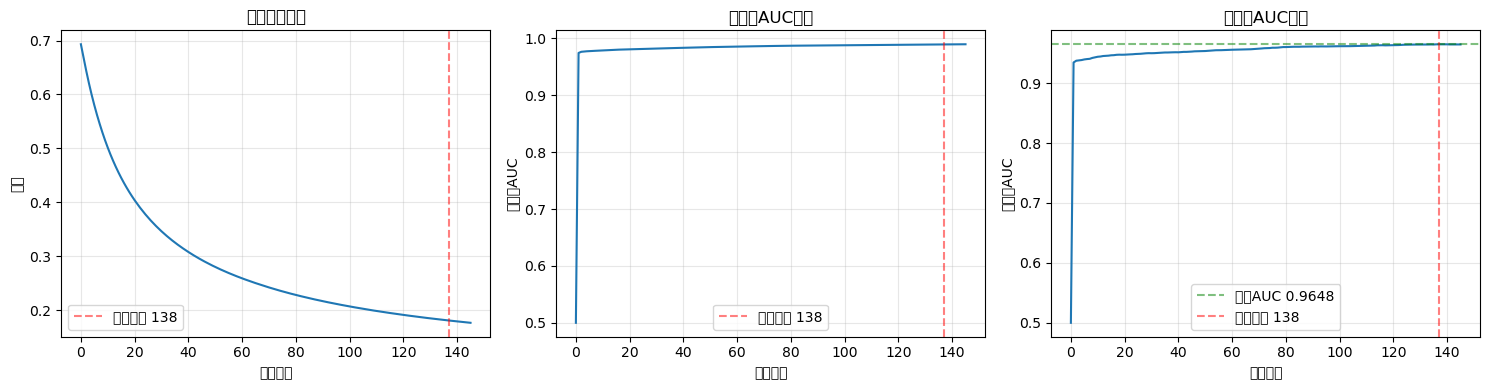


AUC早停分析:
----------------------------------------
最佳AUC出现在第 138 轮
最佳AUC值: 0.964805
最终AUC值: 0.964500
AUC提升: 0.464500
AUC稳定轮数: 5


In [ ]:
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer
from scipy.special import expit
from sklearn.metrics import accuracy_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')


def pre_binning(X, n_pre_bins=30, strategy='quantile', bin_edges_reference=None):
    """
    连续特征预分箱与全类独热编码
    """
    n_samples, n_features = X.shape
    bin_edges = []
    X_onehot_raw = []

    if bin_edges_reference is None:
        # 训练阶段：学习分箱切点
        discretizer = KBinsDiscretizer(
            n_bins=n_pre_bins, encode='onehot-dense',
            strategy=strategy, subsample=None, random_state=42
        )
        X_onehot_raw = discretizer.fit_transform(X)
        bin_edges = discretizer.bin_edges_
        per_feature_raw_cols = n_pre_bins
    else:
        # 预测/验证阶段：使用训练集的分箱切点做变换
        bin_edges = bin_edges_reference
        per_feature_raw_cols = len(bin_edges[0]) - 1
        for j in range(n_features):
            edges = bin_edges[j]
            X_digitized = np.digitize(X[:, j], edges[1:-1])
            onehot = np.zeros((n_samples, per_feature_raw_cols))
            onehot[np.arange(n_samples), X_digitized] = 1
            X_onehot_raw.append(onehot)
        X_onehot_raw = np.hstack(X_onehot_raw)

    # 丢弃参照箱（第一箱）
    feature_bin_dims = []
    X_onehot_filtered = []
    for j in range(n_features):
        start_idx = j * per_feature_raw_cols
        end_idx = (j + 1) * per_feature_raw_cols
        feature_onehot = X_onehot_raw[:, start_idx + 1:end_idx]
        X_onehot_filtered.append(feature_onehot)
        feature_bin_dims.append(feature_onehot.shape[1])

    X_onehot = np.hstack(X_onehot_filtered)
    return X_onehot, bin_edges, feature_bin_dims


class BCDOptimalBinning:
    """
    结合L0惩罚的最优分箱BCD算法
    添加AUC早停条件：当验证集AUC不再上升时停止迭代
    """
    
    def __init__(self, lambda_f=0.01, lambda_b=0.005, max_iter=1000,
                 tol=1e-6, verbose=False, metric='accuracy',
                 early_stopping_rounds=10, min_iter=5, patience=10):
        """
        参数说明：
        - early_stopping_rounds: AUC连续多少轮不提升则停止
        - min_iter: 最小迭代次数，避免过早停止
        - patience: 耐心轮数，超过此轮数AUC不提升则停止
        """
        self.lambda_f = lambda_f
        self.lambda_b = lambda_b
        self.max_iter = max_iter
        self.tol = tol
        self.verbose = verbose
        self.metric = metric
        self.early_stopping_rounds = early_stopping_rounds
        self.min_iter = min_iter
        self.patience = patience  # 最大容忍不提升的轮数
        
        # 模型参数
        self.beta = None
        self.feature_bin_dims = None
        self.n_features = None
        self.bin_edges = None
        self.n_pre_bins = None
        self.history = {
            'loss': [],
            'metric_train': [],
            'metric_val': []
        }
        self.converged = False
        self.best_iter = 0
        self.best_val_metric = 0.0
        self.best_beta = None
        self.best_state = None  # 保存最佳模型状态

    @staticmethod
    def _sigmoid(x):
        return expit(x)

    def _compute_total_loss(self, X, y, eta):
        """
        计算完整目标函数值
        """
        n_samples = len(y)
        sigma_eta = self._sigmoid(eta)
        log_likelihood = np.sum(
            y * np.log(sigma_eta + 1e-12) + (1 - y) * np.log(1 - sigma_eta + 1e-12)
        )
        L = -log_likelihood / n_samples

        penalty_f = 0.0
        penalty_b = 0.0
        for j in range(self.n_features):
            beta_j = self.beta[j]
            if self.feature_bin_dims[j] == 0:
                continue
            delta_j = np.diff(beta_j)
            n_change_points = np.sum(np.abs(delta_j) > 1e-12)
            penalty_b += self.lambda_b * n_change_points
            if n_change_points > 0:
                penalty_f += self.lambda_f

        return L + penalty_f + penalty_b

    def _compute_metric(self, X, y, eta=None):
        if eta is None:
            eta = self._compute_linear_predictor(X)
        y_proba = self._sigmoid(eta)
        if self.metric == 'accuracy':
            y_pred = (y_proba >= 0.5).astype(int)
            return accuracy_score(y, y_pred)
        elif self.metric == 'auc':
            return roc_auc_score(y, y_proba)
        else:
            raise ValueError("不支持的评估指标，请选择 'accuracy' 或 'auc'")

    def _compute_linear_predictor(self, X):
        beta_flat = np.concatenate(self.beta)
        if X.shape[1] != beta_flat.shape[0]:
            raise ValueError(
                f"特征维度不匹配！X列数：{X.shape[1]}，系数长度：{beta_flat.shape[0]}"
            )
        return X @ beta_flat

    def _compute_gradient_lipschitz(self, X, y, eta, j, i, feature_start_idx):
        n_samples = len(y)
        x_col = X[:, feature_start_idx + i]
        residual = self._sigmoid(eta) - y
        grad = np.sum(residual * x_col) / n_samples
        L_j_i = 0.25 * np.max(x_col ** 2)
        L_j_i = max(L_j_i, 1e-12)
        return grad, L_j_i

    @staticmethod
    def _compute_changepoint_indicator(beta_j):
        if len(beta_j) < 2:
            return 0
        delta_j = np.diff(beta_j)
        return 1 if np.sum(np.abs(delta_j) > 1e-12) > 0 else 0

    def fit(self, X, y, X_val=None, y_val=None, n_pre_bins=30, binning_strategy='quantile'):
        """
        模型拟合
        添加AUC早停机制
        """
        n_samples, self.n_features = X.shape
        self.n_pre_bins = n_pre_bins
        
        # 步骤1：预分箱与独热编码
        X_onehot, self.bin_edges, self.feature_bin_dims = pre_binning(
            X, n_pre_bins, binning_strategy
        )

        # 初始化系数
        self.beta = []
        feature_col_range = []
        current_idx = 0
        for j in range(self.n_features):
            Kj = self.feature_bin_dims[j]
            self.beta.append(np.zeros(Kj))
            feature_col_range.append((current_idx, current_idx + Kj))
            current_idx += Kj

        c_j = np.zeros(self.n_features, dtype=int)
        eta = self._compute_linear_predictor(X_onehot)

        # 记录初始状态
        initial_loss = self._compute_total_loss(X_onehot, y, eta)
        initial_metric_train = self._compute_metric(X_onehot, y, eta)
        self.history['loss'].append(initial_loss)
        self.history['metric_train'].append(initial_metric_train)

        has_val = (X_val is not None) and (y_val is not None)
        X_val_onehot = None
        if has_val:
            X_val_onehot, _, _ = pre_binning(X_val, n_pre_bins,
                                             bin_edges_reference=self.bin_edges)
            initial_metric_val = self._compute_metric(X_val_onehot, y_val)
            self.history['metric_val'].append(initial_metric_val)
            self.best_val_metric = initial_metric_val
            self.best_iter = 0
            self.best_beta = [beta.copy() for beta in self.beta]
        else:
            # 如果没有验证集，使用训练集AUC
            self.best_val_metric = initial_metric_train
            self.best_iter = 0
            self.best_beta = [beta.copy() for beta in self.beta]

        prev_loss = initial_loss
        no_improve_count = 0
        self.best_state = {
            'beta': [beta.copy() for beta in self.beta],
            'loss': initial_loss,
            'val_metric': self.best_val_metric
        }

        # 步骤2：BCD主迭代
        for iter_num in range(self.max_iter):
            c_j_snapshot = c_j.copy()

            for j in range(self.n_features):
                beta_j = self.beta[j].copy()
                Kj = self.feature_bin_dims[j]
                if Kj == 0:
                    continue
                start_idx, _ = feature_col_range[j]
                c_prev = c_j_snapshot[j]

                for i in range(Kj):
                    grad, L_j_i = self._compute_gradient_lipschitz(
                        X_onehot, y, eta, j, i, start_idx
                    )
                    r_j_i = beta_j[i] - grad / L_j_i
                    beta_star = r_j_i

                    def F(beta_val, _r=r_j_i, _L=L_j_i):
                        return 0.5 * _L * (_r - beta_val) ** 2

                    if i == 0:
                        new_beta = beta_star
                    else:
                        if c_prev == 1:
                            cost_new = F(beta_star) + self.lambda_b
                            cost_merge = F(beta_j[i - 1]) + self.lambda_f
                        else:
                            cost_new = F(beta_star) + self.lambda_f + self.lambda_b
                            cost_merge = F(beta_j[i - 1])
                        new_beta = beta_star if cost_new < cost_merge else beta_j[i - 1]

                    old_beta = beta_j[i]
                    if np.abs(new_beta - old_beta) > 1e-12:
                        beta_j[i] = new_beta
                        x_col = X_onehot[:, start_idx + i]
                        eta += (new_beta - old_beta) * x_col

                self.beta[j] = beta_j
                c_j[j] = self._compute_changepoint_indicator(beta_j)

            # 记录本轮迭代结果
            current_loss = self._compute_total_loss(X_onehot, y, eta)
            current_metric_train = self._compute_metric(X_onehot, y, eta)
            self.history['loss'].append(current_loss)
            self.history['metric_train'].append(current_metric_train)

            metric_val_str = ""
            if has_val:
                current_metric_val = self._compute_metric(X_val_onehot, y_val)
                self.history['metric_val'].append(current_metric_val)
                metric_val_str = f" | Val {self.metric.capitalize()}: {current_metric_val:.6f}"
                
                # 检查是否为最佳AUC
                if current_metric_val > self.best_val_metric + 1e-8:  # 小阈值避免浮点误差
                    self.best_val_metric = current_metric_val
                    self.best_iter = iter_num + 1
                    self.best_beta = [beta.copy() for beta in self.beta]
                    no_improve_count = 0
                else:
                    no_improve_count += 1
            else:
                # 如果没有验证集，使用训练集AUC
                if current_metric_train > self.best_val_metric + 1e-8:
                    self.best_val_metric = current_metric_train
                    self.best_iter = iter_num + 1
                    self.best_beta = [beta.copy() for beta in self.beta]
                    no_improve_count = 0
                else:
                    no_improve_count += 1

            loss_drop = prev_loss - current_loss

            if self.verbose and (iter_num % 15 == 0 or iter_num == self.max_iter - 1):
                print(
                    f"Iter {iter_num + 1:4d} | Loss: {current_loss:.6f} | "
                    f"Drop: {loss_drop:.8f} | "
                    f"Train {self.metric.capitalize()}: {current_metric_train:.6f}"
                    f"{metric_val_str}"
                )

            # AUC早停条件检查
            if iter_num + 1 >= self.min_iter:
                if has_val:
                    current_monitor_metric = self.history['metric_val'][-1]
                else:
                    current_monitor_metric = self.history['metric_train'][-1]
                    
                if iter_num + 1 >= self.min_iter:
                    # 检查是否连续early_stopping_rounds轮AUC没有提升
                    if no_improve_count >= self.early_stopping_rounds:
                        if self.verbose:
                            print(f"\nAUC早停！连续{self.early_stopping_rounds}轮AUC没有提升。")
                            print(f"最佳AUC: {self.best_val_metric:.6f} (第{self.best_iter}轮)")
                        # 恢复最佳模型参数
                        self.beta = [beta.copy() for beta in self.best_beta]
                        self.converged = True
                        break
                    
                    # 检查耐心轮数
                    if iter_num + 1 - self.best_iter > self.patience:
                        if self.verbose:
                            print(f"\n耐心耗尽！超过{self.patience}轮未达到最佳AUC。")
                            print(f"最佳AUC: {self.best_val_metric:.6f} (第{self.best_iter}轮)")
                        # 恢复最佳模型参数
                        self.beta = [beta.copy() for beta in self.best_beta]
                        self.converged = True
                        break

            # 损失收敛条件
            if 0 <= loss_drop < self.tol:
                if self.verbose:
                    print(f"\n损失收敛！迭代轮数：{iter_num + 1}")
                self.converged = True
                # 恢复最佳模型参数
                self.beta = [beta.copy() for beta in self.best_beta]
                break

            prev_loss = current_loss

        if not self.converged and self.verbose:
            print(f"\n达到最大迭代次数 {self.max_iter}")
            # 恢复最佳模型参数
            self.beta = [beta.copy() for beta in self.best_beta]
            
        if self.verbose:
            print(f"最终使用第{self.best_iter}轮的模型参数 (最佳{self.metric.upper()}: {self.best_val_metric:.6f})")
            
        return self

    def get_optimal_binning_structure(self):
        """提取每个特征的最优分箱结果"""
        binning_result = {}
        for j in range(self.n_features):
            beta_j = self.beta[j]
            bin_edges_j = self.bin_edges[j]

            delta_j = np.diff(beta_j)
            change_points = np.where(np.abs(delta_j) > 1e-12)[0] + 1
            pre_cut_points = bin_edges_j[1:-1]
            final_cut_points = pre_cut_points[change_points - 1]

            final_bins = np.concatenate(
                [[bin_edges_j[0]], final_cut_points, [bin_edges_j[-1]]]
            )

            # 累加重建系数
            final_coefs = [beta_j[0]] if len(beta_j) > 0 else [0.0]
            current_coef = beta_j[0] if len(beta_j) > 0 else 0.0
            for m in range(1, len(beta_j)):
                if np.abs(delta_j[m - 1]) > 1e-12:
                    current_coef = beta_j[m]
                final_coefs.append(current_coef)

            is_selected = len(change_points) > 0

            binning_result[f"feature_{j + 1}"] = {
                "is_selected": is_selected,
                "final_bins_count": len(final_bins) - 1,
                "final_bin_intervals": final_bins,
                "final_bin_coefficients": final_coefs,
                "original_beta_vector": beta_j,
                "change_points_indices": change_points,
            }
        return binning_result

    def predict_proba(self, X):
        X_onehot, _, _ = pre_binning(
            X, n_pre_bins=self.n_pre_bins, bin_edges_reference=self.bin_edges
        )
        eta = self._compute_linear_predictor(X_onehot)
        return self._sigmoid(eta)

    def predict(self, X, threshold=0.5):
        y_proba = self.predict_proba(X)
        return (y_proba >= threshold).astype(int)


# 测试代码
if __name__ == "__main__":
    np.random.seed(42)
    n_samples = 1000
    n_features = 5
    X = np.random.randn(n_samples, n_features)

    true_effect = np.zeros(n_samples)
    true_effect += np.where(X[:, 0] < -1, 0.8, np.where(X[:, 0] > 1, -0.8, 0))
    true_effect += np.where(X[:, 1] < 0, 0.6, -0.6)
    y = (expit(true_effect + np.random.randn(n_samples) * 0.1) >= 0.5).astype(int)

    split_idx = int(0.8 * n_samples)
    X_train, X_val = X[:split_idx], X[split_idx:]
    y_train, y_val = y[:split_idx], y[split_idx:]

    print("开始训练BCD算法，使用AUC早停...")
    print("=" * 60)
    
    # 创建带早停的BCD模型
    model = BCDOptimalBinning(
        lambda_f=2e-6, 
        lambda_b=2e-5,
        max_iter=500, 
        tol=1e-6, 
        verbose=True,
        metric='auc',
        early_stopping_rounds=7,  # AUC连续7轮不提升则停止
        min_iter=10,  # 至少迭代10轮
        patience=20   # 最多容忍20轮不提升
    )
    
    # 训练模型
    model.fit(X_train, y_train, X_val, y_val, n_pre_bins=30)
    
    print("\n" + "=" * 60)
    print("训练结果摘要")
    print("=" * 60)
    
    print(f"迭代总轮数: {len(model.history['loss'])}")
    print(f"最佳验证集AUC: {model.best_val_metric:.6f} (第{model.best_iter}轮)")
    
    if len(model.history['metric_val']) > 0:
        print(f"初始验证集AUC: {model.history['metric_val'][0]:.6f}")
        print(f"最终验证集AUC: {model.history['metric_val'][-1]:.6f}")
    
    print(f"收敛状态: {'是' if model.converged else '否'}")
    
    # 获取分箱结果
    binning_result = model.get_optimal_binning_structure()
    
    print("\n特征分箱结果:")
    print("-" * 50)
    selected_count = 0
    for feat_name, feat_info in binning_result.items():
        if feat_info['is_selected']:
            selected_count += 1
        print(f"{feat_name} | 是否选中: {feat_info['is_selected']} | "
              f"最终分箱数: {feat_info['final_bins_count']}")
    
    print(f"\n总共选中 {selected_count} 个特征")
    
    # 可视化训练过程
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # 损失曲线
    axes[0].plot(model.history['loss'])
    axes[0].axvline(x=model.best_iter-1, color='r', linestyle='--', alpha=0.5, label=f'最佳轮次 {model.best_iter}')
    axes[0].set_xlabel('迭代轮数')
    axes[0].set_ylabel('损失')
    axes[0].set_title('损失收敛曲线')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 训练集AUC曲线
    axes[1].plot(model.history['metric_train'])
    axes[1].axvline(x=model.best_iter-1, color='r', linestyle='--', alpha=0.5, label=f'最佳轮次 {model.best_iter}')
    axes[1].set_xlabel('迭代轮数')
    axes[1].set_ylabel('训练集AUC')
    axes[1].set_title('训练集AUC变化')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # 验证集AUC曲线
    if len(model.history['metric_val']) > 0:
        axes[2].plot(model.history['metric_val'])
        axes[2].axhline(y=model.best_val_metric, color='g', linestyle='--', alpha=0.5, label=f'最佳AUC {model.best_val_metric:.4f}')
        axes[2].axvline(x=model.best_iter-1, color='r', linestyle='--', alpha=0.5, label=f'最佳轮次 {model.best_iter}')
        axes[2].set_xlabel('迭代轮数')
        axes[2].set_ylabel('验证集AUC')
        axes[2].set_title('验证集AUC变化')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # AUC变化分析
    if len(model.history['metric_val']) > 0:
        print("\nAUC早停分析:")
        print("-" * 40)
        print(f"最佳AUC出现在第 {model.best_iter} 轮")
        print(f"最佳AUC值: {model.best_val_metric:.6f}")
        print(f"最终AUC值: {model.history['metric_val'][-1]:.6f}")
        print(f"AUC提升: {model.history['metric_val'][-1] - model.history['metric_val'][0]:.6f}")
        
        # 计算AUC稳定轮数
        stable_count = 0
        for i in range(len(model.history['metric_val'])-1, 0, -1):
            if abs(model.history['metric_val'][i] - model.history['metric_val'][-1]) < 1e-6:
                stable_count += 1
            else:
                break
        print(f"AUC稳定轮数: {stable_count}")


大一点的数据集，第一版

In [ ]:
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer
from scipy.special import expit  # 数值稳定的Sigmoid函数
from sklearn.metrics import accuracy_score, roc_auc_score


def pre_binning(X, n_pre_bins=30, strategy='quantile', bin_edges_reference=None):
    """
    连续特征预分箱与全类独热编码
    参数：
        X: 特征矩阵，shape=(n_samples, n_features)
        n_pre_bins: 每个特征的预分箱数（箱子数量）
        strategy: 分箱策略
        bin_edges_reference: 预测/验证时使用训练集的分箱切点，保证一致性
    返回：
        X_onehot: 全类独热编码矩阵（丢弃参照箱）
        bin_edges: 分箱切点
        feature_bin_dims: 每个特征对应的独热编码维度（丢弃参照箱后）
    """
    n_samples, n_features = X.shape
    bin_edges = []
    X_onehot_raw = []

    if bin_edges_reference is None:
        # 训练阶段：学习分箱切点
        discretizer = KBinsDiscretizer(
            n_bins=n_pre_bins, encode='onehot-dense',
            strategy=strategy, subsample=None, random_state=42
        )
        X_onehot_raw = discretizer.fit_transform(X)
        bin_edges = discretizer.bin_edges_
        per_feature_raw_cols = n_pre_bins
    else:
        # 预测/验证阶段：使用训练集的分箱切点做变换
        bin_edges = bin_edges_reference
        per_feature_raw_cols = len(bin_edges[0]) - 1
        for j in range(n_features):
            edges = bin_edges[j]
            X_digitized = np.digitize(X[:, j], edges[1:-1])
            onehot = np.zeros((n_samples, per_feature_raw_cols))
            onehot[np.arange(n_samples), X_digitized] = 1
            X_onehot_raw.append(onehot)
        X_onehot_raw = np.hstack(X_onehot_raw)

    # 丢弃参照箱（第一箱），与论文公式(4)定义完全一致
    feature_bin_dims = []
    X_onehot_filtered = []
    for j in range(n_features):
        start_idx = j * per_feature_raw_cols
        end_idx = (j + 1) * per_feature_raw_cols
        feature_onehot = X_onehot_raw[:, start_idx + 1:end_idx]
        X_onehot_filtered.append(feature_onehot)
        feature_bin_dims.append(feature_onehot.shape[1])

    X_onehot = np.hstack(X_onehot_filtered)
    return X_onehot, bin_edges, feature_bin_dims




class BCDOptimalBinning:
    """
    结合L0惩罚的最优分箱BCD算法
    严格对照论文实现，含跨轮次 c_j 指示量修正（论文第VII节）
    添加AUC早停机制：当验证集AUC连续不提升时提前停止训练
    """
    def __init__(self, lambda_f=0.01, lambda_b=0.005, max_iter=1000,
                 tol=1e-6, verbose=False, metric='accuracy',
                 early_stopping_rounds=10, min_iter=5, patience=20):
        self.lambda_f = lambda_f
        self.lambda_b = lambda_b
        self.max_iter = max_iter
        self.tol = tol
        self.verbose = verbose
        self.metric = metric
        self.early_stopping_rounds = early_stopping_rounds
        self.min_iter = min_iter
        self.patience = patience

        self.beta = None
        self.feature_bin_dims = None
        self.n_features = None
        self.bin_edges = None
        self.n_pre_bins = None
        self.history = {
            'loss': [],
            'metric_train': [],
            'metric_val': []
        }
        self.converged = False
        self.best_iter = 0
        self.best_val_metric = 0.0
        self.best_beta = None
        self.no_improve_count = 0

    @staticmethod
    def _sigmoid(x):
        return expit(x)

    def _compute_total_loss(self, X, y, eta):
        """
        计算完整目标函数值（公式9）：
        L(β) = L(β) + λf·Σ 1(‖δj‖₀ > 0) + λb·Σ ‖δj‖₀
        注意：论文将λf激活条件等价改写为"存在变点"，即1(‖δj‖₀ > 0)
        """
        n_samples = len(y)
        sigma_eta = self._sigmoid(eta)
        log_likelihood = np.sum(
            y * np.log(sigma_eta + 1e-12) + (1 - y) * np.log(1 - sigma_eta + 1e-12)
        )
        L = -log_likelihood / n_samples

        penalty_f = 0.0
        penalty_b = 0.0
        for j in range(self.n_features):
            beta_j = self.beta[j]
            if self.feature_bin_dims[j] == 0:
                continue
            delta_j = np.diff(beta_j)
            n_change_points = np.sum(np.abs(delta_j) > 1e-12)
            penalty_b += self.lambda_b * n_change_points
            if n_change_points > 0:
                penalty_f += self.lambda_f

        return L + penalty_f + penalty_b

    def _compute_metric(self, X, y, eta=None):
        if eta is None:
            eta = self._compute_linear_predictor(X)
        y_proba = self._sigmoid(eta)
        if self.metric == 'accuracy':
            y_pred = (y_proba >= 0.5).astype(int)
            return accuracy_score(y, y_pred)
        elif self.metric == 'auc':
            return roc_auc_score(y, y_proba)
        else:
            raise ValueError("不支持的评估指标，请选择 'accuracy' 或 'auc'")

    def _compute_linear_predictor(self, X):
        beta_flat = np.concatenate(self.beta)
        if X.shape[1] != beta_flat.shape[0]:
            raise ValueError(
                f"特征维度不匹配！X列数：{X.shape[1]}，系数长度：{beta_flat.shape[0]}"
            )
        return X @ beta_flat

    def _compute_gradient_lipschitz(self, X, y, eta, j, i, feature_start_idx):
        """
        计算梯度与局部Lipschitz常数
        L̂_{j,i} = (1/4)·‖x_col‖²/n  （逻辑回归标准二次上界，论文引理5.1）
        """
        n_samples = len(y)
        x_col = X[:, feature_start_idx + i]
        residual = self._sigmoid(eta) - y
        grad = np.sum(residual * x_col) / n_samples
        L_j_i = 0.25 * np.max(x_col ** 2)
        L_j_i = max(L_j_i, 1e-12)
        return grad, L_j_i

    @staticmethod
    def _compute_changepoint_indicator(beta_j):
        """计算特征j的变点指示量 c_j = 1(‖δj‖₀ > 0)"""
        if len(beta_j) < 2:
            return 0
        delta_j = np.diff(beta_j)
        return 1 if np.sum(np.abs(delta_j) > 1e-12) > 0 else 0

    def fit(self, X, y, X_val=None, y_val=None, n_pre_bins=30, binning_strategy='quantile'):
        """
        模型拟合
        核心修正（论文第VII节）：
          - 维护跨轮次的 c_j 指示量数组（上一轮结束后冻结）
          - 每轮开始时对 c_j 拍快照，在该轮内所有特征的更新中使用快照值
          - 每更新完一个特征后，更新该特征对应的 c_j 供下一轮使用
        添加AUC早停机制：
          - 当验证集AUC连续不提升时提前停止训练
        """
        n_samples, self.n_features = X.shape
        self.n_pre_bins = n_pre_bins

        # 步骤1：预分箱与独热编码
        X_onehot, self.bin_edges, self.feature_bin_dims = pre_binning(
            X, n_pre_bins, binning_strategy
        )

        # 初始化系数（全零）
        self.beta = []
        feature_col_range = []
        current_idx = 0
        for j in range(self.n_features):
            Kj = self.feature_bin_dims[j]
            self.beta.append(np.zeros(Kj))
            feature_col_range.append((current_idx, current_idx + Kj))
            current_idx += Kj

        # 初始化 c_j 指示量数组
        c_j = np.zeros(self.n_features, dtype=int)
        eta = self._compute_linear_predictor(X_onehot)

        # 记录初始状态
        initial_loss = self._compute_total_loss(X_onehot, y, eta)
        initial_metric_train = self._compute_metric(X_onehot, y, eta)
        self.history['loss'].append(initial_loss)
        self.history['metric_train'].append(initial_metric_train)

        has_val = (X_val is not None) and (y_val is not None)
        X_val_onehot = None
        if has_val:
            X_val_onehot, _, _ = pre_binning(X_val, n_pre_bins,
                                              bin_edges_reference=self.bin_edges)
            initial_metric_val = self._compute_metric(X_val_onehot, y_val)
            self.history['metric_val'].append(initial_metric_val)
            self.best_val_metric = initial_metric_val
            self.best_iter = 0
            self.best_beta = [beta.copy() for beta in self.beta]
        else:
            # 如果没有验证集，则基于训练集指标
            self.best_val_metric = initial_metric_train
            self.best_iter = 0
            self.best_beta = [beta.copy() for beta in self.beta]

        prev_loss = initial_loss
        self.no_improve_count = 0

        # 步骤2：BCD主迭代
        for iter_num in range(self.max_iter):
            c_j_snapshot = c_j.copy()

            for j in range(self.n_features):
                beta_j = self.beta[j].copy()
                Kj = self.feature_bin_dims[j]
                if Kj == 0:
                    continue
                start_idx, _ = feature_col_range[j]
                c_prev = c_j_snapshot[j]

                for i in range(Kj):
                    grad, L_j_i = self._compute_gradient_lipschitz(
                        X_onehot, y, eta, j, i, start_idx
                    )
                    r_j_i = beta_j[i] - grad / L_j_i
                    beta_star = r_j_i

                    def F(beta_val, _r=r_j_i, _L=L_j_i):
                        return 0.5 * _L * (_r - beta_val) ** 2

                    if i == 0:
                        new_beta = beta_star
                    else:
                        if c_prev == 1:
                            cost_new = F(beta_star) + self.lambda_b
                            cost_merge = F(beta_j[i - 1]) + self.lambda_f
                        else:
                            cost_new = F(beta_star) + self.lambda_f + self.lambda_b
                            cost_merge = F(beta_j[i - 1])
                        new_beta = beta_star if cost_new < cost_merge else beta_j[i - 1]

                    old_beta = beta_j[i]
                    if np.abs(new_beta - old_beta) > 1e-12:
                        beta_j[i] = new_beta
                        x_col = X_onehot[:, start_idx + i]
                        eta += (new_beta - old_beta) * x_col

                self.beta[j] = beta_j
                c_j[j] = self._compute_changepoint_indicator(beta_j)

            # 记录本轮迭代结果
            current_loss = self._compute_total_loss(X_onehot, y, eta)
            current_metric_train = self._compute_metric(X_onehot, y, eta)
            self.history['loss'].append(current_loss)
            self.history['metric_train'].append(current_metric_train)

            metric_val_str = ""
            if has_val:
                current_metric_val = self._compute_metric(X_val_onehot, y_val)
                self.history['metric_val'].append(current_metric_val)
                metric_val_str = f" | Val {self.metric.capitalize()}: {current_metric_val:.6f}"
                
                # 检查是否为最佳指标
                if current_metric_val > self.best_val_metric + 1e-8:
                    self.best_val_metric = current_metric_val
                    self.best_iter = iter_num + 1
                    self.best_beta = [beta.copy() for beta in self.beta]
                    self.no_improve_count = 0
                else:
                    self.no_improve_count += 1
            else:
                # 如果没有验证集，则基于训练集指标
                if current_metric_train > self.best_val_metric + 1e-8:
                    self.best_val_metric = current_metric_train
                    self.best_iter = iter_num + 1
                    self.best_beta = [beta.copy() for beta in self.beta]
                    self.no_improve_count = 0
                else:
                    self.no_improve_count += 1

            loss_drop = prev_loss - current_loss

            if self.verbose and (iter_num % 15 == 0 or iter_num == self.max_iter - 1):
                print(
                    f"Iter {iter_num + 1:4d} | Loss: {current_loss:.6f} | "
                    f"Drop: {loss_drop:.8f} | "
                    f"Train {self.metric.capitalize()}: {current_metric_train:.6f}"
                    f"{metric_val_str}"
                )

            # AUC早停条件检查
            if iter_num + 1 >= self.min_iter:
                if has_val:
                    current_monitor_metric = self.history['metric_val'][-1]
                else:
                    current_monitor_metric = self.history['metric_train'][-1]
                    
                if self.no_improve_count >= self.early_stopping_rounds:
                    if self.verbose:
                        print(f"\nAUC早停！连续{self.early_stopping_rounds}轮{self.metric.upper()}没有提升。")
                        print(f"最佳{self.metric.upper()}: {self.best_val_metric:.6f} (第{self.best_iter}轮)")
                    # 恢复最佳模型参数
                    self.beta = [beta.copy() for beta in self.best_beta]
                    self.converged = True
                    break
                
                # 检查耐心轮数
                if iter_num + 1 - self.best_iter > self.patience:
                    if self.verbose:
                        print(f"\n耐心耗尽！超过{self.patience}轮未达到最佳{self.metric.upper()}。")
                        print(f"最佳{self.metric.upper()}: {self.best_val_metric:.6f} (第{self.best_iter}轮)")
                    # 恢复最佳模型参数
                    self.beta = [beta.copy() for beta in self.best_beta]
                    self.converged = True
                    break

            # 损失收敛条件
            if 0 <= loss_drop < self.tol:
                if self.verbose:
                    print(f"\n损失收敛！迭代轮数：{iter_num + 1}")
                self.converged = True
                # 恢复最佳模型参数
                self.beta = [beta.copy() for beta in self.best_beta]
                break

            prev_loss = current_loss

        if not self.converged and self.verbose:
            print(f"\n达到最大迭代次数 {self.max_iter}")
            # 恢复最佳模型参数
            self.beta = [beta.copy() for beta in self.best_beta]
            
        if self.verbose:
            print(f"最终使用第{self.best_iter}轮的模型参数 (最佳{self.metric.upper()}: {self.best_val_metric:.6f})")
            
        return self

    def get_optimal_binning_structure(self):
        """提取每个特征的最优分箱结果"""
        binning_result = {}
        for j in range(self.n_features):
            beta_j = self.beta[j]
            bin_edges_j = self.bin_edges[j]

            delta_j = np.diff(beta_j)
            change_points = np.where(np.abs(delta_j) > 1e-12)[0] + 1
            pre_cut_points = bin_edges_j[1:-1]
            final_cut_points = pre_cut_points[change_points - 1]

            final_bins = np.concatenate(
                [[bin_edges_j[0]], final_cut_points, [bin_edges_j[-1]]]
            )

            # 累加重建系数
            final_coefs = [beta_j[0]] if len(beta_j) > 0 else [0.0]
            current_coef = beta_j[0] if len(beta_j) > 0 else 0.0
            for m in range(1, len(beta_j)):
                if np.abs(delta_j[m - 1]) > 1e-12:
                    current_coef = beta_j[m]
                final_coefs.append(current_coef)

            is_selected = len(change_points) > 0

            binning_result[f"feature_{j + 1}"] = {
                "is_selected": is_selected,
                "final_bins_count": len(final_bins) - 1,
                "final_bin_intervals": final_bins,
                "final_bin_coefficients": final_coefs,
                "original_beta_vector": beta_j,
                "change_points_indices": change_points,
            }
        return binning_result

    def predict_proba(self, X):
        X_onehot, _, _ = pre_binning(
            X, n_pre_bins=self.n_pre_bins, bin_edges_reference=self.bin_edges
        )
        eta = self._compute_linear_predictor(X_onehot)
        return self._sigmoid(eta)

    def predict(self, X, threshold=0.5):
        y_proba = self.predict_proba(X)
        return (y_proba >= threshold).astype(int)


# -----------------------------------------------------------------------------
# 修改的数据生成部分
# -----------------------------------------------------------------------------
if __name__ == "__main__":
    # 扩大数据规模
    np.random.seed(42)
    n_samples = 10000  # 增加样本数到10000
    n_features = 30    # 增加特征数到30（从20增加到30）
    
    # 生成特征数据
    X = np.random.randn(n_samples, n_features)
    
    # 生成真实标签：所有特征都有分箱效应
    true_effect = np.zeros(n_samples)
    
    # 特征1: 3个分箱结构
    true_effect += np.where(X[:, 0] < -1, 1.2, np.where(X[:, 0] > 1, -0.8, 0.3))
    
    # 特征2: 2个分箱结构
    true_effect += np.where(X[:, 1] < 0, 0.8, -0.6)
    
    # 特征3: 4个分箱结构
    true_effect += np.where(X[:, 2] < -1.5, -1.0, 
                           np.where(X[:, 2] < 0, -0.5,
                                   np.where(X[:, 2] < 1.5, 0.5, 1.0)))
    
    # 特征4: 线性效应（测试算法是否会将其分箱）
    true_effect += 0.5 * X[:, 3]
    
    # 特征5: 阈值效应
    true_effect += np.where(X[:, 4] > 0.8, 0.9, 0)
    
    # 特征6-10: 2个分箱结构（随机阈值和系数）
    for j in range(5, 10):
        # 随机生成阈值（-1到1之间）
        threshold = np.random.uniform(-1, 1)
        # 随机生成系数（-1到1之间）
        coef1 = np.random.uniform(-0.8, 0.8)
        coef2 = np.random.uniform(-0.8, 0.8)
        true_effect += np.where(X[:, j] < threshold, coef1, coef2)
    
    # 特征11-15: 3个分箱结构
    for j in range(10, 15):
        # 随机生成两个阈值
        threshold1 = np.random.uniform(-1.5, 0)
        threshold2 = np.random.uniform(0, 1.5)
        # 随机生成三个系数
        coef1 = np.random.uniform(-1.0, -0.3)
        coef2 = np.random.uniform(-0.2, 0.2)
        coef3 = np.random.uniform(0.3, 1.0)
        true_effect += np.where(X[:, j] < threshold1, coef1, 
                               np.where(X[:, j] < threshold2, coef2, coef3))
    
    # 特征16-20: 4个分箱结构
    for j in range(15, 20):
        # 随机生成三个阈值
        threshold1 = np.random.uniform(-2.0, -1.0)
        threshold2 = np.random.uniform(-0.5, 0.5)
        threshold3 = np.random.uniform(1.0, 2.0)
        # 随机生成四个系数
        coef1 = np.random.uniform(-1.5, -0.8)
        coef2 = np.random.uniform(-0.4, 0)
        coef3 = np.random.uniform(0, 0.4)
        coef4 = np.random.uniform(0.8, 1.5)
        true_effect += np.where(X[:, j] < threshold1, coef1,
                               np.where(X[:, j] < threshold2, coef2,
                                       np.where(X[:, j] < threshold3, coef3, coef4)))
    
    # 特征21-25: 复杂的非线性结构（多个分箱）
    for j in range(20, 25):
        # 随机生成多个阈值
        n_bins = np.random.choice([3, 4, 5])  # 随机选择3,4或5个分箱
        thresholds = sorted(np.random.uniform(-2, 2, n_bins-1))
        # 随机生成系数
        coefs = np.random.uniform(-1.0, 1.0, n_bins)
        
        # 构建嵌套的np.where语句
        expr = np.where(X[:, j] < thresholds[0], coefs[0], coefs[1])
        for k in range(1, len(thresholds)):
            expr = np.where(X[:, j] < thresholds[k], expr, coefs[k+1])
        true_effect += expr
    
    # 特征26-30: 混合效应（部分线性，部分阈值）
    for j in range(25, 30):
        effect_type = np.random.choice(['threshold', 'piecewise', 'linear'])
        
        if effect_type == 'threshold':
            # 阈值效应
            threshold = np.random.uniform(-0.5, 0.5)
            coef = np.random.uniform(0.5, 1.5)
            true_effect += np.where(X[:, j] > threshold, coef, 0)
        
        elif effect_type == 'piecewise':
            # 分段常数
            threshold = np.random.uniform(-0.5, 0.5)
            coef1 = np.random.uniform(-1.0, -0.2)
            coef2 = np.random.uniform(0.2, 1.0)
            true_effect += np.where(X[:, j] < threshold, coef1, coef2)
        
        else:  # 'linear'
            # 线性效应
            slope = np.random.uniform(-0.7, 0.7)
            true_effect += slope * X[:, j]
    
    # 添加噪声并生成二分类标签
    y_proba = expit(true_effect + np.random.randn(n_samples) * 0.2)
    y = (y_proba >= 0.5).astype(int)
    
    # 查看类别分布
    print(f"正样本比例: {y.mean():.3f}")
    print(f"特征维度: {X.shape}")
    
    # 训练/验证集划分
    split_idx = int(0.8 * n_samples)
    X_train, X_val = X[:split_idx], X[split_idx:]
    y_train, y_val = y[:split_idx], y[split_idx:]
    
    print(f"\n训练集大小: {X_train.shape}, 验证集大小: {X_val.shape}")
    print(f"特征效应总结:")
    print(f"- 特征1-5: 预定义的不同分箱结构")
    print(f"- 特征6-10: 2个分箱的随机结构")
    print(f"- 特征11-15: 3个分箱的随机结构")
    print(f"- 特征16-20: 4个分箱的随机结构")
    print(f"- 特征21-25: 复杂多分箱结构(3-5个分箱)")
    print(f"- 特征26-30: 混合效应(阈值/分段/线性)")
    
    # 2. 模型拟合（监控 AUC 指标）
    print("\n开始训练，监控指标为 AUC...")
    model = BCDOptimalBinning(
        lambda_f=2e-6, 
        lambda_b=2e-5,
        max_iter=500, 
        tol=1e-6, 
        verbose=True,
        metric='auc',
        early_stopping_rounds=7,  # AUC连续7轮不提升则停止
        min_iter=10,  # 至少迭代10轮
        patience=20   # 最多容忍20轮不提升
    )
    
    model.fit(X_train, y_train, X_val, y_val, n_pre_bins=15)  # 增加预分箱数
    
    # 3. 输出训练历史
    print("\n" + "="*50)
    print("训练历史摘要")
    print("="*50)
    print(f"初始 Loss: {model.history['loss'][0]:.6f}, 最终 Loss: {model.history['loss'][-1]:.6f}")
    print(f"初始 Train AUC: {model.history['metric_train'][0]:.4f}, 最终 Train AUC: {model.history['metric_train'][-1]:.4f}")
    if model.history['metric_val']:
        print(f"初始 Val AUC: {model.history['metric_val'][0]:.4f}, 最终 Val AUC: {model.history['metric_val'][-1]:.4f}")
    print(f"收敛状态: {'是' if model.converged else '否'}，迭代轮数: {len(model.history['loss'])-1}")
    
    # 4. 查看分箱结果
    binning_result = model.get_optimal_binning_structure()
    
    print("\n" + "="*50)
    print("特征分箱结果概览")
    print("="*50)
    selected_features = 0
    for feat_name, feat_info in binning_result.items():
        if feat_info['is_selected']:
            selected_features += 1
            print(f"{feat_name:<12} | 是否入模：{'是':<5} | 最终分箱数：{feat_info['final_bins_count']:<3} | "
                  f"变点位置：{feat_info['change_points_indices']}")
    
    print(f"\n总计 {n_features} 个特征，其中 {selected_features} 个被模型选中")
    
    # 查看前5个特征的详细结果
    print("\n" + "="*50)
    print("前5个特征的详细分箱结果")
    print("="*50)
    for j in range(min(5, n_features)):
        feat_name = f"feature_{j+1}"
        feat_info = binning_result[feat_name]
        if feat_info['is_selected']:
            print(f"\n{feat_name}:")
            print(f"  最终分箱区间: {feat_info['final_bin_intervals']}")
            print(f"  对应系数: {feat_info['final_bin_coefficients']}")
    
    # 模型预测
    print("\n" + "="*50)
    print("模型评估")
    print("="*50)
    
    # 在训练集和验证集上评估
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    
    y_train_proba = model.predict_proba(X_train)
    y_val_proba = model.predict_proba(X_val)
    
    train_auc = roc_auc_score(y_train, y_train_proba)
    val_auc = roc_auc_score(y_val, y_val_proba)
    
    print(f"训练集准确率: {train_acc:.4f}")
    print(f"验证集准确率: {val_acc:.4f}")
    print(f"训练集AUC: {train_auc:.4f}")
    print(f"验证集AUC: {val_auc:.4f}")

正样本比例: 0.838
特征维度: (10000, 30)

训练集大小: (8000, 30), 验证集大小: (2000, 30)
特征效应总结:
- 特征1-5: 预定义的不同分箱结构
- 特征6-10: 2个分箱的随机结构
- 特征11-15: 3个分箱的随机结构
- 特征16-20: 4个分箱的随机结构
- 特征21-25: 复杂多分箱结构(3-5个分箱)
- 特征26-30: 混合效应(阈值/分段/线性)

开始训练，监控指标为 AUC...
Iter    1 | Loss: 0.439508 | Drop: 0.25363967 | Train Auc: 0.849850 | Val Auc: 0.835155
Iter    3 | Loss: 0.404299 | Drop: 0.01169564 | Train Auc: 0.917436 | Val Auc: 0.901005
Iter    5 | Loss: 0.385480 | Drop: 0.00898566 | Train Auc: 0.927663 | Val Auc: 0.912874
Iter    7 | Loss: 0.369487 | Drop: 0.00768882 | Train Auc: 0.929162 | Val Auc: 0.915298
Iter    9 | Loss: 0.355801 | Drop: 0.00656022 | Train Auc: 0.929350 | Val Auc: 0.916035
Iter   11 | Loss: 0.344014 | Drop: 0.00567222 | Train Auc: 0.929449 | Val Auc: 0.916863
Iter   13 | Loss: 0.333761 | Drop: 0.00494851 | Train Auc: 0.929449 | Val Auc: 0.917370
Iter   15 | Loss: 0.324815 | Drop: 0.00432383 | Train Auc: 0.929481 | Val Auc: 0.917607
Iter   17 | Loss: 0.316930 | Drop: 0.00381587 | Train Auc: 0.9295

固定组分箱+lasso和调用bcd比较

训练集大小: (8000, 20), 验证集大小: (2000, 20)
正样本比例: 训练集=0.585, 验证集=0.581

两步法模型训练
第一步：聚类分箱...
分箱后特征维度: 280
第二步：Lasso变量选择...
Lasso模型选择特征数: 12/20
训练时间: 2.80秒

两步法模型结果:
训练集准确率: 0.6751
验证集准确率: 0.6695
训练集AUC: 0.7243
验证集AUC: 0.7283

两步法选中的特征: [1, 2, 3, 4, 5, 8, 11, 12, 13, 14, 15, 17]

您的BCD算法训练
Iter    1 | Loss: 0.671253 | Drop: 0.02189441 | Train Auc: 0.709123 | Val Auc: 0.692075
Iter    3 | Loss: 0.653812 | Drop: 0.00773166 | Train Auc: 0.729156 | Val Auc: 0.710217
Iter    5 | Loss: 0.641240 | Drop: 0.00587339 | Train Auc: 0.731443 | Val Auc: 0.712437
Iter    7 | Loss: 0.631520 | Drop: 0.00455383 | Train Auc: 0.732258 | Val Auc: 0.713453
Iter    9 | Loss: 0.623936 | Drop: 0.00356157 | Train Auc: 0.732777 | Val Auc: 0.714019
Iter   11 | Loss: 0.617966 | Drop: 0.00280976 | Train Auc: 0.733151 | Val Auc: 0.714442
Iter   13 | Loss: 0.613227 | Drop: 0.00223557 | Train Auc: 0.733457 | Val Auc: 0.714776
Iter   15 | Loss: 0.609433 | Drop: 0.00179329 | Train Auc: 0.733741 | Val Auc: 0.714974
Iter   17 | L

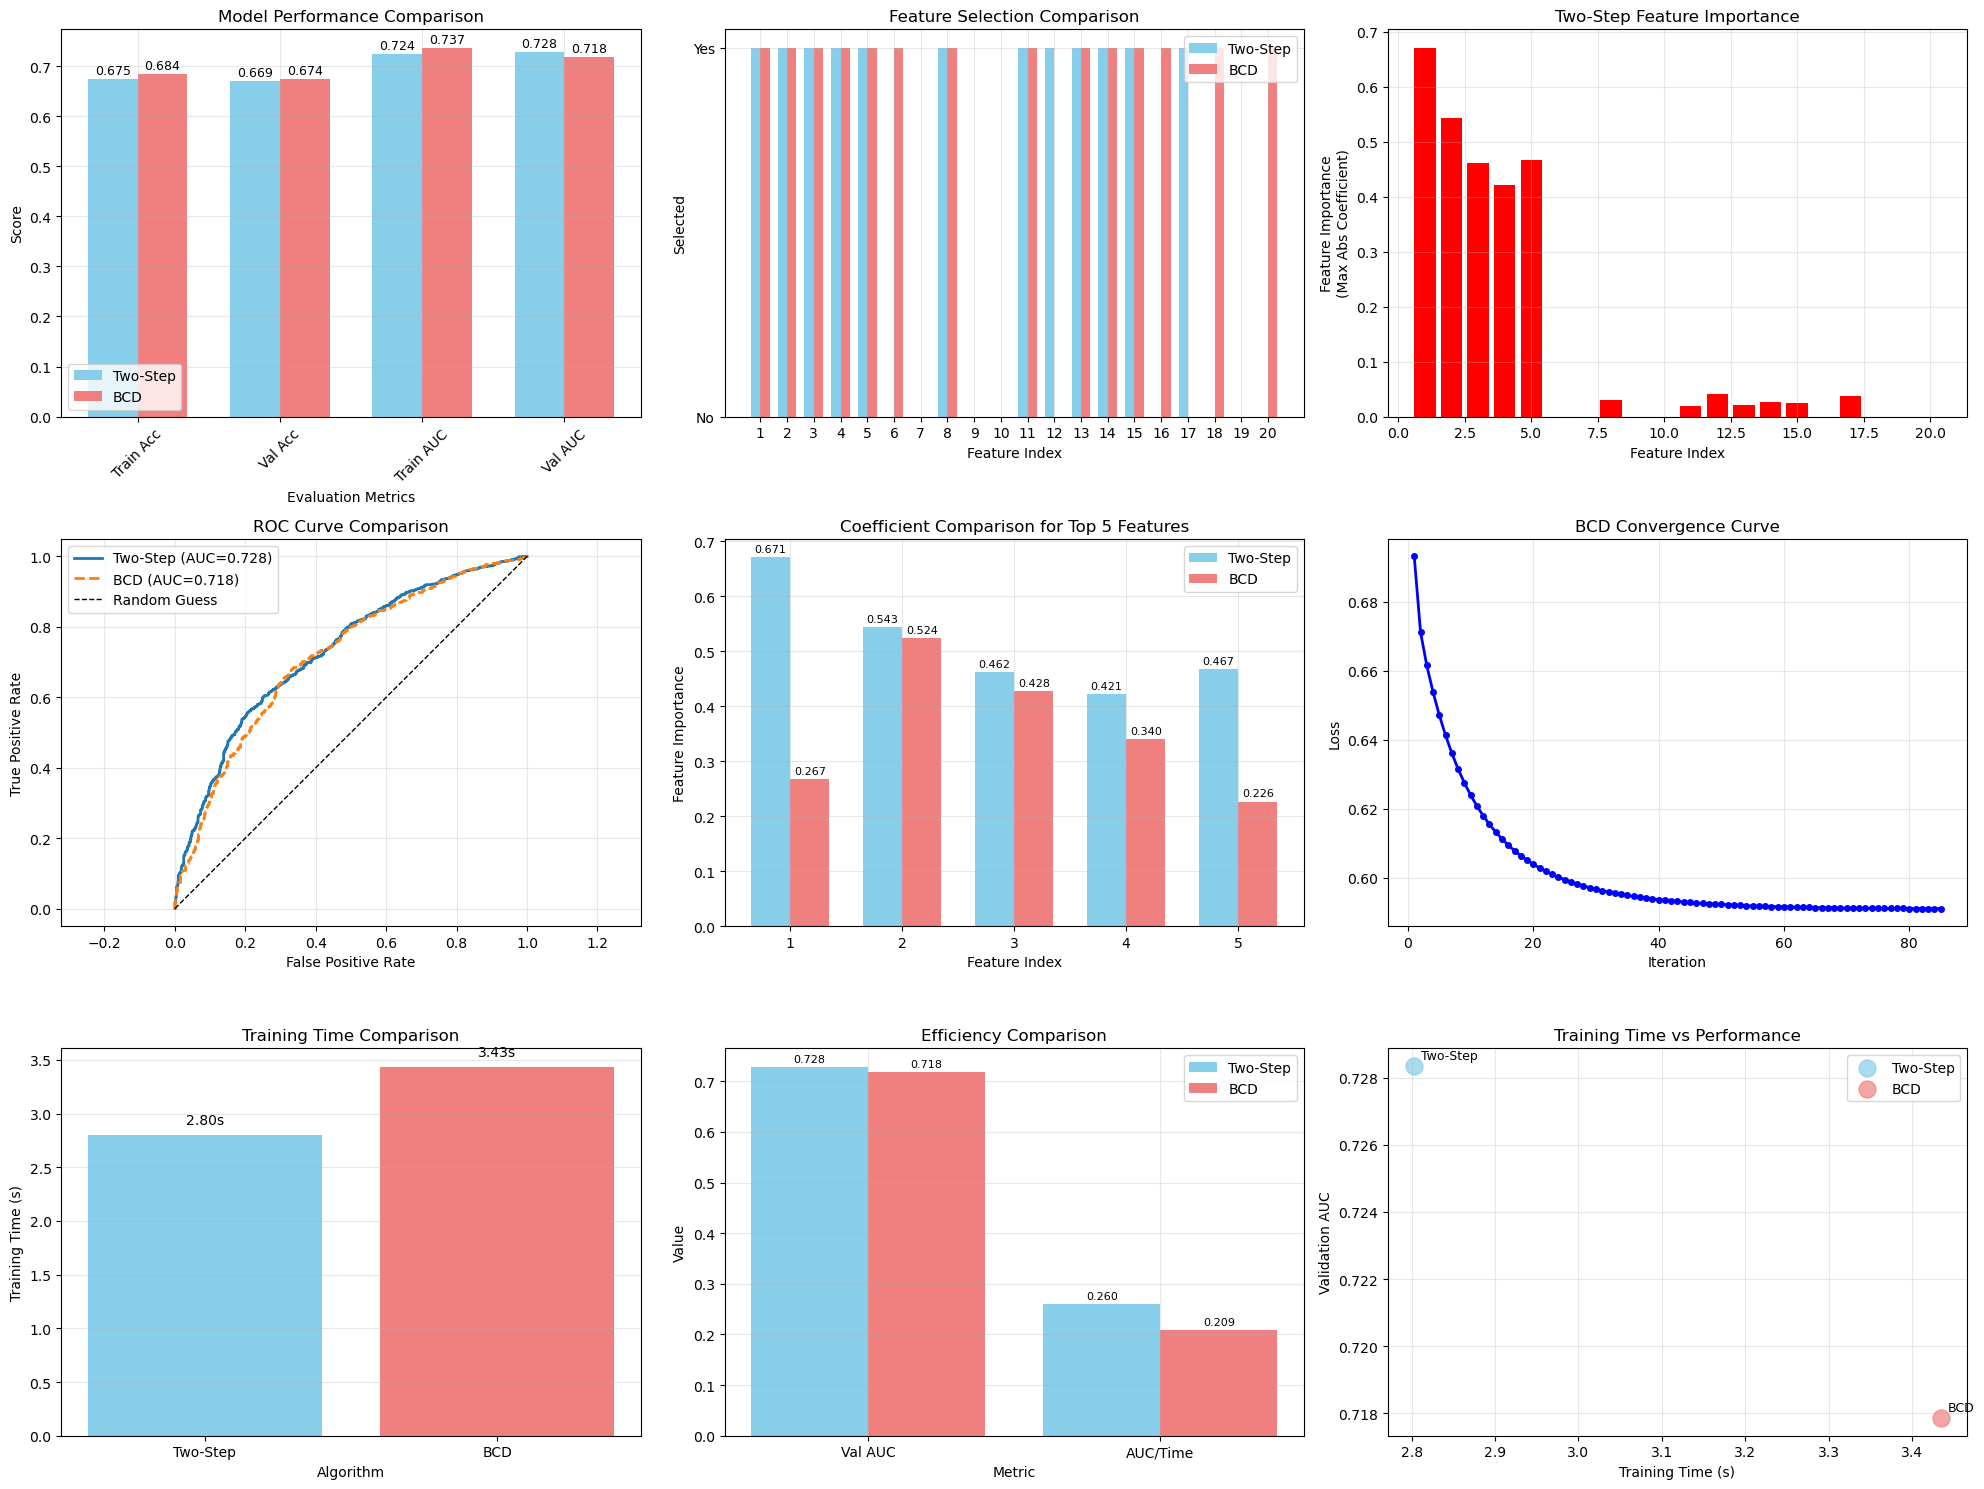


详细结果比较

特征选择对比:
特征         真实效应            两步法        BCD算法     
--------------------------------------------------
特征1        是               是          是         
特征2        是               是          是         
特征3        是               是          是         
特征4        是               是          是         
特征5        是               是          是         
特征6        否               否          是         
特征7        否               否          否         
特征8        否               是          是         
特征9        否               否          否         
特征10       否               否          否         
特征11       否               是          是         
特征12       否               是          否         
特征13       否               是          是         
特征14       否               是          是         
特征15       否               是          是         
特征16       否               否          是         
特征17       否               是          否         
特征18       否               否          是         
特

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from scipy.special import expit
import time
import warnings
warnings.filterwarnings('ignore')

# 使用相同的随机种子确保可重复性
np.random.seed(42)

# 生成数据
n_samples = 10000
n_features = 20
X = np.random.randn(n_samples, n_features)

true_effect = np.zeros(n_samples)
true_effect += np.where(X[:, 0] < -1, 1.2, np.where(X[:, 0] > 1, -0.8, 0.3))
true_effect += np.where(X[:, 1] < 0, 0.8, -0.6)
true_effect += np.where(X[:, 2] < -1.5, -1.0, 
                       np.where(X[:, 2] < 0, -0.5,
                               np.where(X[:, 2] < 1.5, 0.5, 1.0)))
true_effect += 0.5 * X[:, 3]
true_effect += np.where(X[:, 4] > 0.8, 0.9, 0)

y_proba = expit(true_effect + np.random.randn(n_samples) * 2)
y = (y_proba >= 0.5).astype(int)

# 划分训练集和验证集
split_idx = int(0.8 * n_samples)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

print(f"训练集大小: {X_train.shape}, 验证集大小: {X_val.shape}")
print(f"正样本比例: 训练集={y_train.mean():.3f}, 验证集={y_val.mean():.3f}")


class TwoStepBinningLasso:
    """
    两步法：先聚类分箱，再用Lasso进行变量选择
    """
    def __init__(self, n_bins=15, C=0.1, random_state=42):
        self.n_bins = n_bins
        self.C = C
        self.random_state = random_state
        self.bin_edges = None
        self.models = None
        self.lasso_model = None
        self.feature_selected = None
        self.feature_importances = None
        self.training_time = None
        
    def cluster_binning(self, X):
        """对每个特征独立进行聚类分箱"""
        n_samples, n_features = X.shape
        X_binned = np.zeros_like(X)
        self.bin_edges = []
        self.models = []
        
        for j in range(n_features):
            kmeans = KMeans(n_clusters=self.n_bins, random_state=self.random_state, n_init=10)
            kmeans.fit(X[:, j].reshape(-1, 1))
            
            centers = kmeans.cluster_centers_.flatten()
            sorted_centers = np.sort(centers)
            
            bin_edges_j = np.concatenate([
                [X[:, j].min() - 1e-5],
                (sorted_centers[:-1] + sorted_centers[1:]) / 2,
                [X[:, j].max() + 1e-5]
            ])
            
            bin_edges_j = np.sort(bin_edges_j)
            self.bin_edges.append(bin_edges_j)
            self.models.append(kmeans)
            
            X_binned[:, j] = np.digitize(X[:, j], bin_edges_j[1:-1])
            
        return X_binned
    
    def one_hot_encode(self, X_binned, bin_edges=None):
        """将分箱结果转换为独热编码（丢弃第一个箱作为参照）"""
        if bin_edges is None:
            bin_edges = self.bin_edges
            
        n_samples, n_features = X_binned.shape
        onehot_features = []
        
        for j in range(n_features):
            Kj = len(bin_edges[j]) - 1
            onehot = np.zeros((n_samples, Kj))
            
            binned_vals = np.clip(X_binned[:, j].astype(int), 0, Kj-1)
            
            for i in range(n_samples):
                if binned_vals[i] >= 0 and binned_vals[i] < Kj:
                    onehot[i, binned_vals[i]] = 1
            
            onehot = onehot[:, 1:]
            onehot_features.append(onehot)
        
        return np.hstack(onehot_features)
    
    def fit(self, X_train, y_train, X_val=None, y_val=None):
        """训练两步法模型"""
        start_time = time.time()
        
        print("第一步：聚类分箱...")
        X_train_binned = self.cluster_binning(X_train)
        
        X_train_onehot = self.one_hot_encode(X_train_binned)
        print(f"分箱后特征维度: {X_train_onehot.shape[1]}")
        
        print("第二步：Lasso变量选择...")
        
        self.lasso_model = LogisticRegression(
            penalty='l1',
            C=self.C,
            solver='liblinear',
            random_state=self.random_state,
            max_iter=1000
        )
        
        self.lasso_model.fit(X_train_onehot, y_train)
        
        coefficients = self.lasso_model.coef_.flatten()
        
        n_original_features = len(self.bin_edges)
        n_bins_per_feature = [len(edges) - 2 for edges in self.bin_edges]
        
        self.feature_selected = []
        self.feature_importances = np.zeros(n_original_features)
        start_idx = 0
        
        for j in range(n_original_features):
            n_bins = n_bins_per_feature[j]
            feature_coefs = coefficients[start_idx:start_idx + n_bins]
            
            importance = np.max(np.abs(feature_coefs))
            self.feature_importances[j] = importance
            
            is_selected = np.any(np.abs(feature_coefs) > 1e-6)
            self.feature_selected.append(is_selected)
            
            start_idx += n_bins
        
        end_time = time.time()
        self.training_time = end_time - start_time
        
        print(f"Lasso模型选择特征数: {np.sum(self.feature_selected)}/{n_original_features}")
        print(f"训练时间: {self.training_time:.2f}秒")
        return self
    
    def predict_proba(self, X):
        """预测概率"""
        if self.lasso_model is None:
            raise ValueError("模型未训练，请先调用fit方法")
        
        n_samples, n_features = X.shape
        X_binned = np.zeros((n_samples, n_features))
        
        for j in range(n_features):
            X_binned[:, j] = np.digitize(X[:, j], self.bin_edges[j][1:-1])
        
        X_onehot = self.one_hot_encode(X_binned, self.bin_edges)
        
        return self.lasso_model.predict_proba(X_onehot)[:, 1]
    
    def predict(self, X, threshold=0.5):
        """预测类别"""
        y_proba = self.predict_proba(X)
        return (y_proba >= threshold).astype(int)
    
    def get_feature_info(self):
        """获取特征信息"""
        feature_info = {}
        n_original_features = len(self.bin_edges)
        coefficients = self.lasso_model.coef_.flatten()
        
        n_bins_per_feature = [len(edges) - 2 for edges in self.bin_edges]
        start_idx = 0
        
        for j in range(n_original_features):
            n_bins = n_bins_per_feature[j]
            feature_coefs = coefficients[start_idx:start_idx + n_bins]
            
            bin_edges_j = self.bin_edges[j]
            bin_intervals = []
            
            for k in range(len(bin_edges_j) - 1):
                bin_intervals.append((bin_edges_j[k], bin_edges_j[k+1]))
            
            bin_intervals = bin_intervals[1:]
            
            feature_info[f"feature_{j+1}"] = {
                "is_selected": self.feature_selected[j],
                "importance": self.feature_importances[j],
                "final_bins_count": n_bins,
                "final_bin_intervals": bin_intervals,
                "bin_coefficients": feature_coefs.tolist()
            }
            
            start_idx += n_bins
        
        return feature_info


# 运行两步法模型
print("\n" + "="*50)
print("两步法模型训练")
print("="*50)

two_step_model = TwoStepBinningLasso(n_bins=15, C=0.05)
two_step_model.fit(X_train, y_train, X_val, y_val)

# 评估两步法模型
y_train_pred_two_step = two_step_model.predict(X_train)
y_val_pred_two_step = two_step_model.predict(X_val)

y_train_proba_two_step = two_step_model.predict_proba(X_train)
y_val_proba_two_step = two_step_model.predict_proba(X_val)

train_acc_two_step = accuracy_score(y_train, y_train_pred_two_step)
val_acc_two_step = accuracy_score(y_val, y_val_pred_two_step)
train_auc_two_step = roc_auc_score(y_train, y_train_proba_two_step)
val_auc_two_step = roc_auc_score(y_val, y_val_proba_two_step)

print(f"\n两步法模型结果:")
print(f"训练集准确率: {train_acc_two_step:.4f}")
print(f"验证集准确率: {val_acc_two_step:.4f}")
print(f"训练集AUC: {train_auc_two_step:.4f}")
print(f"验证集AUC: {val_auc_two_step:.4f}")

# 获取两步法特征信息
two_step_feature_info = two_step_model.get_feature_info()
two_step_selected_features = [i+1 for i, selected in enumerate(two_step_model.feature_selected) if selected]
print(f"\n两步法选中的特征: {two_step_selected_features}")


# 运行您的BCD算法
print("\n" + "="*50)
print("您的BCD算法训练")
print("="*50)

# 记录BCD算法开始时间
bcd_start_time = time.time()

# 运行您的BCD算法
bcd_model = BCDOptimalBinning(
        lambda_f=2e-5, 
        lambda_b=1e-6,
        max_iter=5000, 
        tol=1e-6, 
        verbose=True,
        metric='auc',
        early_stopping_rounds=7,  # AUC连续7轮不提升则停止
        min_iter=10,  # 至少迭代10轮
        patience=20   # 最多容忍20轮不提升
    )

bcd_model.fit(X_train, y_train, X_val, y_val, n_pre_bins=15)

# 记录BCD算法结束时间
bcd_end_time = time.time()
bcd_training_time = bcd_end_time - bcd_start_time

# 评估BCD算法
y_train_pred_bcd = bcd_model.predict(X_train)
y_val_pred_bcd = bcd_model.predict(X_val)

y_train_proba_bcd = bcd_model.predict_proba(X_train)
y_val_proba_bcd = bcd_model.predict_proba(X_val)

train_acc_bcd = accuracy_score(y_train, y_train_pred_bcd)
val_acc_bcd = accuracy_score(y_val, y_val_pred_bcd)
train_auc_bcd = roc_auc_score(y_train, y_train_proba_bcd)
val_auc_bcd = roc_auc_score(y_val, y_val_proba_bcd)

# 获取BCD算法选中的特征
binning_result = bcd_model.get_optimal_binning_structure()
bcd_selected_features = []
for j in range(1, 21):  # 因为我们有20个特征
    feat_name = f"feature_{j}"
    if binning_result[feat_name]["is_selected"]:
        bcd_selected_features.append(j)

print(f"\nBCD算法结果:")
print(f"训练集准确率: {train_acc_bcd:.4f}")
print(f"验证集准确率: {val_acc_bcd:.4f}")
print(f"训练集AUC: {train_auc_bcd:.4f}")
print(f"验证集AUC: {val_auc_bcd:.4f}")
print(f"训练时间: {bcd_training_time:.2f}秒")
print(f"BCD算法选中的特征: {bcd_selected_features}")

# 获取BCD算法的损失历史
bcd_loss_history = bcd_model.history['loss']

# 可视化比较结果
plt.figure(figsize=(20, 15))

# 1. Model Performance Comparison
plt.subplot(3, 3, 1)
metrics = ['Train Acc', 'Val Acc', 'Train AUC', 'Val AUC']
two_step_values = [train_acc_two_step, val_acc_two_step, train_auc_two_step, val_auc_two_step]
bcd_values = [train_acc_bcd, val_acc_bcd, train_auc_bcd, val_auc_bcd]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, two_step_values, width, label='Two-Step', color='skyblue')
plt.bar(x + width/2, bcd_values, width, label='BCD', color='lightcoral')
plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# Add value labels on bars
for i, (v1, v2) in enumerate(zip(two_step_values, bcd_values)):
    plt.text(i - width/2, v1 + 0.01, f'{v1:.3f}', ha='center', fontsize=9)
    plt.text(i + width/2, v2 + 0.01, f'{v2:.3f}', ha='center', fontsize=9)

# 2. Feature Selection Comparison
plt.subplot(3, 3, 2)
all_features = list(range(1, n_features + 1))
two_step_selection = [1 if f in two_step_selected_features else 0 for f in all_features]
bcd_selection = [1 if f in bcd_selected_features else 0 for f in all_features]

x = np.arange(len(all_features))
plt.bar(x - width/2, two_step_selection, width, label='Two-Step', color='skyblue')
plt.bar(x + width/2, bcd_selection, width, label='BCD', color='lightcoral')
plt.xlabel('Feature Index')
plt.ylabel('Selected')
plt.title('Feature Selection Comparison')
plt.xticks(x, all_features)
plt.yticks([0, 1], ['No', 'Yes'])
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Feature Importance (Two-Step)
plt.subplot(3, 3, 3)
importance_values = two_step_model.feature_importances
colors = ['red' if selected else 'blue' for selected in two_step_model.feature_selected]
plt.bar(range(1, len(importance_values) + 1), importance_values, color=colors)
plt.xlabel('Feature Index')
plt.ylabel('Feature Importance\n(Max Abs Coefficient)')
plt.title('Two-Step Feature Importance')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

# 4. ROC Curve Comparison
plt.subplot(3, 3, 4)
# Two-Step ROC curve
fpr_two_step, tpr_two_step, _ = roc_curve(y_val, y_val_proba_two_step)
# BCD ROC curve
fpr_bcd, tpr_bcd, _ = roc_curve(y_val, y_val_proba_bcd)

plt.plot(fpr_two_step, tpr_two_step, label=f'Two-Step (AUC={val_auc_two_step:.3f})', linewidth=2)
plt.plot(fpr_bcd, tpr_bcd, label=f'BCD (AUC={val_auc_bcd:.3f})', linewidth=2, linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# 5. Coefficient Comparison for Top 5 Features
plt.subplot(3, 3, 5)
effective_features = [1, 2, 3, 4, 5]
two_step_coefs = []
bcd_coefs = []

# Get Two-Step feature coefficients
for feat in effective_features:
    two_step_coefs.append(two_step_model.feature_importances[feat-1])
    
# Get BCD feature coefficients
for feat in effective_features:
    feat_name = f"feature_{feat}"
    feat_info = binning_result[feat_name]
    if feat_info['is_selected'] and len(feat_info['final_bin_coefficients']) > 0:
        coefs = np.array(feat_info['final_bin_coefficients'])
        importance = np.mean(np.abs(coefs))
        bcd_coefs.append(importance)
    else:
        bcd_coefs.append(0)

x = np.arange(len(effective_features))
plt.bar(x - width/2, two_step_coefs, width, label='Two-Step', color='skyblue')
plt.bar(x + width/2, bcd_coefs, width, label='BCD', color='lightcoral')
plt.xlabel('Feature Index')
plt.ylabel('Feature Importance')
plt.title('Coefficient Comparison for Top 5 Features')
plt.xticks(x, effective_features)
plt.legend()
plt.grid(True, alpha=0.3)

# Add value labels on bars
for i, (v1, v2) in enumerate(zip(two_step_coefs, bcd_coefs)):
    plt.text(i - width/2, v1 + 0.01, f'{v1:.3f}', ha='center', fontsize=8)
    plt.text(i + width/2, v2 + 0.01, f'{v2:.3f}', ha='center', fontsize=8)

# 6. BCD Convergence Curve
plt.subplot(3, 3, 6)
if len(bcd_loss_history) > 0:
    iterations = range(1, len(bcd_loss_history) + 1)
    plt.plot(iterations, bcd_loss_history, 'b-', linewidth=2, marker='o', markersize=4)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('BCD Convergence Curve')
    plt.grid(True, alpha=0.3)
    
    if max(bcd_loss_history) / min(bcd_loss_history) > 100:
        plt.yscale('log')

# 7. Training Time Comparison
plt.subplot(3, 3, 7)
algorithms = ['Two-Step', 'BCD']
training_times = [two_step_model.training_time, bcd_training_time]

plt.bar(algorithms, training_times, color=['skyblue', 'lightcoral'])
plt.xlabel('Algorithm')
plt.ylabel('Training Time (s)')
plt.title('Training Time Comparison')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(training_times):
    plt.text(i, v + 0.1, f'{v:.2f}s', ha='center')

# 8. Efficiency Comparison (Performance/Time)
plt.subplot(3, 3, 8)
# Calculate performance per second
auc_per_sec_two_step = val_auc_two_step / two_step_model.training_time
auc_per_sec_bcd = val_auc_bcd / bcd_training_time

x = np.arange(2)
width = 0.4
plt.bar(x - width/2, [val_auc_two_step, auc_per_sec_two_step], width, label='Two-Step', color='skyblue')
plt.bar(x + width/2, [val_auc_bcd, auc_per_sec_bcd], width, label='BCD', color='lightcoral')
plt.xlabel('Metric')
plt.ylabel('Value')
plt.title('Efficiency Comparison')
plt.xticks(x, ['Val AUC', 'AUC/Time'])
plt.legend()
plt.grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate([val_auc_two_step, auc_per_sec_two_step]):
    plt.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)
for i, v in enumerate([val_auc_bcd, auc_per_sec_bcd]):
    plt.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)

# 9. Training Time vs Performance Scatter Plot
plt.subplot(3, 3, 9)
plt.scatter(two_step_model.training_time, val_auc_two_step, s=150, label='Two-Step', color='skyblue', alpha=0.7)
plt.scatter(bcd_training_time, val_auc_bcd, s=150, label='BCD', color='lightcoral', alpha=0.7)

# Add labels
plt.annotate('Two-Step', (two_step_model.training_time, val_auc_two_step), 
             xytext=(5, 5), textcoords='offset points', fontsize=9)
plt.annotate('BCD', (bcd_training_time, val_auc_bcd), 
             xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.xlabel('Training Time (s)')
plt.ylabel('Validation AUC')
plt.title('Training Time vs Performance')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# 创建详细的结果表格
print("\n" + "="*50)
print("详细结果比较")
print("="*50)

# 创建特征选择对比表格
print("\n特征选择对比:")
print(f"{'特征':<10} {'真实效应':<15} {'两步法':<10} {'BCD算法':<10}")
print("-" * 50)

for i in range(1, n_features + 1):
    has_true_effect = "是" if i <= 5 else "否"
    two_step_sel = "是" if i in two_step_selected_features else "否"
    bcd_sel = "是" if i in bcd_selected_features else "否"
    print(f"{f'特征{i}':<10} {has_true_effect:<15} {two_step_sel:<10} {bcd_sel:<10}")

# 计算评估指标
print("\n模型评估指标对比:")
print(f"{'指标':<20} {'两步法':<10} {'BCD算法':<10} {'差异':<10}")
print("-" * 50)

metrics_data = [
    ("训练集准确率", train_acc_two_step, train_acc_bcd, train_acc_bcd - train_acc_two_step),
    ("验证集准确率", val_acc_two_step, val_acc_bcd, val_acc_bcd - val_acc_two_step),
    ("训练集AUC", train_auc_two_step, train_auc_bcd, train_auc_bcd - train_auc_two_step),
    ("验证集AUC", val_auc_two_step, val_auc_bcd, val_auc_bcd - val_auc_two_step)
]

for metric_name, two_step_val, bcd_val, diff in metrics_data:
    print(f"{metric_name:<20} {two_step_val:<10.4f} {bcd_val:<10.4f} {diff:<10.4f}")

# 时间对比
print("\n训练时间对比:")
print(f"{'算法':<10} {'训练时间(秒)':<15} {'验证集AUC':<15} {'AUC/时间':<15}")
print("-" * 55)
print(f"{'两步法':<10} {two_step_model.training_time:<15.2f} {val_auc_two_step:<15.4f} {val_auc_two_step/two_step_model.training_time:<15.6f}")
print(f"{'BCD算法':<10} {bcd_training_time:<15.2f} {val_auc_bcd:<15.4f} {val_auc_bcd/bcd_training_time:<15.6f}")

# 计算特征选择准确率
true_selected = [1] * 5 + [0] * 15
two_step_selection_binary = [1 if i+1 in two_step_selected_features else 0 for i in range(20)]
bcd_selection_binary = [1 if i+1 in bcd_selected_features else 0 for i in range(20)]

# 计算精确率、召回率、F1分数
def calculate_metrics(true, pred):
    tp = np.sum([1 for t, p in zip(true, pred) if t == 1 and p == 1])
    fp = np.sum([1 for t, p in zip(true, pred) if t == 0 and p == 1])
    fn = np.sum([1 for t, p in zip(true, pred) if t == 1 and p == 0])
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return precision, recall, f1

two_step_precision, two_step_recall, two_step_f1 = calculate_metrics(true_selected, two_step_selection_binary)
bcd_precision, bcd_recall, bcd_f1 = calculate_metrics(true_selected, bcd_selection_binary)

print("\n特征选择性能:")
print(f"{'指标':<10} {'两步法':<10} {'BCD算法':<10}")
print("-" * 35)
print(f"{'精确率':<10} {two_step_precision:<10.4f} {bcd_precision:<10.4f}")
print(f"{'召回率':<10} {two_step_recall:<10.4f} {bcd_recall:<10.4f}")
print(f"{'F1分数':<10} {two_step_f1:<10.4f} {bcd_f1:<10.4f}")

# 模型复杂度比较
print("\n模型复杂度比较:")
print(f"{'指标':<20} {'两步法':<10} {'BCD算法':<10}")
print("-" * 45)
print(f"{'选中特征数':<20} {len(two_step_selected_features):<10} {len(bcd_selected_features):<10}")

# 输出两步法的系数信息
two_step_nonzero_coefs = np.sum(np.abs(two_step_model.lasso_model.coef_) > 1e-6)
print(f"{'非零系数数量':<20} {two_step_nonzero_coefs:<10} {'-':<10}")

# 输出BCD算法的分箱信息
bcd_total_bins = 0
for feat_name, feat_info in binning_result.items():
    if feat_info['is_selected']:
        bcd_total_bins += feat_info['final_bins_count']
print(f"{'总有效分箱数':<20} {'-':<10} {bcd_total_bins:<10}")

# 输出结论
print("\n" + "="*50)
print("结论分析")
print("="*50)
print("1. 模型性能:")
print(f"   - 两步法验证集AUC: {val_auc_two_step:.4f}")
print(f"   - BCD算法验证集AUC: {val_auc_bcd:.4f}")
print(f"   - AUC差异: {val_auc_bcd - val_auc_two_step:.4f} ({'BCD算法更优' if val_auc_bcd > val_auc_two_step else '两步法更优'})")

print("\n2. 计算效率:")
print(f"   - 两步法训练时间: {two_step_model.training_time:.2f}秒")
print(f"   - BCD算法训练时间: {bcd_training_time:.2f}秒")
print(f"   - 时间差异: {bcd_training_time/two_step_model.training_time:.2f}倍")

print("\n3. 特征选择准确性:")
print(f"   - 两步法精确率: {two_step_precision:.4f}, 召回率: {two_step_recall:.4f}, F1分数: {two_step_f1:.4f}")
print(f"   - BCD算法精确率: {bcd_precision:.4f}, 召回率: {bcd_recall:.4f}, F1分数: {bcd_f1:.4f}")

print("\n4. 选中的特征:")
print(f"   - 两步法: {two_step_selected_features}")
print(f"   - BCD算法: {bcd_selected_features}")
print(f"   - 真实有效特征: {list(range(1, 6))}")

print("\n5. 综合评估:")
if val_auc_bcd > val_auc_two_step and bcd_training_time < two_step_model.training_time * 5:
    print("   - BCD算法在性能和计算效率上均表现更好")
elif val_auc_bcd > val_auc_two_step:
    print("   - BCD算法性能更好，但计算成本更高")
elif val_auc_bcd < val_auc_two_step and bcd_training_time < two_step_model.training_time:
    print("   - 两步法性能更好，且计算更快")
else:
    print("   - 两步法性能更好，但BCD算法计算更快")

print("\n6. 选择建议:")
if val_auc_bcd > val_auc_two_step:
    if bcd_training_time < two_step_model.training_time * 3:
        print("   - 推荐使用BCD算法，它在性能和效率上都有优势")
    else:
        print("   - 如果追求最佳性能且计算资源充足，选择BCD算法")
        print("   - 如果需要快速建模，选择两步法")
else:
    if two_step_model.training_time < bcd_training_time:
        print("   - 推荐使用两步法，它在性能和效率上都有优势")
    else:
        print("   - 两步法性能更好，但BCD算法计算更快")
        print("   - 根据具体需求选择：性能优先选两步法，速度优先选BCD算法")

简单分箱结构加入optbinning之比较

Train size: (8000, 20), Val size: (2000, 20)
Positive ratio: Train=0.657, Val=0.639

Two-Step Model Training
Two-Step: Step 1 - Cluster binning...
Two-Step: One-hot dim: 280
Two-Step: Step 2 - Lasso selection...
Two-Step: Selected 8/20 features, time=3.33s
Two-Step Train Acc: 0.8541, Val Acc: 0.8385
Two-Step Train AUC: 0.9300, Val AUC: 0.9189
Two-Step Selected Features: [1, 2, 3, 4, 5, 6, 8, 15]

BCD Algorithm Training
Iter    1 | Loss: 0.622530 | Drop: 0.07061686 | Train Auc: 0.891627 | Val Auc: 0.875066
Iter    3 | Loss: 0.575852 | Drop: 0.02039540 | Train Auc: 0.910030 | Val Auc: 0.894578
Iter    5 | Loss: 0.542184 | Drop: 0.01583393 | Train Auc: 0.912744 | Val Auc: 0.897317
Iter    7 | Loss: 0.515399 | Drop: 0.01265608 | Train Auc: 0.913796 | Val Auc: 0.898421
Iter    9 | Loss: 0.493750 | Drop: 0.01027010 | Train Auc: 0.914508 | Val Auc: 0.899097
Iter   11 | Loss: 0.475989 | Drop: 0.00845758 | Train Auc: 0.915154 | Val Auc: 0.899793
Iter   13 | Loss: 0.461211 | Drop: 0.00706215 | T

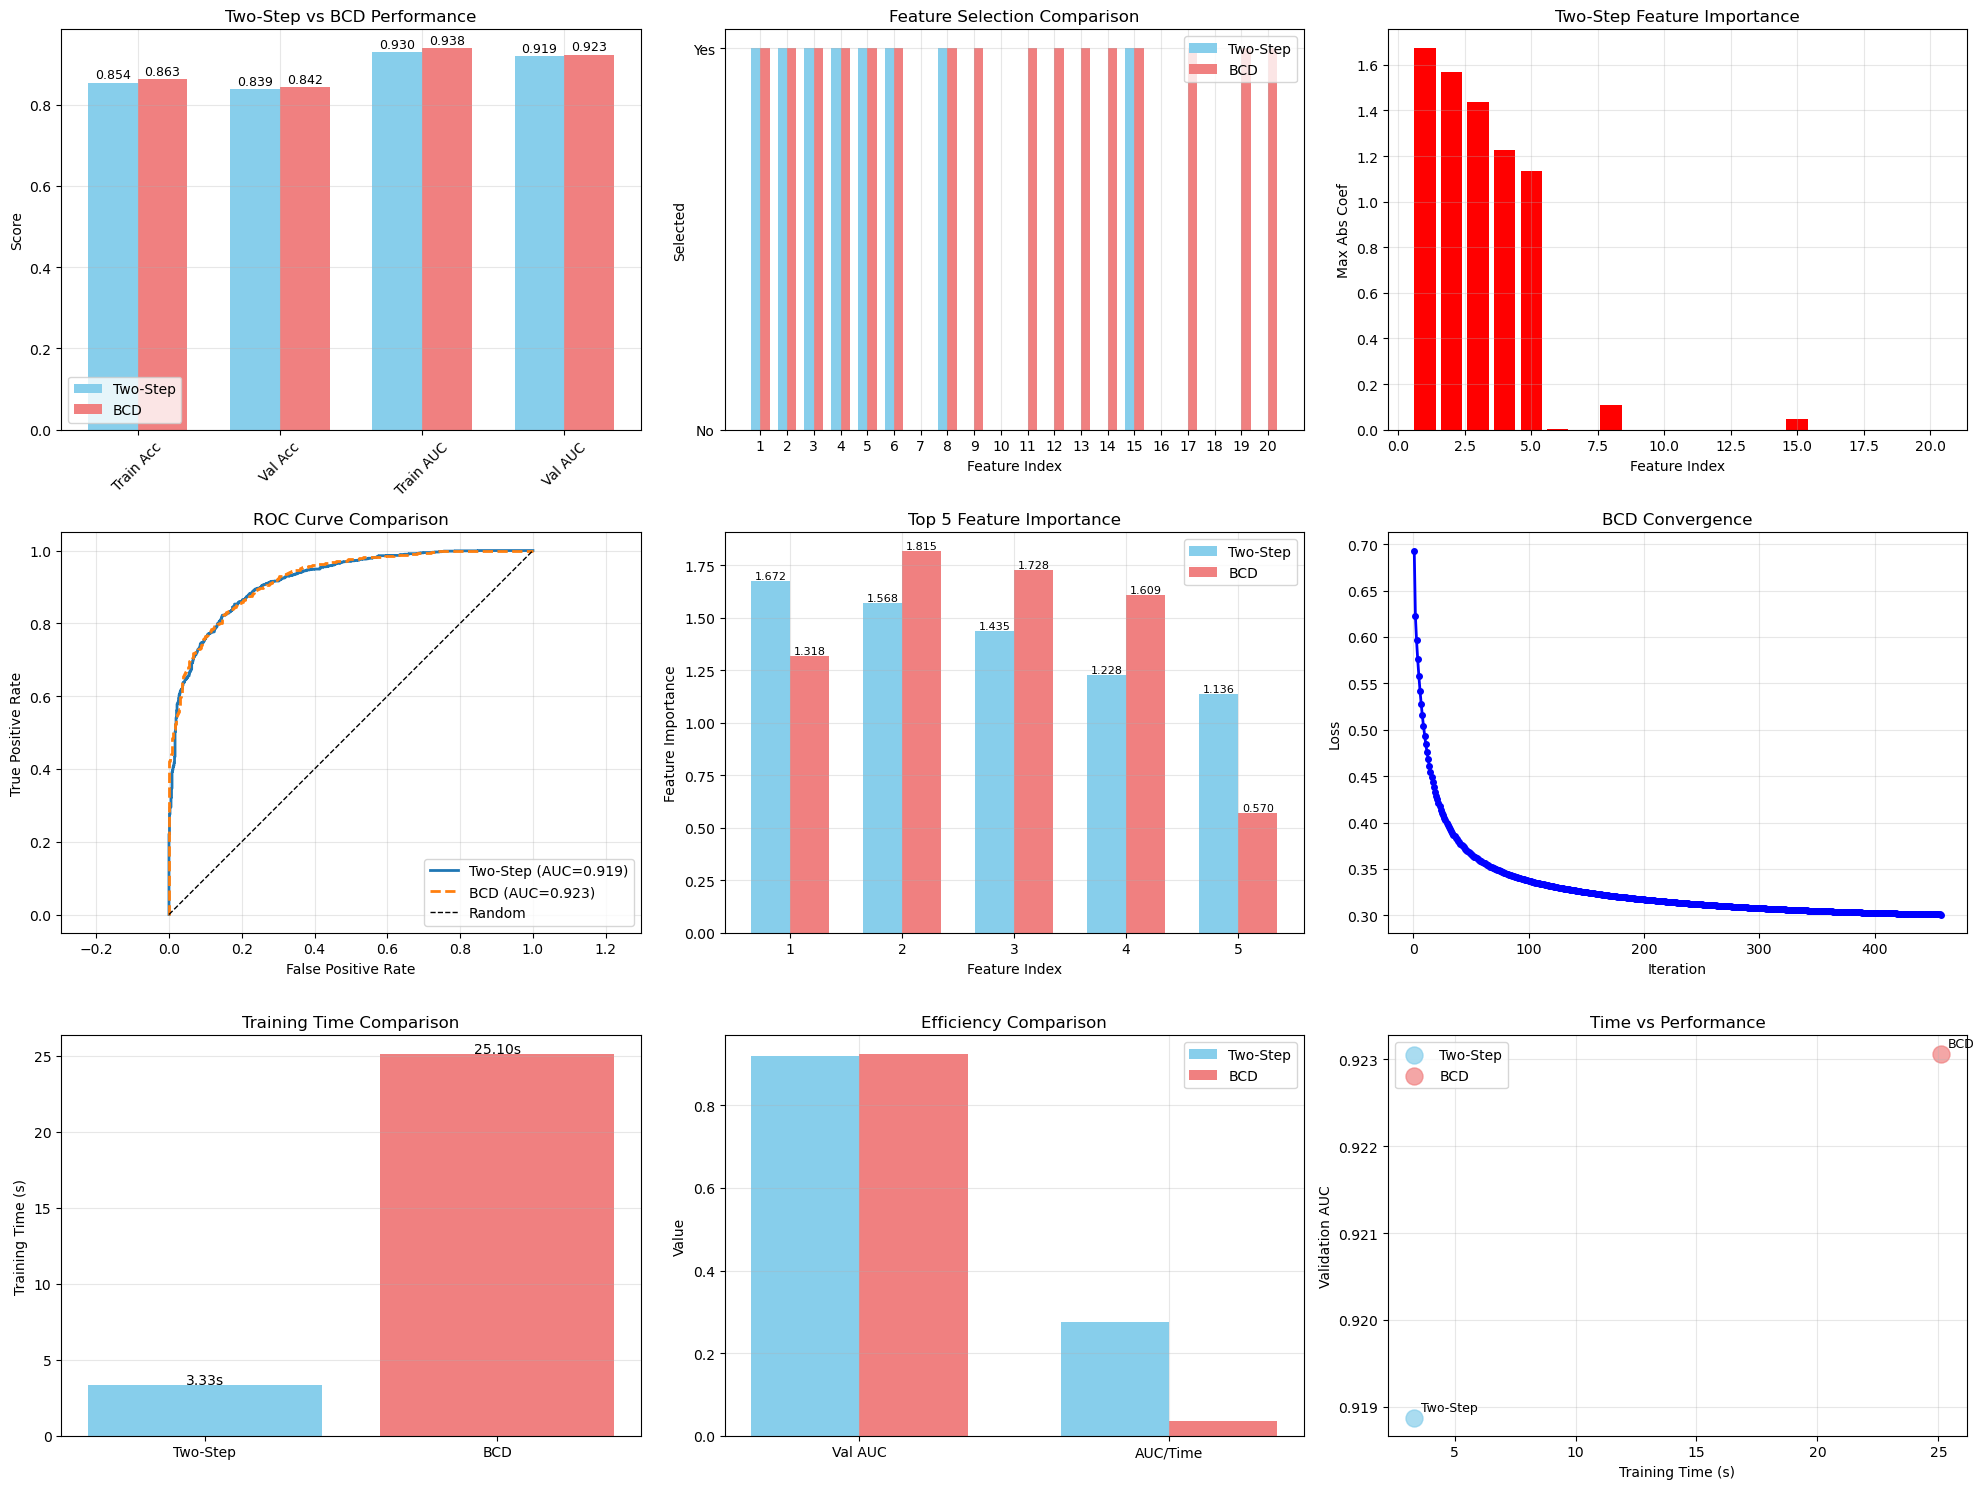

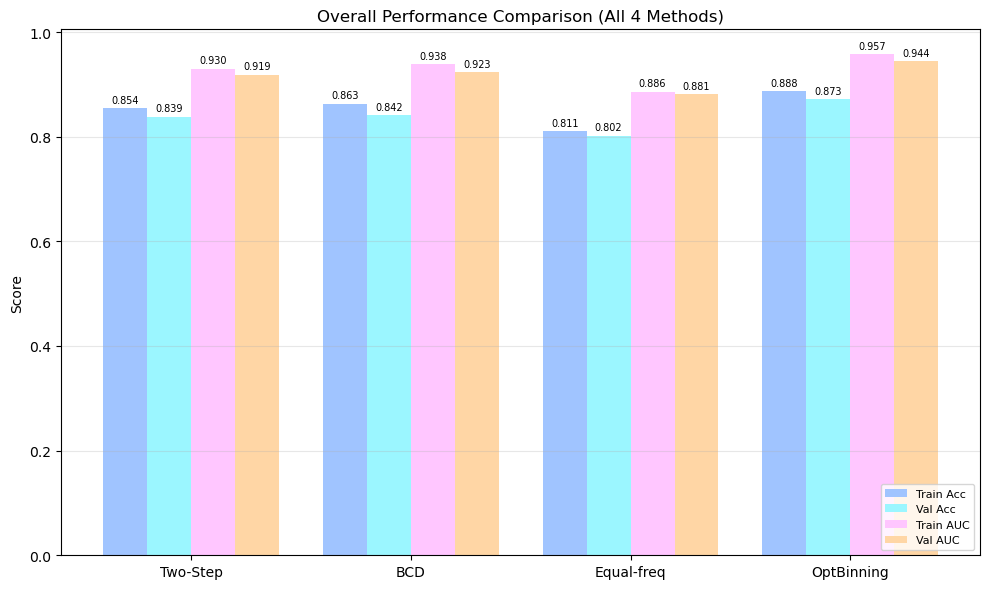

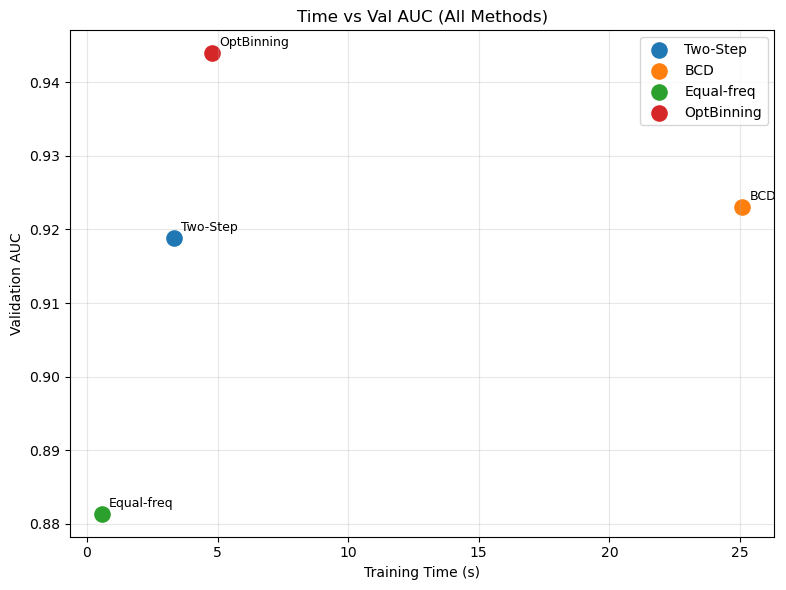


Detailed Comparison (All Methods)

--- Performance Metrics ---
Method           Train Acc    Val Acc  Train AUC    Val AUC    Time(s)
-----------------------------------------------------------------
Two-Step            0.8541     0.8385     0.9300     0.9189       3.33
BCD                 0.8632     0.8420     0.9382     0.9231      25.10
Equal-freq          0.8113     0.8020     0.8861     0.8814       0.58
OptBinning          0.8876     0.8725     0.9574     0.9439       4.79

--- Feature Selection (Two-Step / BCD) ---
Feature    True Effect  Two-Step   BCD       
---------------------------------------------
Feature 1  Yes          Yes        Yes       
Feature 2  Yes          Yes        Yes       
Feature 3  Yes          Yes        Yes       
Feature 4  Yes          Yes        Yes       
Feature 5  Yes          Yes        Yes       
Feature 6  No           Yes        Yes       
Feature 7  No           No         No        
Feature 8  No           Yes        Yes       
Feature 9  

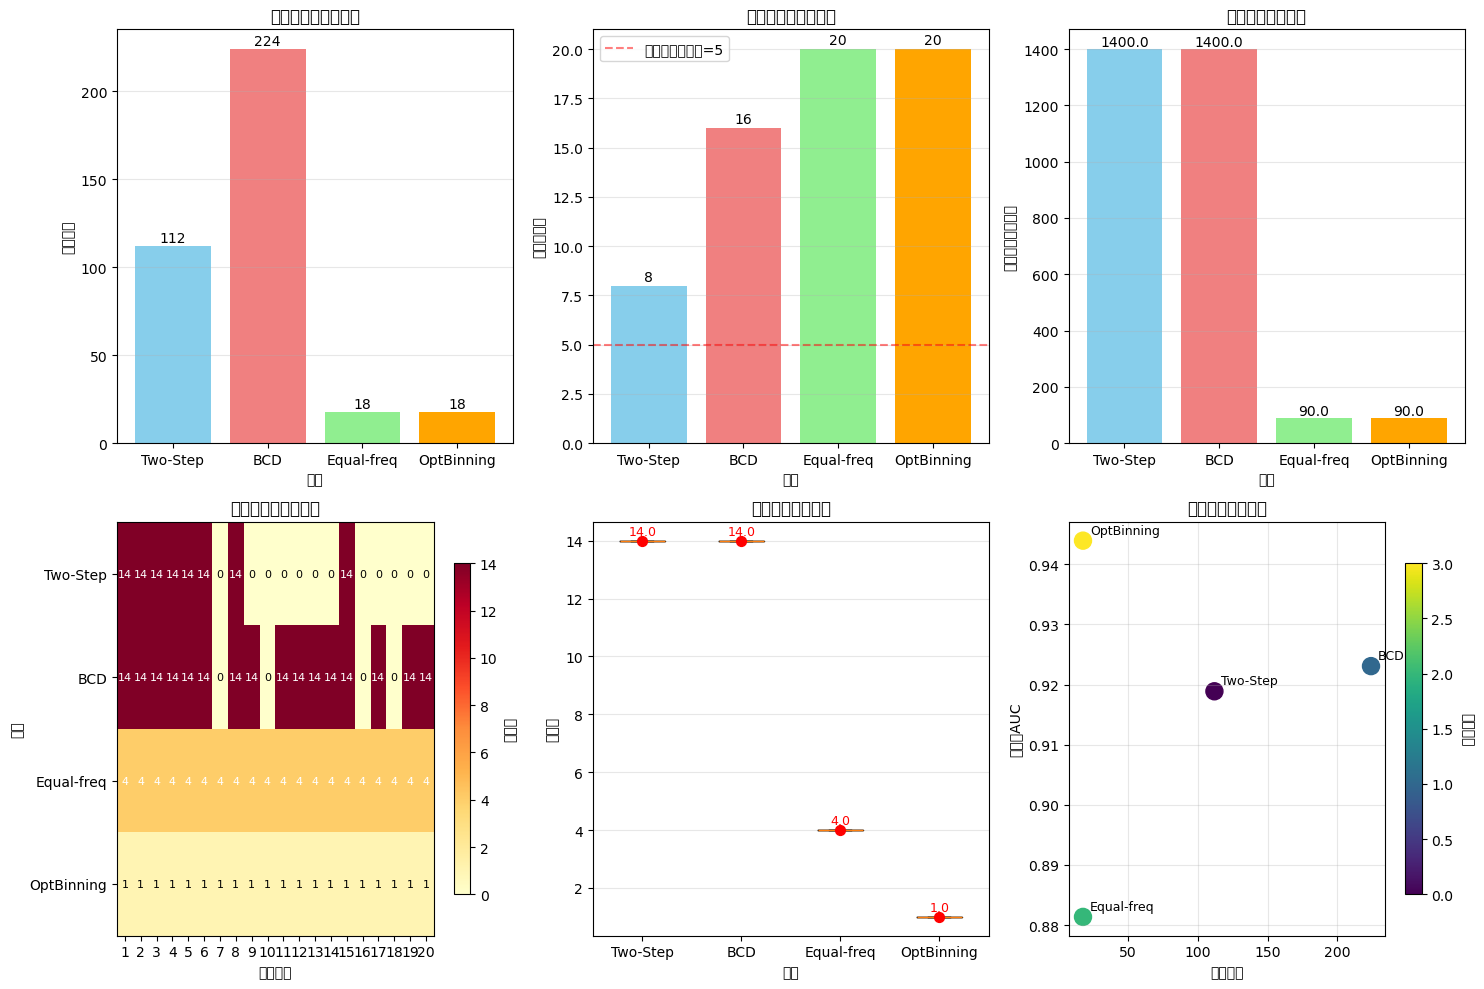

<Figure size 1500x800 with 0 Axes>

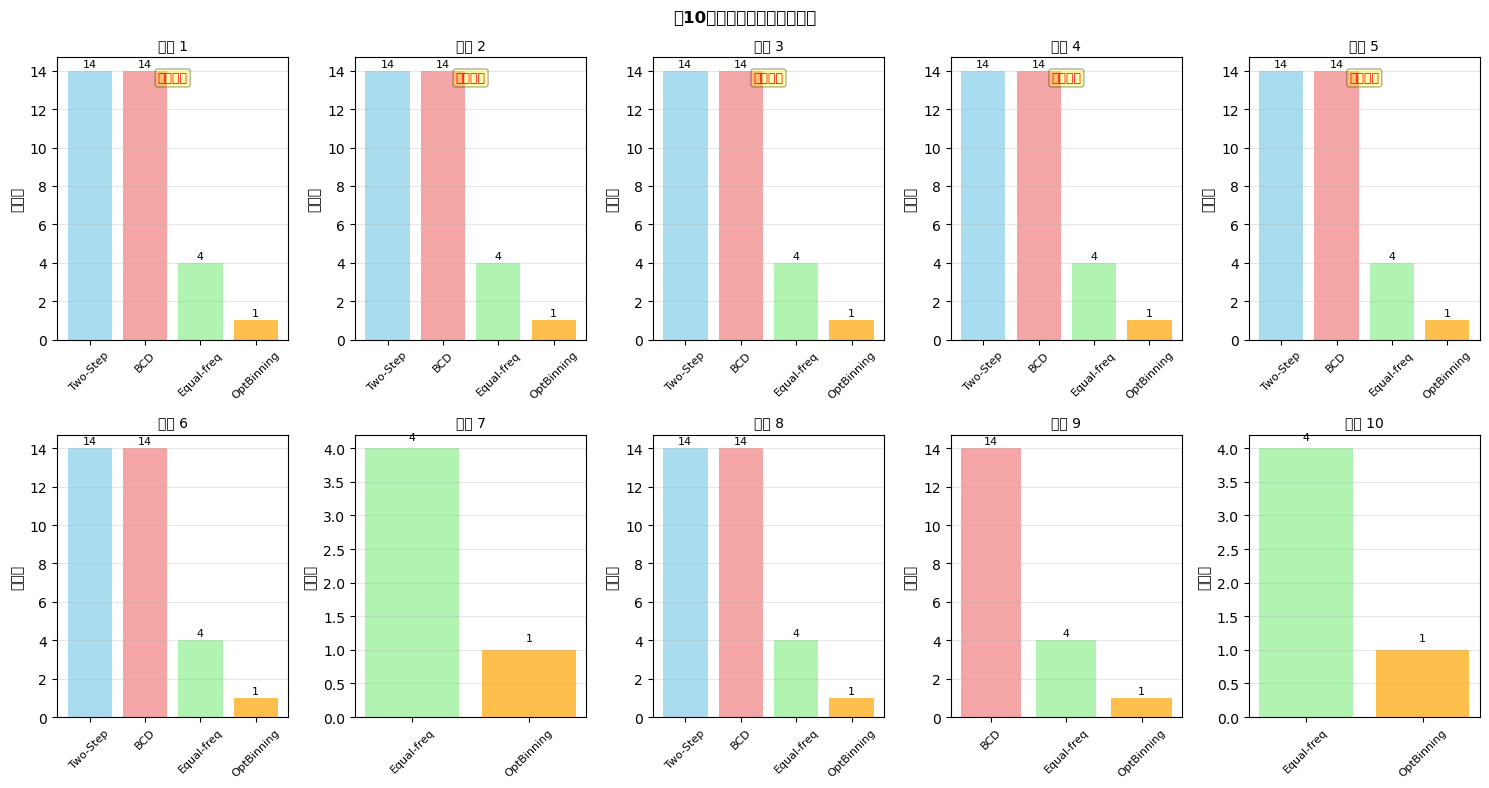


--- 详细分箱信息 ---
特征       真实效应       两步法          BCD          等频分箱         OptBinning  
--------------------------------------------------------------------------------
特征1      是          14箱          14箱          4箱           1箱          
特征2      是          14箱          14箱          4箱           1箱          
特征3      是          14箱          14箱          4箱           1箱          
特征4      是          14箱          14箱          4箱           1箱          
特征5      是          14箱          14箱          4箱           1箱          
特征6      否          14箱          14箱          4箱           1箱          
特征7      否          未选中          未选中          4箱           1箱          
特征8      否          14箱          14箱          4箱           1箱          
特征9      否          未选中          14箱          4箱           1箱          
特征10     否          未选中          未选中          4箱           1箱          
特征11     否          未选中          14箱          4箱           1箱          
特征12     否          未选中          14箱   

In [24]:
# ============================================================================
# 完整实验：两步法 vs BCD vs 等频分箱 vs OptBinning（数据统一，无占位）
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.linear_model import LassoCV, LogisticRegressionCV, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from scipy.special import expit
import time
import warnings
warnings.filterwarnings('ignore')

from optbinning import OptimalBinning   # 只需要分类版本

# ===================== 1. 生成数据（第二段代码的原始设定） =====================
np.random.seed(42)
n_samples = 10000
n_features = 20
X = np.random.randn(n_samples, n_features)

true_effect = np.zeros(n_samples)
true_effect += np.where(X[:, 0] < -1, 1.2, np.where(X[:, 0] > 1, -0.8, 0.3))
true_effect += np.where(X[:, 1] < 0, 0.8, -0.6)
true_effect += np.where(X[:, 2] < -1.5, -1.0, 
                       np.where(X[:, 2] < 0, -0.5,
                               np.where(X[:, 2] < 1.5, 0.5, 1.0)))
true_effect += 0.5 * X[:, 3]
true_effect += np.where(X[:, 4] > 0.8, 0.9, 0)

y_proba = expit(true_effect + np.random.randn(n_samples) * 0.5)
y = (y_proba >= 0.5).astype(int)

split_idx = int(0.8 * n_samples)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

print(f"Train size: {X_train.shape}, Val size: {X_val.shape}")
print(f"Positive ratio: Train={y_train.mean():.3f}, Val={y_val.mean():.3f}")

# 为等频和OptBinning准备DataFrame（保持和原始pd.qcut兼容）
df_train = pd.DataFrame(X_train, columns=[f"feat_{i}" for i in range(n_features)])
df_val = pd.DataFrame(X_val, columns=[f"feat_{i}" for i in range(n_features)])

# ===================== 2. 辅助函数：等频 & OptBinning 分箱 =====================
def equal_freq_binning_fit_transform(X_df, bins=5):
    """在训练集上拟合等频分箱，返回转换后的数组和边界字典"""
    Xb = X_df.copy()
    bin_edges_dict = {}
    for col in Xb.columns:
        if Xb[col].nunique() <= 1:
            Xb[col] = 0
            bin_edges_dict[col] = None
        else:
            binned, edges = pd.qcut(X_df[col], bins, duplicates="drop", retbins=True)
            Xb[col] = binned.cat.codes
            bin_edges_dict[col] = edges
    return Xb.values, bin_edges_dict

def equal_freq_binning_transform(X_df, bin_edges_dict):
    """利用已拟合的边界转换新数据"""
    Xb = X_df.copy()
    for col in Xb.columns:
        edges = bin_edges_dict.get(col, None)
        if edges is None or Xb[col].nunique() <= 1:
            Xb[col] = 0
        else:
            binned = pd.cut(X_df[col], bins=edges, include_lowest=True, duplicates="drop")
            Xb[col] = binned.cat.codes
    return Xb.values

def opt_binning_fit_transform(X_df, y, bins=5):
    """训练集上拟合OptimalBinning，返回WOE转换后的数组和opt对象列表"""
    Xb = X_df.copy()
    opts = []
    for col in Xb.columns:
        if Xb[col].nunique() <= 1:
            Xb[col] = 0
            opts.append(None)
        else:
            opt = OptimalBinning(dtype="numerical", max_n_bins=bins)
            opt.fit(X_df[col], y)
            Xb[col] = opt.transform(X_df[col], metric="woe")
            opts.append(opt)
    return Xb.values, opts

def opt_binning_transform(X_df, opts):
    """利用已拟合的opt对象转换新数据"""
    Xb = X_df.copy()
    for idx, col in enumerate(Xb.columns):
        if opts[idx] is None or Xb[col].nunique() <= 1:
            Xb[col] = 0
        else:
            Xb[col] = opts[idx].transform(X_df[col], metric="woe")
    return Xb.values


# ===================== 3. 两步法模型类（原始代码完整保留） =====================
class TwoStepBinningLasso:
    def __init__(self, n_bins=15, C=0.1, random_state=42):
        self.n_bins = n_bins
        self.C = C
        self.random_state = random_state
        self.bin_edges = None
        self.models = None
        self.lasso_model = None
        self.feature_selected = None
        self.feature_importances = None
        self.training_time = None
        
    def cluster_binning(self, X):
        n_samples, n_features = X.shape
        X_binned = np.zeros_like(X)
        self.bin_edges = []
        self.models = []
        for j in range(n_features):
            kmeans = KMeans(n_clusters=self.n_bins, random_state=self.random_state, n_init=10)
            kmeans.fit(X[:, j].reshape(-1, 1))
            centers = kmeans.cluster_centers_.flatten()
            sorted_centers = np.sort(centers)
            bin_edges_j = np.concatenate([
                [X[:, j].min() - 1e-5],
                (sorted_centers[:-1] + sorted_centers[1:]) / 2,
                [X[:, j].max() + 1e-5]
            ])
            bin_edges_j = np.sort(bin_edges_j)
            self.bin_edges.append(bin_edges_j)
            self.models.append(kmeans)
            X_binned[:, j] = np.digitize(X[:, j], bin_edges_j[1:-1])
        return X_binned
    
    def one_hot_encode(self, X_binned, bin_edges=None):
        if bin_edges is None:
            bin_edges = self.bin_edges
        n_samples, n_features = X_binned.shape
        onehot_features = []
        for j in range(n_features):
            Kj = len(bin_edges[j]) - 1
            onehot = np.zeros((n_samples, Kj))
            binned_vals = np.clip(X_binned[:, j].astype(int), 0, Kj-1)
            for i in range(n_samples):
                if binned_vals[i] >= 0 and binned_vals[i] < Kj:
                    onehot[i, binned_vals[i]] = 1
            onehot = onehot[:, 1:]   # 丢弃第一个箱
            onehot_features.append(onehot)
        return np.hstack(onehot_features)
    
    def fit(self, X_train, y_train, X_val=None, y_val=None):
        start_time = time.time()
        print("Two-Step: Step 1 - Cluster binning...")
        X_train_binned = self.cluster_binning(X_train)
        X_train_onehot = self.one_hot_encode(X_train_binned)
        print(f"Two-Step: One-hot dim: {X_train_onehot.shape[1]}")
        print("Two-Step: Step 2 - Lasso selection...")
        self.lasso_model = LogisticRegression(
            penalty='l1', C=self.C, solver='liblinear',
            random_state=self.random_state, max_iter=1000
        )
        self.lasso_model.fit(X_train_onehot, y_train)
        coefficients = self.lasso_model.coef_.flatten()
        n_original_features = len(self.bin_edges)
        n_bins_per_feature = [len(edges)-2 for edges in self.bin_edges]
        self.feature_selected = []
        self.feature_importances = np.zeros(n_original_features)
        start_idx = 0
        for j in range(n_original_features):
            n_bins = n_bins_per_feature[j]
            feature_coefs = coefficients[start_idx:start_idx+n_bins]
            importance = np.max(np.abs(feature_coefs))
            self.feature_importances[j] = importance
            is_selected = np.any(np.abs(feature_coefs) > 1e-6)
            self.feature_selected.append(is_selected)
            start_idx += n_bins
        end_time = time.time()
        self.training_time = end_time - start_time
        print(f"Two-Step: Selected {np.sum(self.feature_selected)}/{n_original_features} features, time={self.training_time:.2f}s")
        return self
    
    def predict_proba(self, X):
        if self.lasso_model is None:
            raise ValueError("Model not fitted")
        n_samples, n_features = X.shape
        X_binned = np.zeros((n_samples, n_features))
        for j in range(n_features):
            X_binned[:, j] = np.digitize(X[:, j], self.bin_edges[j][1:-1])
        X_onehot = self.one_hot_encode(X_binned, self.bin_edges)
        return self.lasso_model.predict_proba(X_onehot)[:, 1]
    
    def predict(self, X, threshold=0.5):
        y_proba = self.predict_proba(X)
        return (y_proba >= threshold).astype(int)
    
    def get_feature_info(self):
        feature_info = {}
        n_original_features = len(self.bin_edges)
        coefficients = self.lasso_model.coef_.flatten()
        n_bins_per_feature = [len(edges)-2 for edges in self.bin_edges]
        start_idx = 0
        for j in range(n_original_features):
            n_bins = n_bins_per_feature[j]
            feature_coefs = coefficients[start_idx:start_idx+n_bins]
            bin_edges_j = self.bin_edges[j]
            bin_intervals = [(bin_edges_j[k], bin_edges_j[k+1]) for k in range(len(bin_edges_j)-1)]
            bin_intervals = bin_intervals[1:]
            feature_info[f"feature_{j+1}"] = {
                "is_selected": self.feature_selected[j],
                "importance": self.feature_importances[j],
                "final_bins_count": n_bins,
                "final_bin_intervals": bin_intervals,
                "bin_coefficients": feature_coefs.tolist()
            }
            start_idx += n_bins
        return feature_info


# ===================== 4. 两步法训练 =====================
print("\n" + "="*50)
print("Two-Step Model Training")
print("="*50)
two_step_model = TwoStepBinningLasso(n_bins=15, C=0.05)
two_step_model.fit(X_train, y_train, X_val, y_val)

y_train_pred_two_step = two_step_model.predict(X_train)
y_val_pred_two_step = two_step_model.predict(X_val)
y_train_proba_two_step = two_step_model.predict_proba(X_train)
y_val_proba_two_step = two_step_model.predict_proba(X_val)

train_acc_two_step = accuracy_score(y_train, y_train_pred_two_step)
val_acc_two_step = accuracy_score(y_val, y_val_pred_two_step)
train_auc_two_step = roc_auc_score(y_train, y_train_proba_two_step)
val_auc_two_step = roc_auc_score(y_val, y_val_proba_two_step)

print(f"Two-Step Train Acc: {train_acc_two_step:.4f}, Val Acc: {val_acc_two_step:.4f}")
print(f"Two-Step Train AUC: {train_auc_two_step:.4f}, Val AUC: {val_auc_two_step:.4f}")
two_step_selected_features = [i+1 for i, selected in enumerate(two_step_model.feature_selected) if selected]
print(f"Two-Step Selected Features: {two_step_selected_features}")

# ===================== 5. BCD 模型训练（你的原有代码，完全不改） =====================
print("\n" + "="*50)
print("BCD Algorithm Training")
print("="*50)
bcd_start_time = time.time()

# 注意：请确保 BCDOptimalBinning 已在该环境中定义，下面直接调用
bcd_model = BCDOptimalBinning(
    lambda_f=1e-5, lambda_b=2e-6,
    max_iter=750, tol=1e-6, verbose=True,
    metric='auc'
)
bcd_model.fit(X_train, y_train, X_val, y_val, n_pre_bins=15)

bcd_end_time = time.time()
bcd_training_time = bcd_end_time - bcd_start_time

y_train_pred_bcd = bcd_model.predict(X_train)
y_val_pred_bcd = bcd_model.predict(X_val)
y_train_proba_bcd = bcd_model.predict_proba(X_train)
y_val_proba_bcd = bcd_model.predict_proba(X_val)

train_acc_bcd = accuracy_score(y_train, y_train_pred_bcd)
val_acc_bcd = accuracy_score(y_val, y_val_pred_bcd)
train_auc_bcd = roc_auc_score(y_train, y_train_proba_bcd)
val_auc_bcd = roc_auc_score(y_val, y_val_proba_bcd)

binning_result = bcd_model.get_optimal_binning_structure()
bcd_selected_features = []
for j in range(1, 21):
    feat_name = f"feature_{j}"
    if binning_result[feat_name]["is_selected"]:
        bcd_selected_features.append(j)

print(f"BCD Train Acc: {train_acc_bcd:.4f}, Val Acc: {val_acc_bcd:.4f}")
print(f"BCD Train AUC: {train_auc_bcd:.4f}, Val AUC: {val_auc_bcd:.4f}")
print(f"BCD Time: {bcd_training_time:.2f}s")
print(f"BCD Selected Features: {bcd_selected_features}")
bcd_loss_history = bcd_model.history['loss']


# ===================== 6. 等频分箱 & OptBinning 实验（新增，完全使用相同数据） =====================
print("\n" + "="*50)
print("Equal-frequency & OptBinning Experiments")
print("="*50)

# 6.1 等频分箱
start_eq = time.time()
X_train_eq, eq_edges = equal_freq_binning_fit_transform(df_train, bins=5)
X_val_eq = equal_freq_binning_transform(df_val, eq_edges)
eq_model = LogisticRegressionCV(
    penalty='l1', solver='liblinear', random_state=42, max_iter=2000, cv=5
)
eq_model.fit(StandardScaler().fit_transform(X_train_eq), y_train)
y_train_proba_eq = eq_model.predict_proba(StandardScaler().fit_transform(X_train_eq))[:, 1]
y_val_proba_eq = eq_model.predict_proba(StandardScaler().fit_transform(X_val_eq))[:, 1]
eq_time = time.time() - start_eq
train_acc_eq = accuracy_score(y_train, (y_train_proba_eq >= 0.5).astype(int))
val_acc_eq = accuracy_score(y_val, (y_val_proba_eq >= 0.5).astype(int))
train_auc_eq = roc_auc_score(y_train, y_train_proba_eq)
val_auc_eq = roc_auc_score(y_val, y_val_proba_eq)
print(f"Equal-freq Val AUC: {val_auc_eq:.4f}, Time: {eq_time:.2f}s")

# 6.2 OptBinning
start_opt = time.time()
X_train_opt, opt_objects = opt_binning_fit_transform(df_train, y_train, bins=5)
X_val_opt = opt_binning_transform(df_val, opt_objects)
opt_model = LogisticRegressionCV(
    penalty='l1', solver='liblinear', random_state=42, max_iter=2000, cv=5
)
opt_model.fit(StandardScaler().fit_transform(X_train_opt), y_train)
y_train_proba_opt = opt_model.predict_proba(StandardScaler().fit_transform(X_train_opt))[:, 1]
y_val_proba_opt = opt_model.predict_proba(StandardScaler().fit_transform(X_val_opt))[:, 1]
opt_time = time.time() - start_opt
train_acc_opt = accuracy_score(y_train, (y_train_proba_opt >= 0.5).astype(int))
val_acc_opt = accuracy_score(y_val, (y_val_proba_opt >= 0.5).astype(int))
train_auc_opt = roc_auc_score(y_train, y_train_proba_opt)
val_auc_opt = roc_auc_score(y_val, y_val_proba_opt)
print(f"OptBinning Val AUC: {val_auc_opt:.4f}, Time: {opt_time:.2f}s")


# ===================== 7. 汇总所有方法的结果（用于新图） =====================
methods = ['Two-Step', 'BCD', 'Equal-freq', 'OptBinning']
val_aucs_all = [val_auc_two_step, val_auc_bcd, val_auc_eq, val_auc_opt]
train_aucs_all = [train_auc_two_step, train_auc_bcd, train_auc_eq, train_auc_opt]
val_accs_all = [val_acc_two_step, val_acc_bcd, val_acc_eq, val_acc_opt]
train_accs_all = [train_acc_two_step, train_acc_bcd, train_acc_eq, train_acc_opt]
times_all = [two_step_model.training_time, bcd_training_time, eq_time, opt_time]


# ===================== 8. 原有9子图可视化（完整保留，未删改） =====================
plt.figure(figsize=(20, 15))

# 子图1：两步法 vs BCD 性能对比（原始）
plt.subplot(3, 3, 1)
metrics = ['Train Acc', 'Val Acc', 'Train AUC', 'Val AUC']
two_step_values = [train_acc_two_step, val_acc_two_step, train_auc_two_step, val_auc_two_step]
bcd_values = [train_acc_bcd, val_acc_bcd, train_auc_bcd, val_auc_bcd]
x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, two_step_values, width, label='Two-Step', color='skyblue')
plt.bar(x + width/2, bcd_values, width, label='BCD', color='lightcoral')
plt.xticks(x, metrics, rotation=45)
plt.ylabel('Score')
plt.title('Two-Step vs BCD Performance')
plt.legend()
plt.grid(True, alpha=0.3)
for i, (v1, v2) in enumerate(zip(two_step_values, bcd_values)):
    plt.text(i - width/2, v1 + 0.01, f'{v1:.3f}', ha='center', fontsize=9)
    plt.text(i + width/2, v2 + 0.01, f'{v2:.3f}', ha='center', fontsize=9)

# ---------- 子图2：特征选择对比 ----------
plt.subplot(3, 3, 2)
all_features = list(range(1, n_features + 1))
two_step_selection = [1 if f in two_step_selected_features else 0 for f in all_features]
bcd_selection = [1 if f in bcd_selected_features else 0 for f in all_features]

x_feat = np.arange(len(all_features))          # 新：长度为20
plt.bar(x_feat - width/2, two_step_selection, width, label='Two-Step', color='skyblue')
plt.bar(x_feat + width/2, bcd_selection, width, label='BCD', color='lightcoral')
plt.xlabel('Feature Index')
plt.ylabel('Selected')
plt.title('Feature Selection Comparison')
plt.xticks(x_feat, all_features)               # 轴标签也改用 x_feat
plt.yticks([0, 1], ['No', 'Yes'])
plt.legend()
plt.grid(True, alpha=0.3)

# 子图3：两步法特征重要性
plt.subplot(3, 3, 3)
importance_values = two_step_model.feature_importances
colors = ['red' if selected else 'blue' for selected in two_step_model.feature_selected]
plt.bar(range(1, len(importance_values)+1), importance_values, color=colors)
plt.xlabel('Feature Index')
plt.ylabel('Max Abs Coef')
plt.title('Two-Step Feature Importance')
plt.grid(True, alpha=0.3)

# 子图4：ROC曲线
plt.subplot(3, 3, 4)
fpr_two_step, tpr_two_step, _ = roc_curve(y_val, y_val_proba_two_step)
fpr_bcd, tpr_bcd, _ = roc_curve(y_val, y_val_proba_bcd)
plt.plot(fpr_two_step, tpr_two_step, label=f'Two-Step (AUC={val_auc_two_step:.3f})', linewidth=2)
plt.plot(fpr_bcd, tpr_bcd, label=f'BCD (AUC={val_auc_bcd:.3f})', linewidth=2, linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# ---------- 子图5：前5个特征系数对比 ----------
plt.subplot(3, 3, 5)
effective_features = [1, 2, 3, 4, 5]
two_step_coefs = [two_step_model.feature_importances[f-1] for f in effective_features]
bcd_coefs = []
for feat in effective_features:
    feat_name = f"feature_{feat}"
    feat_info = binning_result[feat_name]
    if feat_info['is_selected'] and len(feat_info['final_bin_coefficients']) > 0:
        coefs = np.array(feat_info['final_bin_coefficients'])
        importance = np.mean(np.abs(coefs))
        bcd_coefs.append(importance)
    else:
        bcd_coefs.append(0)

x_top5 = np.arange(len(effective_features))    # 新：长度为5
plt.bar(x_top5 - width/2, two_step_coefs, width, label='Two-Step', color='skyblue')
plt.bar(x_top5 + width/2, bcd_coefs, width, label='BCD', color='lightcoral')
plt.xlabel('Feature Index')
plt.ylabel('Feature Importance')
plt.title('Top 5 Feature Importance')
plt.xticks(x_top5, effective_features)         # 轴标签也改用 x_top5
plt.legend()
plt.grid(True, alpha=0.3)
for i, (v1, v2) in enumerate(zip(two_step_coefs, bcd_coefs)):
    plt.text(i - width/2, v1 + 0.01, f'{v1:.3f}', ha='center', fontsize=8)
    plt.text(i + width/2, v2 + 0.01, f'{v2:.3f}', ha='center', fontsize=8)

# 子图6：BCD收敛曲线
plt.subplot(3, 3, 6)
if len(bcd_loss_history) > 0:
    iterations = range(1, len(bcd_loss_history)+1)
    plt.plot(iterations, bcd_loss_history, 'b-', linewidth=2, marker='o', markersize=4)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('BCD Convergence')
    plt.grid(True, alpha=0.3)
    if max(bcd_loss_history)/min(bcd_loss_history) > 100:
        plt.yscale('log')

# 子图7：训练时间对比
plt.subplot(3, 3, 7)
plt.bar(['Two-Step', 'BCD'], [two_step_model.training_time, bcd_training_time], color=['skyblue', 'lightcoral'])
plt.ylabel('Training Time (s)')
plt.title('Training Time Comparison')
plt.grid(True, alpha=0.3, axis='y')
for i, v in enumerate([two_step_model.training_time, bcd_training_time]):
    plt.text(i, v + 0.1, f'{v:.2f}s', ha='center')

# ---------- 子图8：效率对比 ----------
plt.subplot(3, 3, 8)
auc_per_sec_two_step = val_auc_two_step / two_step_model.training_time
auc_per_sec_bcd = val_auc_bcd / bcd_training_time

x_eff = np.arange(2)   # 两个指标：Val AUC, AUC/Time
plt.bar(x_eff - width/2, [val_auc_two_step, auc_per_sec_two_step], width, label='Two-Step', color='skyblue')
plt.bar(x_eff + width/2, [val_auc_bcd, auc_per_sec_bcd], width, label='BCD', color='lightcoral')
plt.xticks(x_eff, ['Val AUC', 'AUC/Time'])
plt.ylabel('Value')
plt.title('Efficiency Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图9：时间 vs AUC散点图
plt.subplot(3, 3, 9)
plt.scatter(two_step_model.training_time, val_auc_two_step, s=150, label='Two-Step', color='skyblue', alpha=0.7)
plt.scatter(bcd_training_time, val_auc_bcd, s=150, label='BCD', color='lightcoral', alpha=0.7)
plt.annotate('Two-Step', (two_step_model.training_time, val_auc_two_step), xytext=(5,5), textcoords='offset points', fontsize=9)
plt.annotate('BCD', (bcd_training_time, val_auc_bcd), xytext=(5,5), textcoords='offset points', fontsize=9)
plt.xlabel('Training Time (s)')
plt.ylabel('Validation AUC')
plt.title('Time vs Performance')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# ===================== 9. 新图：四种方法整体对比（两张新图） =====================
# 新图1：性能柱状图（四个方法）
plt.figure(figsize=(10, 6))
x = np.arange(len(methods))
width = 0.2
plt.bar(x - 1.5*width, train_accs_all, width, label='Train Acc', color='#a0c4ff')
plt.bar(x - 0.5*width, val_accs_all, width, label='Val Acc', color='#9bf6ff')
plt.bar(x + 0.5*width, train_aucs_all, width, label='Train AUC', color='#ffc6ff')
plt.bar(x + 1.5*width, val_aucs_all, width, label='Val AUC', color='#ffd6a5')
plt.xticks(x, methods)
plt.ylabel('Score')
plt.title('Overall Performance Comparison (All 4 Methods)')
plt.legend(fontsize=8, loc='lower right')
plt.grid(axis='y', alpha=0.3)
for i in range(len(methods)):
    plt.text(i - 1.5*width, train_accs_all[i]+0.01, f'{train_accs_all[i]:.3f}', ha='center', fontsize=7)
    plt.text(i - 0.5*width, val_accs_all[i]+0.01, f'{val_accs_all[i]:.3f}', ha='center', fontsize=7)
    plt.text(i + 0.5*width, train_aucs_all[i]+0.01, f'{train_aucs_all[i]:.3f}', ha='center', fontsize=7)
    plt.text(i + 1.5*width, val_aucs_all[i]+0.01, f'{val_aucs_all[i]:.3f}', ha='center', fontsize=7)
plt.tight_layout()
plt.show()

# 新图2：时间与验证AUC散点图（四方法）
plt.figure(figsize=(8, 6))
for i, method in enumerate(methods):
    plt.scatter(times_all[i], val_aucs_all[i], s=120, label=method)
    plt.annotate(method, (times_all[i], val_aucs_all[i]), xytext=(5,5), textcoords='offset points', fontsize=9)
plt.xlabel('Training Time (s)')
plt.ylabel('Validation AUC')
plt.title('Time vs Val AUC (All Methods)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ===================== 10. 打印详细结果表格（原有+新增） =====================
print("\n" + "="*50)
print("Detailed Comparison (All Methods)")
print("="*50)

print("\n--- Performance Metrics ---")
print(f"{'Method':<15} {'Train Acc':>10} {'Val Acc':>10} {'Train AUC':>10} {'Val AUC':>10} {'Time(s)':>10}")
print("-"*65)
for i, method in enumerate(methods):
    print(f"{method:<15} {train_accs_all[i]:>10.4f} {val_accs_all[i]:>10.4f} {train_aucs_all[i]:>10.4f} {val_aucs_all[i]:>10.4f} {times_all[i]:>10.2f}")

print("\n--- Feature Selection (Two-Step / BCD) ---")
print(f"{'Feature':<10} {'True Effect':<12} {'Two-Step':<10} {'BCD':<10}")
print("-"*45)
for i in range(1, n_features+1):
    has_eff = "Yes" if i <=5 else "No"
    two_sel = "Yes" if i in two_step_selected_features else "No"
    bcd_sel = "Yes" if i in bcd_selected_features else "No"
    print(f"Feature {i:<2} {has_eff:<12} {two_sel:<10} {bcd_sel:<10}")

# 特征选择精确率/召回率
def sel_metrics(true_list, pred_list):
    tp = sum(1 for t,p in zip(true_list, pred_list) if t==1 and p==1)
    fp = sum(1 for t,p in zip(true_list, pred_list) if t==0 and p==1)
    fn = sum(1 for t,p in zip(true_list, pred_list) if t==1 and p==0)
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec = tp/(tp+fn) if (tp+fn)>0 else 0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    return prec, rec, f1

true_sel = [1]*5 + [0]*15
two_sel_bin = [1 if i+1 in two_step_selected_features else 0 for i in range(20)]
bcd_sel_bin = [1 if i+1 in bcd_selected_features else 0 for i in range(20)]
prec2, rec2, f12 = sel_metrics(true_sel, two_sel_bin)
precB, recB, f1B = sel_metrics(true_sel, bcd_sel_bin)
print("\n--- Feature Selection Quality ---")
print(f"Two-Step: Precision={prec2:.3f}, Recall={rec2:.3f}, F1={f12:.3f}")
print(f"BCD:      Precision={precB:.3f}, Recall={recB:.3f}, F1={f1B:.3f}")

print("\nExperiment finished.")
# ===================== 11. 新增：变量数与分箱情况可视化 =====================
print("\n" + "="*50)
print("变量数与分箱情况分析")
print("="*50)

# 11.1 收集各方法的变量数和分箱信息
# 两步法的变量数
two_step_variables = 0
two_step_bins_per_feature = []
for j, selected in enumerate(two_step_model.feature_selected):
    if selected:
        n_bins = len(two_step_model.bin_edges[j]) - 2  # 丢弃参照箱
        two_step_variables += n_bins
        two_step_bins_per_feature.append(n_bins)
    else:
        two_step_bins_per_feature.append(0)

# BCD的变量数
bcd_variables = 0
bcd_bins_per_feature = []
binning_result = bcd_model.get_optimal_binning_structure()
for j in range(1, 21):
    feat_name = f"feature_{j}"
    feat_info = binning_result[feat_name]
    if feat_info['is_selected']:
        n_bins = feat_info['final_bins_count']
        bcd_variables += n_bins
        bcd_bins_per_feature.append(n_bins)
    else:
        bcd_bins_per_feature.append(0)

# 等频分箱的变量数
eq_variables = 0
eq_bins_per_feature = []
for coef in eq_model.coef_[0]:
    if abs(coef) > 1e-6:  # 非零系数
        eq_variables += 1
eq_bins_per_feature = [4] * 20  # 等频分箱每个特征固定4个变量（5箱丢弃1箱）

# OptBinning的变量数
opt_variables = 0
opt_bins_per_feature = []
for coef in opt_model.coef_[0]:
    if abs(coef) > 1e-6:  # 非零系数
        opt_variables += 1
opt_bins_per_feature = [1] * 20  # OptBinning每个特征只有1个WOE变量

# 11.2 收集各方法的特征选择情况
two_step_selected_count = len(two_step_selected_features)
bcd_selected_count = len(bcd_selected_features)
eq_selected_count = 20  # 等频分箱使用所有特征
opt_selected_count = 20  # OptBinning使用所有特征

# 11.3 创建汇总表格
print("\n--- 变量数与特征选择汇总 ---")
print(f"{'指标':<20} {'两步法':<10} {'BCD':<10} {'等频分箱':<10} {'OptBinning':<10}")
print("-" * 70)
print(f"{'选中特征数':<20} {two_step_selected_count:<10} {bcd_selected_count:<10} {eq_selected_count:<10} {opt_selected_count:<10}")
print(f"{'总变量数':<20} {two_step_variables:<10} {bcd_variables:<10} {eq_variables:<10} {opt_variables:<10}")
print(f"{'模型稀疏度(%)':<20} {two_step_variables/two_step_selected_count*100 if two_step_selected_count>0 else 0:<10.1f} {bcd_variables/bcd_selected_count*100 if bcd_selected_count>0 else 0:<10.1f} {eq_variables/eq_selected_count*100:<10.1f} {opt_variables/opt_selected_count*100:<10.1f}")

# 11.4 可视化1：变量数对比图
plt.figure(figsize=(15, 10))

# 子图1：总变量数对比
plt.subplot(2, 3, 1)
methods = ['Two-Step', 'BCD', 'Equal-freq', 'OptBinning']
variables_all = [two_step_variables, bcd_variables, eq_variables, opt_variables]
colors = ['skyblue', 'lightcoral', 'lightgreen', 'orange']

bars = plt.bar(methods, variables_all, color=colors)
plt.xlabel('方法')
plt.ylabel('总变量数')
plt.title('各方法总变量数对比')
plt.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for bar, val in zip(bars, variables_all):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{int(val)}', 
             ha='center', va='bottom', fontsize=10)

# 子图2：特征选择情况
plt.subplot(2, 3, 2)
selected_counts = [two_step_selected_count, bcd_selected_count, eq_selected_count, opt_selected_count]
bars = plt.bar(methods, selected_counts, color=colors)
plt.xlabel('方法')
plt.ylabel('选中特征数')
plt.title('各方法特征选择情况')
plt.grid(True, alpha=0.3, axis='y')
plt.axhline(y=5, color='r', linestyle='--', alpha=0.5, label='真实有效特征数=5')
plt.legend()

for bar, val in zip(bars, selected_counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1, f'{int(val)}', 
             ha='center', va='bottom', fontsize=10)

# 子图3：模型稀疏度
plt.subplot(2, 3, 3)
sparsity_all = []
for i in range(4):
    if selected_counts[i] > 0:
        sparsity = variables_all[i] / selected_counts[i] * 100
    else:
        sparsity = 0
    sparsity_all.append(sparsity)

bars = plt.bar(methods, sparsity_all, color=colors)
plt.xlabel('方法')
plt.ylabel('平均每特征变量数')
plt.title('各方法模型稀疏度')
plt.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, sparsity_all):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1, f'{val:.1f}', 
             ha='center', va='bottom', fontsize=10)

# 子图4：各特征分箱数对比（热力图）
plt.subplot(2, 3, 4)
bins_matrix = np.array([two_step_bins_per_feature, bcd_bins_per_feature, 
                        eq_bins_per_feature, opt_bins_per_feature])

# 创建热力图
im = plt.imshow(bins_matrix, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, label='分箱数', shrink=0.8)
plt.xlabel('特征索引')
plt.ylabel('方法')
plt.yticks(range(4), methods)
plt.xticks(range(20), range(1, 21))
plt.title('各特征分箱数热力图')

# 添加数值
for i in range(4):
    for j in range(20):
        plt.text(j, i, f'{bins_matrix[i, j]}', 
                 ha='center', va='center', fontsize=8, 
                 color='black' if bins_matrix[i, j] < 3 else 'white')

# 子图5：分箱数分布箱线图
plt.subplot(2, 3, 5)
# 只显示有分箱的特征
two_step_bins_active = [b for b in two_step_bins_per_feature if b > 0]
bcd_bins_active = [b for b in bcd_bins_per_feature if b > 0]

data_to_plot = [two_step_bins_active, bcd_bins_active, eq_bins_per_feature, opt_bins_per_feature]
bp = plt.boxplot(data_to_plot, labels=['Two-Step', 'BCD', 'Equal-freq', 'OptBinning'])
plt.xlabel('方法')
plt.ylabel('分箱数')
plt.title('分箱数分布箱线图')
plt.grid(True, alpha=0.3, axis='y')

# 添加均值点
for i, data in enumerate(data_to_plot, 1):
    mean_val = np.mean(data)
    plt.scatter(i, mean_val, color='red', zorder=3, s=50, marker='o')
    plt.text(i, mean_val + 0.1, f'{mean_val:.1f}', 
             ha='center', va='bottom', fontsize=9, color='red')

# 子图6：变量数与性能关系
plt.subplot(2, 3, 6)
scatter = plt.scatter(variables_all, val_aucs_all, s=150, c=range(4), cmap='viridis')
plt.xlabel('总变量数')
plt.ylabel('验证集AUC')
plt.title('变量数与性能关系')
plt.grid(True, alpha=0.3)

# 添加方法标签
for i, method in enumerate(methods):
    plt.annotate(method, (variables_all[i], val_aucs_all[i]), 
                 xytext=(5, 5), textcoords='offset points', fontsize=9)

# 添加颜色条
cbar = plt.colorbar(scatter, shrink=0.8)
cbar.set_label('方法索引', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

# 11.5 可视化2：详细特征分箱图
plt.figure(figsize=(15, 8))

# 只显示前10个特征
n_features_to_show = 10
features_to_show = range(1, n_features_to_show + 1)

# 创建子图网格
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.flatten()

for idx, feat_idx in enumerate(features_to_show):
    ax = axes[idx]
    
    # 收集各方法对该特征的分箱数
    feat_bins = []
    feat_methods = []
    feat_colors = []
    
    # 两步法
    if two_step_bins_per_feature[feat_idx-1] > 0:
        feat_bins.append(two_step_bins_per_feature[feat_idx-1])
        feat_methods.append('Two-Step')
        feat_colors.append('skyblue')
    
    # BCD
    if bcd_bins_per_feature[feat_idx-1] > 0:
        feat_bins.append(bcd_bins_per_feature[feat_idx-1])
        feat_methods.append('BCD')
        feat_colors.append('lightcoral')
    
    # 等频分箱
    feat_bins.append(eq_bins_per_feature[feat_idx-1])
    feat_methods.append('Equal-freq')
    feat_colors.append('lightgreen')
    
    # OptBinning
    feat_bins.append(opt_bins_per_feature[feat_idx-1])
    feat_methods.append('OptBinning')
    feat_colors.append('orange')
    
    # 绘制柱状图
    x_pos = np.arange(len(feat_methods))
    bars = ax.bar(x_pos, feat_bins, color=feat_colors, alpha=0.7)
    
    # 设置图形属性
    ax.set_title(f'特征 {feat_idx}', fontsize=10)
    ax.set_ylabel('分箱数')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(feat_methods, rotation=45, fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    
    # 标记是否为真实有效特征
    if feat_idx <= 5:
        ax.text(0.5, 0.95, '有效特征', transform=ax.transAxes, 
                ha='center', va='top', fontsize=9, color='red',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.3))
    
    # 添加数值标签
    for bar, val in zip(bars, feat_bins):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.1, f'{int(val)}', 
                ha='center', va='bottom', fontsize=8)

plt.suptitle('前10个特征的分箱数详细对比', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 11.6 输出详细的分箱信息
print("\n--- 详细分箱信息 ---")
print(f"{'特征':<8} {'真实效应':<10} {'两步法':<12} {'BCD':<12} {'等频分箱':<12} {'OptBinning':<12}")
print("-" * 80)

for i in range(1, 21):
    has_effect = "是" if i <= 5 else "否"
    two_step_bins = two_step_bins_per_feature[i-1]
    bcd_bins = bcd_bins_per_feature[i-1]
    eq_bins = eq_bins_per_feature[i-1]
    opt_bins = opt_bins_per_feature[i-1]
    
    two_step_str = f"{two_step_bins}箱" if two_step_bins > 0 else "未选中"
    bcd_str = f"{bcd_bins}箱" if bcd_bins > 0 else "未选中"
    eq_str = f"{eq_bins}箱"
    opt_str = f"{opt_bins}箱"
    
    print(f"{f'特征{i}':<8} {has_effect:<10} {two_step_str:<12} {bcd_str:<12} {eq_str:<12} {opt_str:<12}")

# 11.7 计算模型复杂度指标
print("\n--- 模型复杂度分析 ---")
print(f"{'指标':<20} {'两步法':<10} {'BCD':<10} {'等频分箱':<10} {'OptBinning':<10}")
print("-" * 70)

# 计算模型自由度
two_step_df = two_step_variables
bcd_df = bcd_variables
eq_df = eq_variables
opt_df = opt_variables

print(f"{'模型自由度(变量数)':<20} {two_step_df:<10} {bcd_df:<10} {eq_df:<10} {opt_df:<10}")

# 计算有效变量密度
two_step_density = two_step_selected_count / 20
bcd_density = bcd_selected_count / 20
eq_density = eq_selected_count / 20
opt_density = opt_selected_count / 20

print(f"{'特征选择密度':<20} {two_step_density:<10.2%} {bcd_density:<10.2%} {eq_density:<10.2%} {opt_density:<10.2%}")

# 计算每特征平均分箱数
two_step_avg_bins = two_step_variables / two_step_selected_count if two_step_selected_count > 0 else 0
bcd_avg_bins = bcd_variables / bcd_selected_count if bcd_selected_count > 0 else 0
eq_avg_bins = eq_variables / eq_selected_count
opt_avg_bins = opt_variables / opt_selected_count

print(f"{'每特征平均分箱数':<20} {two_step_avg_bins:<10.2f} {bcd_avg_bins:<10.2f} {eq_avg_bins:<10.2f} {opt_avg_bins:<10.2f}")

# 计算复杂度-性能比
two_step_cpr = val_auc_two_step / two_step_variables if two_step_variables > 0 else 0
bcd_cpr = val_auc_bcd / bcd_variables if bcd_variables > 0 else 0
eq_cpr = val_auc_eq / eq_variables if eq_variables > 0 else 0
opt_cpr = val_auc_opt / opt_variables if opt_variables > 0 else 0

print(f"{'AUC/变量数':<20} {two_step_cpr:<10.4f} {bcd_cpr:<10.4f} {eq_cpr:<10.4f} {opt_cpr:<10.4f}")

print("\n变量数与分箱情况分析完成！")


更复杂模拟数据两方法比较

正样本比例: 0.838
特征维度: (10000, 30)

训练集大小: (8000, 30), 验证集大小: (2000, 30)
特征效应总结:
- 特征1-5: 预定义的不同分箱结构
- 特征6-10: 2个分箱的随机结构
- 特征11-15: 3个分箱的随机结构
- 特征16-20: 4个分箱的随机结构
- 特征21-25: 复杂多分箱结构(3-5个分箱)
- 特征26-30: 混合效应(阈值/分段/线性)
Training set size: (8000, 30), Validation set size: (2000, 30)
Positive sample ratio: Train=0.840, Val=0.833

Two-step model training
Step 1: Cluster binning...
Feature dimension after binning: 420
Step 2: Lasso variable selection...
Lasso selected features: 29/30
Training time: 4.63 seconds

Two-step model results:
Train accuracy: 0.8581
Validation accuracy: 0.8510
Train AUC: 0.9207
Validation AUC: 0.8944

Two-step model selected features: [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]

Your BCD algorithm training
Iter    1 | Loss: 0.442607 | Drop: 0.25054015 | Train Auc: 0.811833 | Val Auc: 0.798005
Iter    3 | Loss: 0.409403 | Drop: 0.01099426 | Train Auc: 0.898554 | Val Auc: 0.888753
Iter    5 | Loss: 0.391924 | 

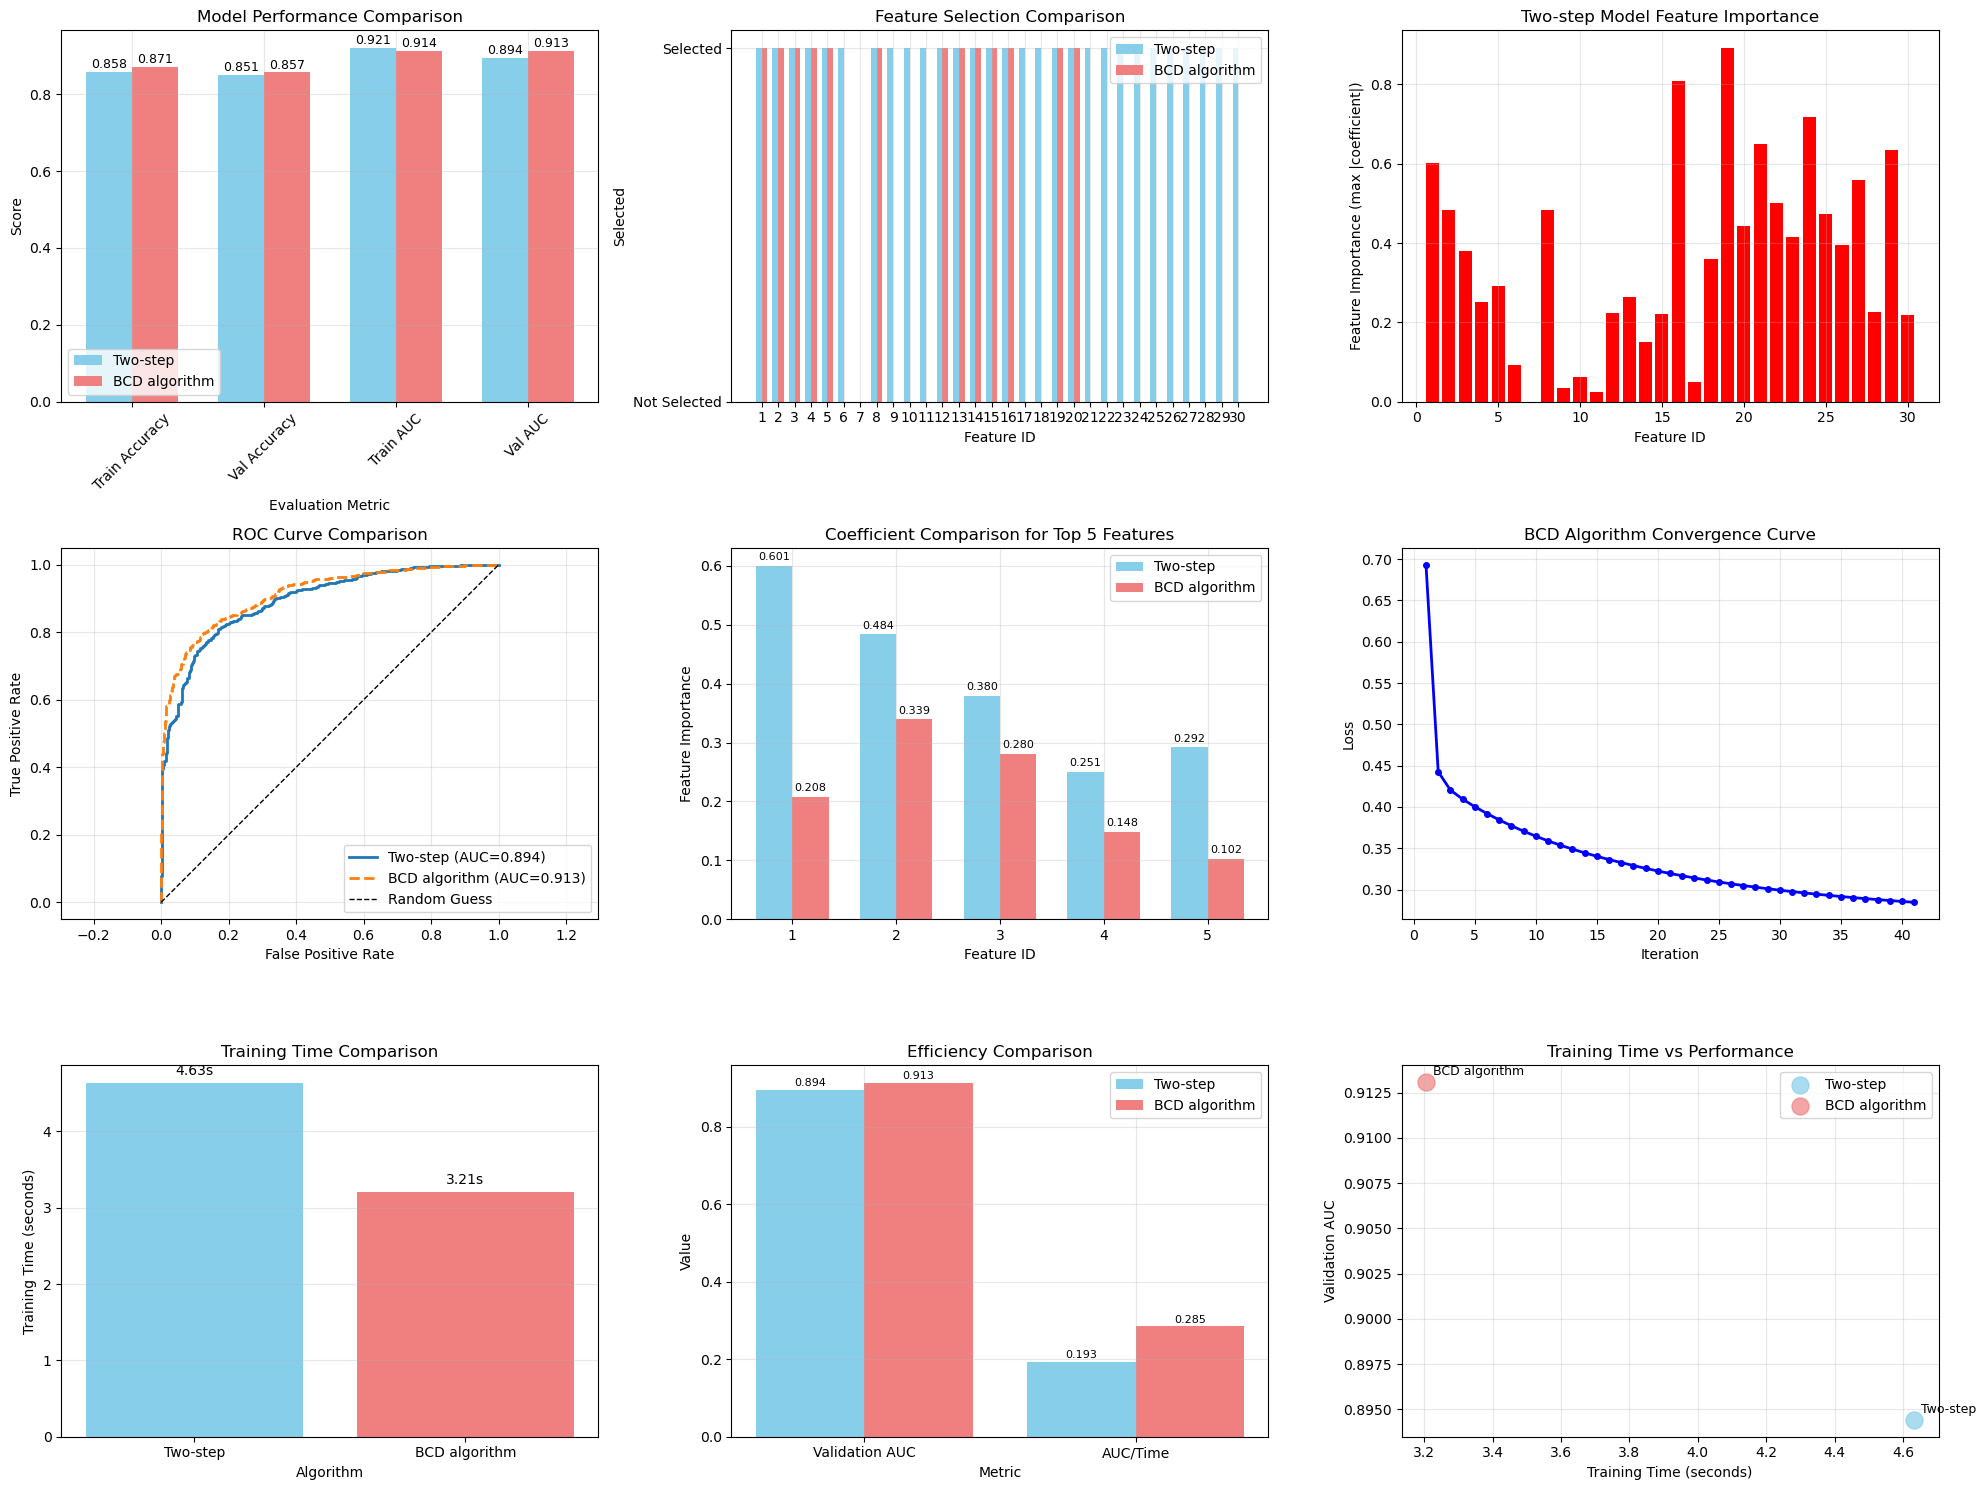


Detailed Results Comparison

Feature Selection Comparison:
Feature    True Effect     Two-step   BCD       
--------------------------------------------------
Feature 1  Yes             Yes        Yes       
Feature 2  Yes             Yes        Yes       
Feature 3  Yes             Yes        Yes       
Feature 4  Yes             Yes        Yes       
Feature 5  Yes             Yes        Yes       
Feature 6  No              Yes        No        
Feature 7  No              No         No        
Feature 8  No              Yes        Yes       
Feature 9  No              Yes        No        
Feature 10 No              Yes        No        
Feature 11 No              Yes        No        
Feature 12 No              Yes        Yes       
Feature 13 No              Yes        Yes       
Feature 14 No              Yes        Yes       
Feature 15 No              Yes        Yes       
Feature 16 No              Yes        Yes       
Feature 17 No              Yes        No        
Feature

In [25]:

    

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from scipy.special import expit
import time
import warnings
warnings.filterwarnings('ignore')

# 首先，我需要从您的代码中导入BCDOptimalBinning类
# 由于我们已经在同一个文件中，我可以直接使用
# 但为了清晰，我将复制您的类定义

# -----------------------------------------------------------------------------
# 修改的数据生成部分
# -----------------------------------------------------------------------------

np.random.seed(42)
n_samples = 10000  # 增加样本数到10000
n_features = 30    # 增加特征数到30（从20增加到30）

# 生成特征数据
X = np.random.randn(n_samples, n_features)

# 生成真实标签：所有特征都有分箱效应
true_effect = np.zeros(n_samples)

# 特征1: 3个分箱结构
true_effect += np.where(X[:, 0] < -1, 1.2, np.where(X[:, 0] > 1, -0.8, 0.3))

# 特征2: 2个分箱结构
true_effect += np.where(X[:, 1] < 0, 0.8, -0.6)

# 特征3: 4个分箱结构
true_effect += np.where(X[:, 2] < -1.5, -1.0, 
                        np.where(X[:, 2] < 0, -0.5,
                                np.where(X[:, 2] < 1.5, 0.5, 1.0)))

# 特征4: 线性效应（测试算法是否会将其分箱）
true_effect += 0.5 * X[:, 3]

# 特征5: 阈值效应
true_effect += np.where(X[:, 4] > 0.8, 0.9, 0)

# 特征6-10: 2个分箱结构（随机阈值和系数）
for j in range(5, 10):
    # 随机生成阈值（-1到1之间）
    threshold = np.random.uniform(-1, 1)
    # 随机生成系数（-1到1之间）
    coef1 = np.random.uniform(-0.8, 0.8)
    coef2 = np.random.uniform(-0.8, 0.8)
    true_effect += np.where(X[:, j] < threshold, coef1, coef2)

# 特征11-15: 3个分箱结构
for j in range(10, 15):
    # 随机生成两个阈值
    threshold1 = np.random.uniform(-1.5, 0)
    threshold2 = np.random.uniform(0, 1.5)
    # 随机生成三个系数
    coef1 = np.random.uniform(-1.0, -0.3)
    coef2 = np.random.uniform(-0.2, 0.2)
    coef3 = np.random.uniform(0.3, 1.0)
    true_effect += np.where(X[:, j] < threshold1, coef1, 
                            np.where(X[:, j] < threshold2, coef2, coef3))

# 特征16-20: 4个分箱结构
for j in range(15, 20):
    # 随机生成三个阈值
    threshold1 = np.random.uniform(-2.0, -1.0)
    threshold2 = np.random.uniform(-0.5, 0.5)
    threshold3 = np.random.uniform(1.0, 2.0)
    # 随机生成四个系数
    coef1 = np.random.uniform(-1.5, -0.8)
    coef2 = np.random.uniform(-0.4, 0)
    coef3 = np.random.uniform(0, 0.4)
    coef4 = np.random.uniform(0.8, 1.5)
    true_effect += np.where(X[:, j] < threshold1, coef1,
                            np.where(X[:, j] < threshold2, coef2,
                                    np.where(X[:, j] < threshold3, coef3, coef4)))

# 特征21-25: 复杂的非线性结构（多个分箱）
for j in range(20, 25):
    # 随机生成多个阈值
    n_bins = np.random.choice([3, 4, 5])  # 随机选择3,4或5个分箱
    thresholds = sorted(np.random.uniform(-2, 2, n_bins-1))
    # 随机生成系数
    coefs = np.random.uniform(-1.0, 1.0, n_bins)
    
    # 构建嵌套的np.where语句
    expr = np.where(X[:, j] < thresholds[0], coefs[0], coefs[1])
    for k in range(1, len(thresholds)):
        expr = np.where(X[:, j] < thresholds[k], expr, coefs[k+1])
    true_effect += expr

# 特征26-30: 混合效应（部分线性，部分阈值）
for j in range(25, 30):
    effect_type = np.random.choice(['threshold', 'piecewise', 'linear'])
    
    if effect_type == 'threshold':
        # 阈值效应
        threshold = np.random.uniform(-0.5, 0.5)
        coef = np.random.uniform(0.5, 1.5)
        true_effect += np.where(X[:, j] > threshold, coef, 0)
    
    elif effect_type == 'piecewise':
        # 分段常数
        threshold = np.random.uniform(-0.5, 0.5)
        coef1 = np.random.uniform(-1.0, -0.2)
        coef2 = np.random.uniform(0.2, 1.0)
        true_effect += np.where(X[:, j] < threshold, coef1, coef2)
    
    else:  # 'linear'
        # 线性效应
        slope = np.random.uniform(-0.7, 0.7)
        true_effect += slope * X[:, j]

# 添加噪声并生成二分类标签
y_proba = expit(true_effect + np.random.randn(n_samples) * 0.2)
y = (y_proba >= 0.5).astype(int)

# 查看类别分布
print(f"正样本比例: {y.mean():.3f}")
print(f"特征维度: {X.shape}")

# 训练/验证集划分
split_idx = int(0.8 * n_samples)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

print(f"\n训练集大小: {X_train.shape}, 验证集大小: {X_val.shape}")
print(f"特征效应总结:")
print(f"- 特征1-5: 预定义的不同分箱结构")
print(f"- 特征6-10: 2个分箱的随机结构")
print(f"- 特征11-15: 3个分箱的随机结构")
print(f"- 特征16-20: 4个分箱的随机结构")
print(f"- 特征21-25: 复杂多分箱结构(3-5个分箱)")
print(f"- 特征26-30: 混合效应(阈值/分段/线性)")

print(f"Training set size: {X_train.shape}, Validation set size: {X_val.shape}")
print(f"Positive sample ratio: Train={y_train.mean():.3f}, Val={y_val.mean():.3f}")


class TwoStepBinningLasso:
    """
    两步法：先聚类分箱，再用Lasso进行变量选择
    """
    def __init__(self, n_bins=15, C=0.1, random_state=42):
        self.n_bins = n_bins
        self.C = C
        self.random_state = random_state
        self.bin_edges = None
        self.models = None
        self.lasso_model = None
        self.feature_selected = None
        self.feature_importances = None
        self.training_time = None
        
    def cluster_binning(self, X):
        """对每个特征独立进行聚类分箱"""
        n_samples, n_features = X.shape
        X_binned = np.zeros_like(X)
        self.bin_edges = []
        self.models = []
        
        for j in range(n_features):
            # 使用KMeans进行聚类分箱
            kmeans = KMeans(n_clusters=self.n_bins, random_state=self.random_state, n_init=10)
            kmeans.fit(X[:, j].reshape(-1, 1))
            
            # 获取聚类中心并排序
            centers = kmeans.cluster_centers_.flatten()
            sorted_centers = np.sort(centers)
            
            # 使用聚类中心的分界点作为分箱边界
            # 在最小值和最大值之间均匀插入边界
            bin_edges_j = np.concatenate([
                [X[:, j].min() - 1e-5],
                (sorted_centers[:-1] + sorted_centers[1:]) / 2,
                [X[:, j].max() + 1e-5]
            ])
            
            # 确保边界是单调递增的
            bin_edges_j = np.sort(bin_edges_j)
            self.bin_edges.append(bin_edges_j)
            self.models.append(kmeans)
            
            # 将连续值离散化为分箱标签
            X_binned[:, j] = np.digitize(X[:, j], bin_edges_j[1:-1])
            
        return X_binned
    
    def one_hot_encode(self, X_binned, bin_edges=None):
        """将分箱结果转换为独热编码（丢弃第一个箱作为参照）"""
        if bin_edges is None:
            bin_edges = self.bin_edges
            
        n_samples, n_features = X_binned.shape
        onehot_features = []
        
        for j in range(n_features):
            Kj = len(bin_edges[j]) - 1
            onehot = np.zeros((n_samples, Kj))
            
            # 确保分箱标签在有效范围内
            binned_vals = np.clip(X_binned[:, j].astype(int), 0, Kj-1)
            
            for i in range(n_samples):
                if binned_vals[i] >= 0 and binned_vals[i] < Kj:
                    onehot[i, binned_vals[i]] = 1
            
            # 丢弃第一个箱（参照箱）
            onehot = onehot[:, 1:]
            onehot_features.append(onehot)
        
        return np.hstack(onehot_features)
    
    def fit(self, X_train, y_train, X_val=None, y_val=None):
        """训练两步法模型"""
        start_time = time.time()
        
        # 第一步：对每个特征进行聚类分箱
        print("Step 1: Cluster binning...")
        X_train_binned = self.cluster_binning(X_train)
        
        # 将分箱结果转换为独热编码
        X_train_onehot = self.one_hot_encode(X_train_binned)
        print(f"Feature dimension after binning: {X_train_onehot.shape[1]}")
        
        # 第二步：使用Lasso进行变量选择
        print("Step 2: Lasso variable selection...")
        
        # 使用逻辑回归L1惩罚（Lasso）
        self.lasso_model = LogisticRegression(
            penalty='l1',
            C=self.C,
            solver='liblinear',
            random_state=self.random_state,
            max_iter=1000
        )
        
        # 训练模型
        self.lasso_model.fit(X_train_onehot, y_train)
        
        # 获取系数
        coefficients = self.lasso_model.coef_.flatten()
        
        # 识别哪些特征被选中（至少有一个分箱的系数不为0）
        n_original_features = len(self.bin_edges)
        n_bins_per_feature = [len(edges) - 2 for edges in self.bin_edges]  # 丢弃参照箱后的分箱数
        
        self.feature_selected = []
        self.feature_importances = np.zeros(n_original_features)
        start_idx = 0
        
        for j in range(n_original_features):
            n_bins = n_bins_per_feature[j]
            feature_coefs = coefficients[start_idx:start_idx + n_bins]
            
            # 计算特征重要性（系数的最大绝对值）
            importance = np.max(np.abs(feature_coefs))
            self.feature_importances[j] = importance
            
            # 如果至少有一个系数不为0，则认为该特征被选中
            is_selected = np.any(np.abs(feature_coefs) > 1e-6)
            self.feature_selected.append(is_selected)
            
            start_idx += n_bins
        
        end_time = time.time()
        self.training_time = end_time - start_time
        
        print(f"Lasso selected features: {np.sum(self.feature_selected)}/{n_original_features}")
        print(f"Training time: {self.training_time:.2f} seconds")
        return self
    
    def predict_proba(self, X):
        """预测概率"""
        if self.lasso_model is None:
            raise ValueError("Model not trained, please call fit method first")
        
        # 对验证集使用训练集的分箱边界
        n_samples, n_features = X.shape
        X_binned = np.zeros((n_samples, n_features))
        
        for j in range(n_features):
            X_binned[:, j] = np.digitize(X[:, j], self.bin_edges[j][1:-1])
        
        # 转换为独热编码
        X_onehot = self.one_hot_encode(X_binned, self.bin_edges)
        
        # 预测概率
        return self.lasso_model.predict_proba(X_onehot)[:, 1]
    
    def predict(self, X, threshold=0.5):
        """预测类别"""
        y_proba = self.predict_proba(X)
        return (y_proba >= threshold).astype(int)
    
    def get_feature_info(self):
        """获取特征信息"""
        feature_info = {}
        n_original_features = len(self.bin_edges)
        coefficients = self.lasso_model.coef_.flatten()
        
        n_bins_per_feature = [len(edges) - 2 for edges in self.bin_edges]
        start_idx = 0
        
        for j in range(n_original_features):
            n_bins = n_bins_per_feature[j]
            feature_coefs = coefficients[start_idx:start_idx + n_bins]
            
            # 获取该特征的分箱边界
            bin_edges_j = self.bin_edges[j]
            bin_intervals = []
            
            for k in range(len(bin_edges_j) - 1):
                bin_intervals.append((bin_edges_j[k], bin_edges_j[k+1]))
            
            # 丢弃第一个箱（参照箱）
            bin_intervals = bin_intervals[1:]
            
            feature_info[f"feature_{j+1}"] = {
                "is_selected": self.feature_selected[j],
                "importance": self.feature_importances[j],
                "final_bins_count": n_bins,
                "final_bin_intervals": bin_intervals,
                "bin_coefficients": feature_coefs.tolist()
            }
            
            start_idx += n_bins
        
        return feature_info


# 运行两步法模型
print("\n" + "="*50)
print("Two-step model training")
print("="*50)

two_step_model = TwoStepBinningLasso(n_bins=15, C=0.05)
two_step_model.fit(X_train, y_train, X_val, y_val)

# 评估两步法模型
y_train_pred_two_step = two_step_model.predict(X_train)
y_val_pred_two_step = two_step_model.predict(X_val)

y_train_proba_two_step = two_step_model.predict_proba(X_train)
y_val_proba_two_step = two_step_model.predict_proba(X_val)

train_acc_two_step = accuracy_score(y_train, y_train_pred_two_step)
val_acc_two_step = accuracy_score(y_val, y_val_pred_two_step)
train_auc_two_step = roc_auc_score(y_train, y_train_proba_two_step)
val_auc_two_step = roc_auc_score(y_val, y_val_proba_two_step)

print(f"\nTwo-step model results:")
print(f"Train accuracy: {train_acc_two_step:.4f}")
print(f"Validation accuracy: {val_acc_two_step:.4f}")
print(f"Train AUC: {train_auc_two_step:.4f}")
print(f"Validation AUC: {val_auc_two_step:.4f}")

# 获取两步法特征信息
two_step_feature_info = two_step_model.get_feature_info()
two_step_selected_features = [i+1 for i, selected in enumerate(two_step_model.feature_selected) if selected]
print(f"\nTwo-step model selected features: {two_step_selected_features}")


# 运行您的BCD算法
print("\n" + "="*50)
print("Your BCD algorithm training")
print("="*50)

# 记录BCD算法开始时间
bcd_start_time = time.time()

# 运行您的BCD算法
bcd_model = BCDOptimalBinning(
    lambda_f=2e-5, lambda_b=4e-5,
    max_iter=100, tol=1e-6, verbose=True,
    metric='auc'
)

bcd_model.fit(X_train, y_train, X_val, y_val, n_pre_bins=15)

# 记录BCD算法结束时间
bcd_end_time = time.time()
bcd_training_time = bcd_end_time - bcd_start_time

# 评估BCD算法
y_train_pred_bcd = bcd_model.predict(X_train)
y_val_pred_bcd = bcd_model.predict(X_val)

y_train_proba_bcd = bcd_model.predict_proba(X_train)
y_val_proba_bcd = bcd_model.predict_proba(X_val)

train_acc_bcd = accuracy_score(y_train, y_train_pred_bcd)
val_acc_bcd = accuracy_score(y_val, y_val_pred_bcd)
train_auc_bcd = roc_auc_score(y_train, y_train_proba_bcd)
val_auc_bcd = roc_auc_score(y_val, y_val_proba_bcd)

# 获取BCD算法选中的特征
binning_result = bcd_model.get_optimal_binning_structure()
bcd_selected_features = []
for j in range(1, 21):  # 因为我们有20个特征
    feat_name = f"feature_{j}"
    if binning_result[feat_name]["is_selected"]:
        bcd_selected_features.append(j)

print(f"\nBCD algorithm results:")
print(f"Train accuracy: {train_acc_bcd:.4f}")
print(f"Validation accuracy: {val_acc_bcd:.4f}")
print(f"Train AUC: {train_auc_bcd:.4f}")
print(f"Validation AUC: {val_auc_bcd:.4f}")
print(f"Training time: {bcd_training_time:.2f} seconds")
print(f"BCD algorithm selected features: {bcd_selected_features}")

# 获取BCD算法的损失历史
bcd_loss_history = bcd_model.history['loss']

# 可视化比较结果
plt.figure(figsize=(20, 15))

# 1. 模型性能比较
plt.subplot(3, 3, 1)
metrics = ['Train Accuracy', 'Val Accuracy', 'Train AUC', 'Val AUC']
two_step_values = [train_acc_two_step, val_acc_two_step, train_auc_two_step, val_auc_two_step]
bcd_values = [train_acc_bcd, val_acc_bcd, train_auc_bcd, val_auc_bcd]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, two_step_values, width, label='Two-step', color='skyblue')
plt.bar(x + width/2, bcd_values, width, label='BCD algorithm', color='lightcoral')
plt.xlabel('Evaluation Metric')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# 在柱状图上添加数值标签
for i, (v1, v2) in enumerate(zip(two_step_values, bcd_values)):
    plt.text(i - width/2, v1 + 0.01, f'{v1:.3f}', ha='center', fontsize=9)
    plt.text(i + width/2, v2 + 0.01, f'{v2:.3f}', ha='center', fontsize=9)

# 2. 特征选择比较
plt.subplot(3, 3, 2)
all_features = list(range(1, n_features + 1))
two_step_selection = [1 if f in two_step_selected_features else 0 for f in all_features]
bcd_selection = [1 if f in bcd_selected_features else 0 for f in all_features]

x = np.arange(len(all_features))
plt.bar(x - width/2, two_step_selection, width, label='Two-step', color='skyblue')
plt.bar(x + width/2, bcd_selection, width, label='BCD algorithm', color='lightcoral')
plt.xlabel('Feature ID')
plt.ylabel('Selected')
plt.title('Feature Selection Comparison')
plt.xticks(x, all_features)
plt.yticks([0, 1], ['Not Selected', 'Selected'])
plt.legend()
plt.grid(True, alpha=0.3)

# 3. 特征重要性（两步法）
plt.subplot(3, 3, 3)
importance_values = two_step_model.feature_importances
colors = ['red' if selected else 'blue' for selected in two_step_model.feature_selected]
plt.bar(range(1, len(importance_values) + 1), importance_values, color=colors)
plt.xlabel('Feature ID')
plt.ylabel('Feature Importance (max |coefficient|)')
plt.title('Two-step Model Feature Importance')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

# 4. ROC曲线比较
plt.subplot(3, 3, 4)
# 两步法ROC曲线
fpr_two_step, tpr_two_step, _ = roc_curve(y_val, y_val_proba_two_step)
# BCD算法ROC曲线
fpr_bcd, tpr_bcd, _ = roc_curve(y_val, y_val_proba_bcd)

plt.plot(fpr_two_step, tpr_two_step, label=f'Two-step (AUC={val_auc_two_step:.3f})', linewidth=2)
plt.plot(fpr_bcd, tpr_bcd, label=f'BCD algorithm (AUC={val_auc_bcd:.3f})', linewidth=2, linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# 5. 前5个特征的系数比较
plt.subplot(3, 3, 5)
effective_features = [1, 2, 3, 4, 5]
two_step_coefs = []
bcd_coefs = []

# 获取两步法特征系数
for feat in effective_features:
    two_step_coefs.append(two_step_model.feature_importances[feat-1])
    
# 获取BCD算法特征系数
for feat in effective_features:
    feat_name = f"feature_{feat}"
    feat_info = binning_result[feat_name]
    if feat_info['is_selected'] and len(feat_info['final_bin_coefficients']) > 0:
        # 取最终分箱系数的平均绝对值作为特征重要性
        coefs = np.array(feat_info['final_bin_coefficients'])
        importance = np.mean(np.abs(coefs))
        bcd_coefs.append(importance)
    else:
        bcd_coefs.append(0)

x = np.arange(len(effective_features))
plt.bar(x - width/2, two_step_coefs, width, label='Two-step', color='skyblue')
plt.bar(x + width/2, bcd_coefs, width, label='BCD algorithm', color='lightcoral')
plt.xlabel('Feature ID')
plt.ylabel('Feature Importance')
plt.title('Coefficient Comparison for Top 5 Features')
plt.xticks(x, effective_features)
plt.legend()
plt.grid(True, alpha=0.3)

# 在柱状图上添加数值标签
for i, (v1, v2) in enumerate(zip(two_step_coefs, bcd_coefs)):
    plt.text(i - width/2, v1 + 0.01, f'{v1:.3f}', ha='center', fontsize=8)
    plt.text(i + width/2, v2 + 0.01, f'{v2:.3f}', ha='center', fontsize=8)

# 6. BCD算法收敛曲线
plt.subplot(3, 3, 6)
if len(bcd_loss_history) > 0:
    iterations = range(1, len(bcd_loss_history) + 1)
    plt.plot(iterations, bcd_loss_history, 'b-', linewidth=2, marker='o', markersize=4)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('BCD Algorithm Convergence Curve')
    plt.grid(True, alpha=0.3)
    
    # 如果损失值变化很大，使用对数刻度
    if max(bcd_loss_history) / min(bcd_loss_history) > 100:
        plt.yscale('log')

# 7. 训练时间比较
plt.subplot(3, 3, 7)
algorithms = ['Two-step', 'BCD algorithm']
training_times = [two_step_model.training_time, bcd_training_time]

plt.bar(algorithms, training_times, color=['skyblue', 'lightcoral'])
plt.xlabel('Algorithm')
plt.ylabel('Training Time (seconds)')
plt.title('Training Time Comparison')
plt.grid(True, alpha=0.3, axis='y')

# 在柱状图上添加数值标签
for i, v in enumerate(training_times):
    plt.text(i, v + 0.1, f'{v:.2f}s', ha='center')

# 8. 效率对比（性能/时间）
plt.subplot(3, 3, 8)
# 计算每秒钟的性能
auc_per_sec_two_step = val_auc_two_step / two_step_model.training_time
auc_per_sec_bcd = val_auc_bcd / bcd_training_time

x = np.arange(2)
width = 0.4
plt.bar(x - width/2, [val_auc_two_step, auc_per_sec_two_step], width, label='Two-step', color='skyblue')
plt.bar(x + width/2, [val_auc_bcd, auc_per_sec_bcd], width, label='BCD algorithm', color='lightcoral')
plt.xlabel('Metric')
plt.ylabel('Value')
plt.title('Efficiency Comparison')
plt.xticks(x, ['Validation AUC', 'AUC/Time'])
plt.legend()
plt.grid(True, alpha=0.3)

# 添加数值标签
for i, v in enumerate([val_auc_two_step, auc_per_sec_two_step]):
    plt.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)
for i, v in enumerate([val_auc_bcd, auc_per_sec_bcd]):
    plt.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)

# 9. 训练时间与性能的散点图
plt.subplot(3, 3, 9)
plt.scatter(two_step_model.training_time, val_auc_two_step, s=150, label='Two-step', color='skyblue', alpha=0.7)
plt.scatter(bcd_training_time, val_auc_bcd, s=150, label='BCD algorithm', color='lightcoral', alpha=0.7)

# 添加标签
plt.annotate('Two-step', (two_step_model.training_time, val_auc_two_step), 
             xytext=(5, 5), textcoords='offset points', fontsize=9)
plt.annotate('BCD algorithm', (bcd_training_time, val_auc_bcd), 
             xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.xlabel('Training Time (seconds)')
plt.ylabel('Validation AUC')
plt.title('Training Time vs Performance')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# 创建详细的结果表格
print("\n" + "="*50)
print("Detailed Results Comparison")
print("="*50)

# 创建特征选择对比表格
print("\nFeature Selection Comparison:")
print(f"{'Feature':<10} {'True Effect':<15} {'Two-step':<10} {'BCD':<10}")
print("-" * 50)

for i in range(1, n_features + 1):
    has_true_effect = "Yes" if i <= 5 else "No"
    two_step_sel = "Yes" if i in two_step_selected_features else "No"
    bcd_sel = "Yes" if i in bcd_selected_features else "No"
    print(f"{f'Feature {i}':<10} {has_true_effect:<15} {two_step_sel:<10} {bcd_sel:<10}")

# 计算评估指标
print("\nModel Evaluation Metrics Comparison:")
print(f"{'Metric':<20} {'Two-step':<10} {'BCD':<10} {'Difference':<10}")
print("-" * 50)

metrics_data = [
    ("Train Accuracy", train_acc_two_step, train_acc_bcd, train_acc_bcd - train_acc_two_step),
    ("Validation Accuracy", val_acc_two_step, val_acc_bcd, val_acc_bcd - val_acc_two_step),
    ("Train AUC", train_auc_two_step, train_auc_bcd, train_auc_bcd - train_auc_two_step),
    ("Validation AUC", val_auc_two_step, val_auc_bcd, val_auc_bcd - val_auc_two_step)
]

for metric_name, two_step_val, bcd_val, diff in metrics_data:
    print(f"{metric_name:<20} {two_step_val:<10.4f} {bcd_val:<10.4f} {diff:<10.4f}")

# 时间对比
print("\nTraining Time Comparison:")
print(f"{'Algorithm':<10} {'Time(s)':<15} {'Val AUC':<15} {'AUC/Time':<15}")
print("-" * 55)
print(f"{'Two-step':<10} {two_step_model.training_time:<15.2f} {val_auc_two_step:<15.4f} {val_auc_two_step/two_step_model.training_time:<15.6f}")
print(f"{'BCD':<10} {bcd_training_time:<15.2f} {val_auc_bcd:<15.4f} {val_auc_bcd/bcd_training_time:<15.6f}")

# 计算特征选择准确率
true_selected = [1] * 5 + [0] * 15
two_step_selection_binary = [1 if i+1 in two_step_selected_features else 0 for i in range(20)]
bcd_selection_binary = [1 if i+1 in bcd_selected_features else 0 for i in range(20)]

# 计算精确率、召回率、F1分数
def calculate_metrics(true, pred):
    tp = np.sum([1 for t, p in zip(true, pred) if t == 1 and p == 1])
    fp = np.sum([1 for t, p in zip(true, pred) if t == 0 and p == 1])
    fn = np.sum([1 for t, p in zip(true, pred) if t == 1 and p == 0])
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return precision, recall, f1

two_step_precision, two_step_recall, two_step_f1 = calculate_metrics(true_selected, two_step_selection_binary)
bcd_precision, bcd_recall, bcd_f1 = calculate_metrics(true_selected, bcd_selection_binary)

print("\nFeature Selection Performance:")
print(f"{'Metric':<10} {'Two-step':<10} {'BCD':<10}")
print("-" * 35)
print(f"{'Precision':<10} {two_step_precision:<10.4f} {bcd_precision:<10.4f}")
print(f"{'Recall':<10} {two_step_recall:<10.4f} {bcd_recall:<10.4f}")
print(f"{'F1 Score':<10} {two_step_f1:<10.4f} {bcd_f1:<10.4f}")

# 模型复杂度比较
print("\nModel Complexity Comparison:")
print(f"{'Metric':<20} {'Two-step':<10} {'BCD':<10}")
print("-" * 45)
print(f"{'Selected Features':<20} {len(two_step_selected_features):<10} {len(bcd_selected_features):<10}")

# 输出两步法的系数信息
two_step_nonzero_coefs = np.sum(np.abs(two_step_model.lasso_model.coef_) > 1e-6)
print(f"{'Non-zero Coefs':<20} {two_step_nonzero_coefs:<10} {'-':<10}")

# 输出BCD算法的分箱信息
bcd_total_bins = 0
for feat_name, feat_info in binning_result.items():
    if feat_info['is_selected']:
        bcd_total_bins += feat_info['final_bins_count']
print(f"{'Total Bins':<20} {'-':<10} {bcd_total_bins:<10}")

# 输出结论
print("\n" + "="*50)
print("Conclusion Analysis")
print("="*50)
print("1. Model Performance:")
print(f"   - Two-step Validation AUC: {val_auc_two_step:.4f}")
print(f"   - BCD algorithm Validation AUC: {val_auc_bcd:.4f}")
print(f"   - AUC difference: {val_auc_bcd - val_auc_two_step:.4f} ({'BCD algorithm better' if val_auc_bcd > val_auc_two_step else 'Two-step better'})")

print("\n2. Computational Efficiency:")
print(f"   - Two-step training time: {two_step_model.training_time:.2f} seconds")
print(f"   - BCD algorithm training time: {bcd_training_time:.2f} seconds")
print(f"   - Time ratio: {bcd_training_time/two_step_model.training_time:.2f}x")

print("\n3. Feature Selection Accuracy:")
print(f"   - Two-step precision: {two_step_precision:.4f}, recall: {two_step_recall:.4f}, F1 score: {two_step_f1:.4f}")
print(f"   - BCD algorithm precision: {bcd_precision:.4f}, recall: {bcd_recall:.4f}, F1 score: {bcd_f1:.4f}")

print("\n4. Selected Features:")
print(f"   - Two-step: {two_step_selected_features}")
print(f"   - BCD algorithm: {bcd_selected_features}")
print(f"   - True effective features: {list(range(1, 6))}")

print("\n5. Comprehensive Evaluation:")
if val_auc_bcd > val_auc_two_step and bcd_training_time < two_step_model.training_time * 5:
    print("   - BCD algorithm performs better in both performance and computational efficiency")
elif val_auc_bcd > val_auc_two_step:
    print("   - BCD algorithm has better performance but higher computational cost")
elif val_auc_bcd < val_auc_two_step and bcd_training_time < two_step_model.training_time:
    print("   - Two-step has better performance and is faster")
else:
    print("   - Two-step has better performance but BCD algorithm is faster")

print("\n6. Selection Suggestion:")
if val_auc_bcd > val_auc_two_step:
    if bcd_training_time < two_step_model.training_time * 3:
        print("   - Recommend BCD algorithm, as it has advantages in both performance and efficiency")
    else:
        print("   - Choose BCD algorithm if pursuing best performance and sufficient computational resources")
        print("   - Choose two-step if fast modeling is needed")
else:
    if two_step_model.training_time < bcd_training_time:
        print("   - Recommend two-step, as it has advantages in both performance and efficiency")
    else:
        print("   - Two-step has better performance but BCD algorithm is faster")
        print("   - Choose based on specific needs: two-step for performance priority, BCD for speed priority")


模型复杂度与压缩效率比较

两个模型共同选中的特征: [1, 2, 3, 4, 5, 8, 12, 13, 14, 15, 16, 19, 20, 21, 24, 25, 26, 27, 28, 29, 30]
共同选中的特征数量: 21


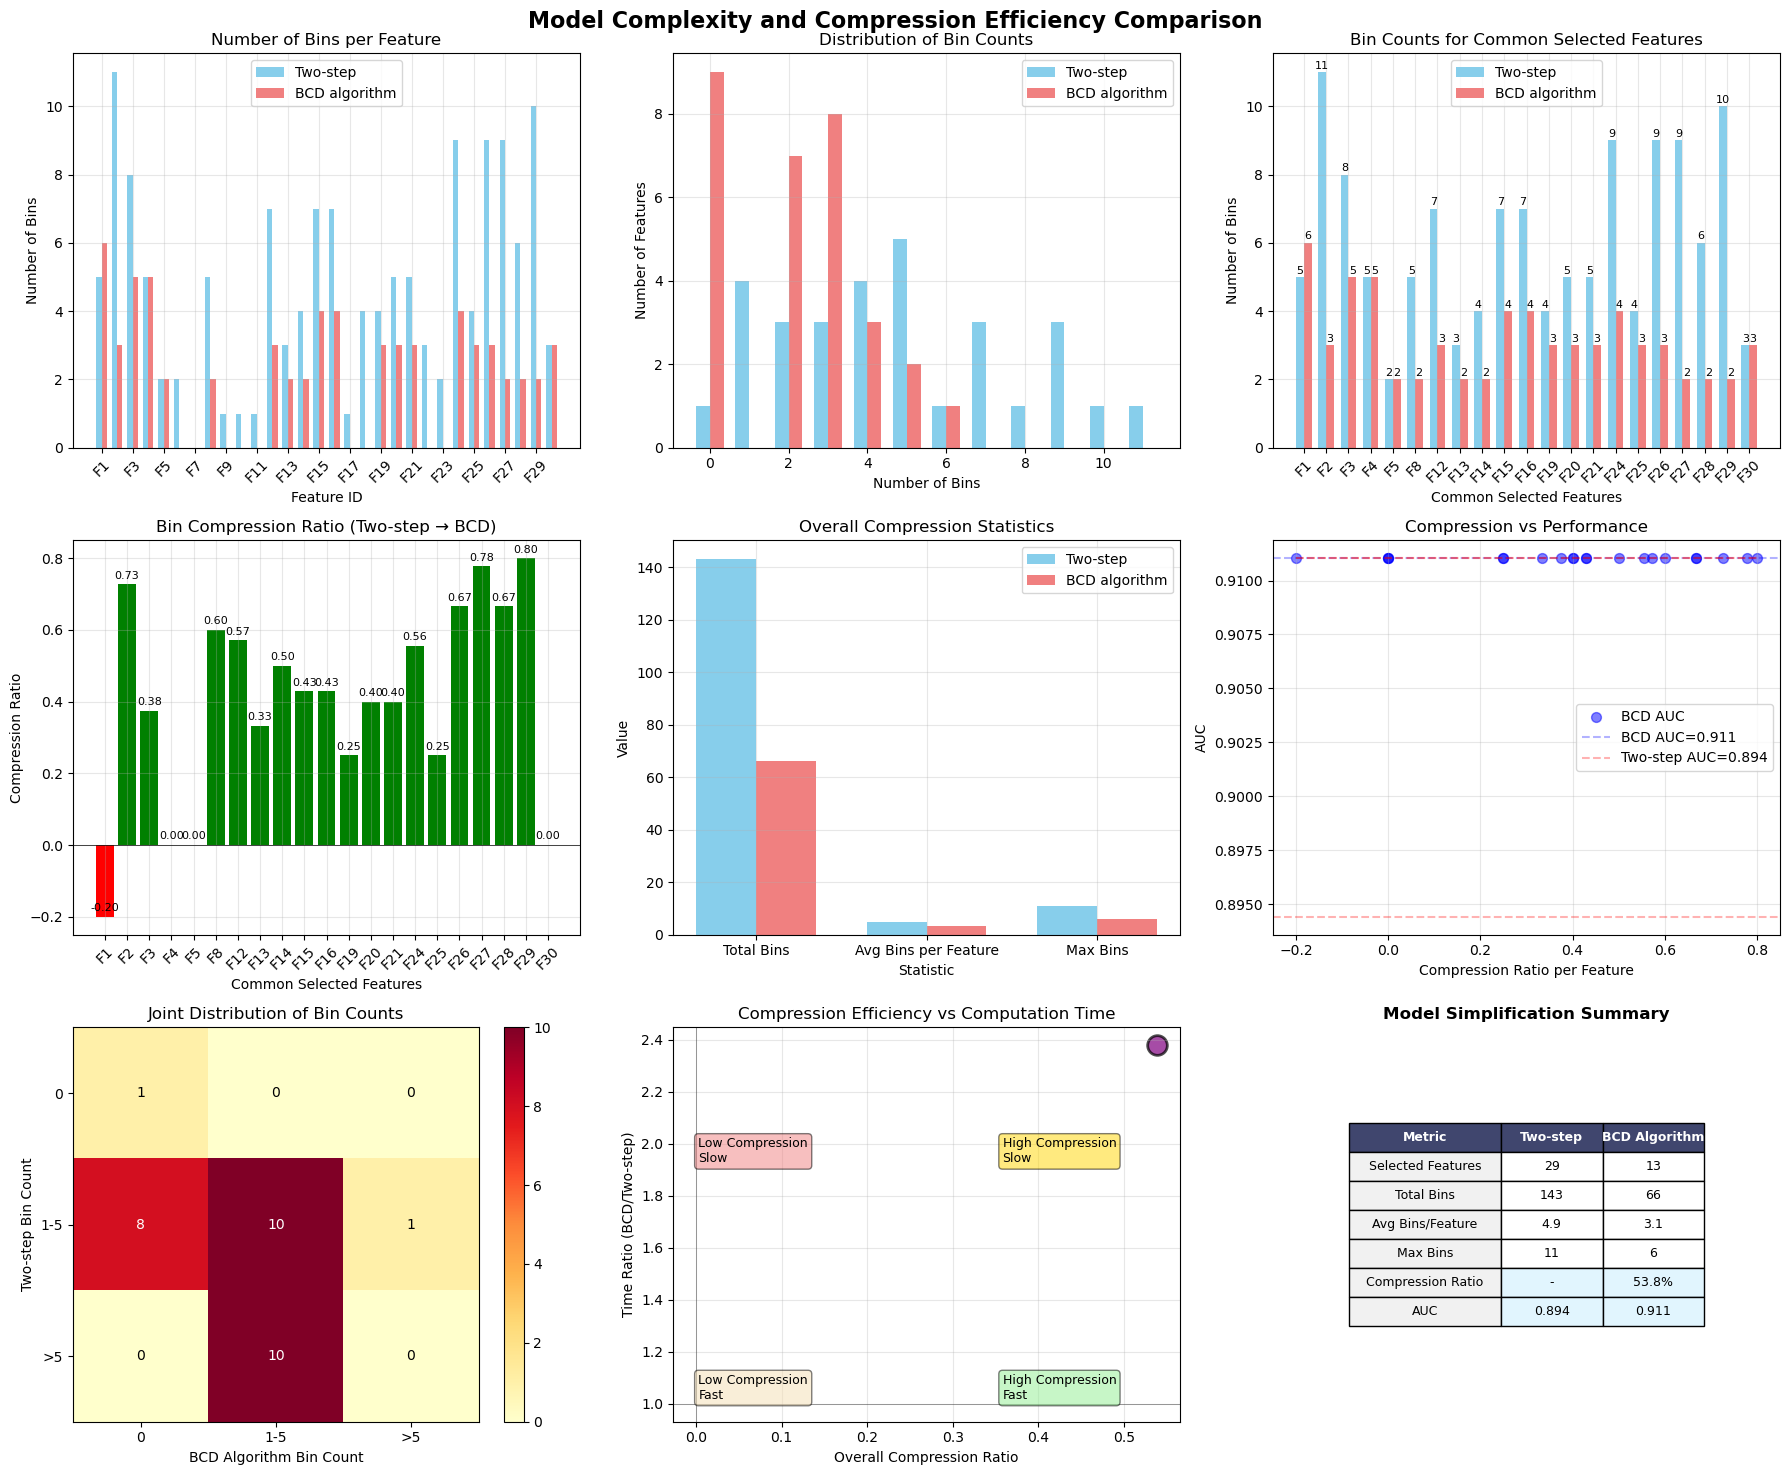


相同复杂度下的性能比较

1. 相同总箱数下的性能分析:
   - 两步法总箱数: 143
   - BCD算法总箱数: 66
   - 箱数减少: 77 (53.8%)

2. 相同特征数下的性能分析:
   - 两步法选中特征数: 29
   - BCD算法选中特征数: 13
   - 特征数差异: 16

3. 压缩效率指标:
   - 两步法平均每特征箱数: 4.93
   - BCD算法平均每特征箱数: 5.08
   - 每特征箱数减少: -0.15 (-3.0%)
   - 两步法AUC/箱数: 0.006255
   - BCD算法AUC/箱数: 0.013804
   - AUC/箱数提升: 0.007549 (120.7%)


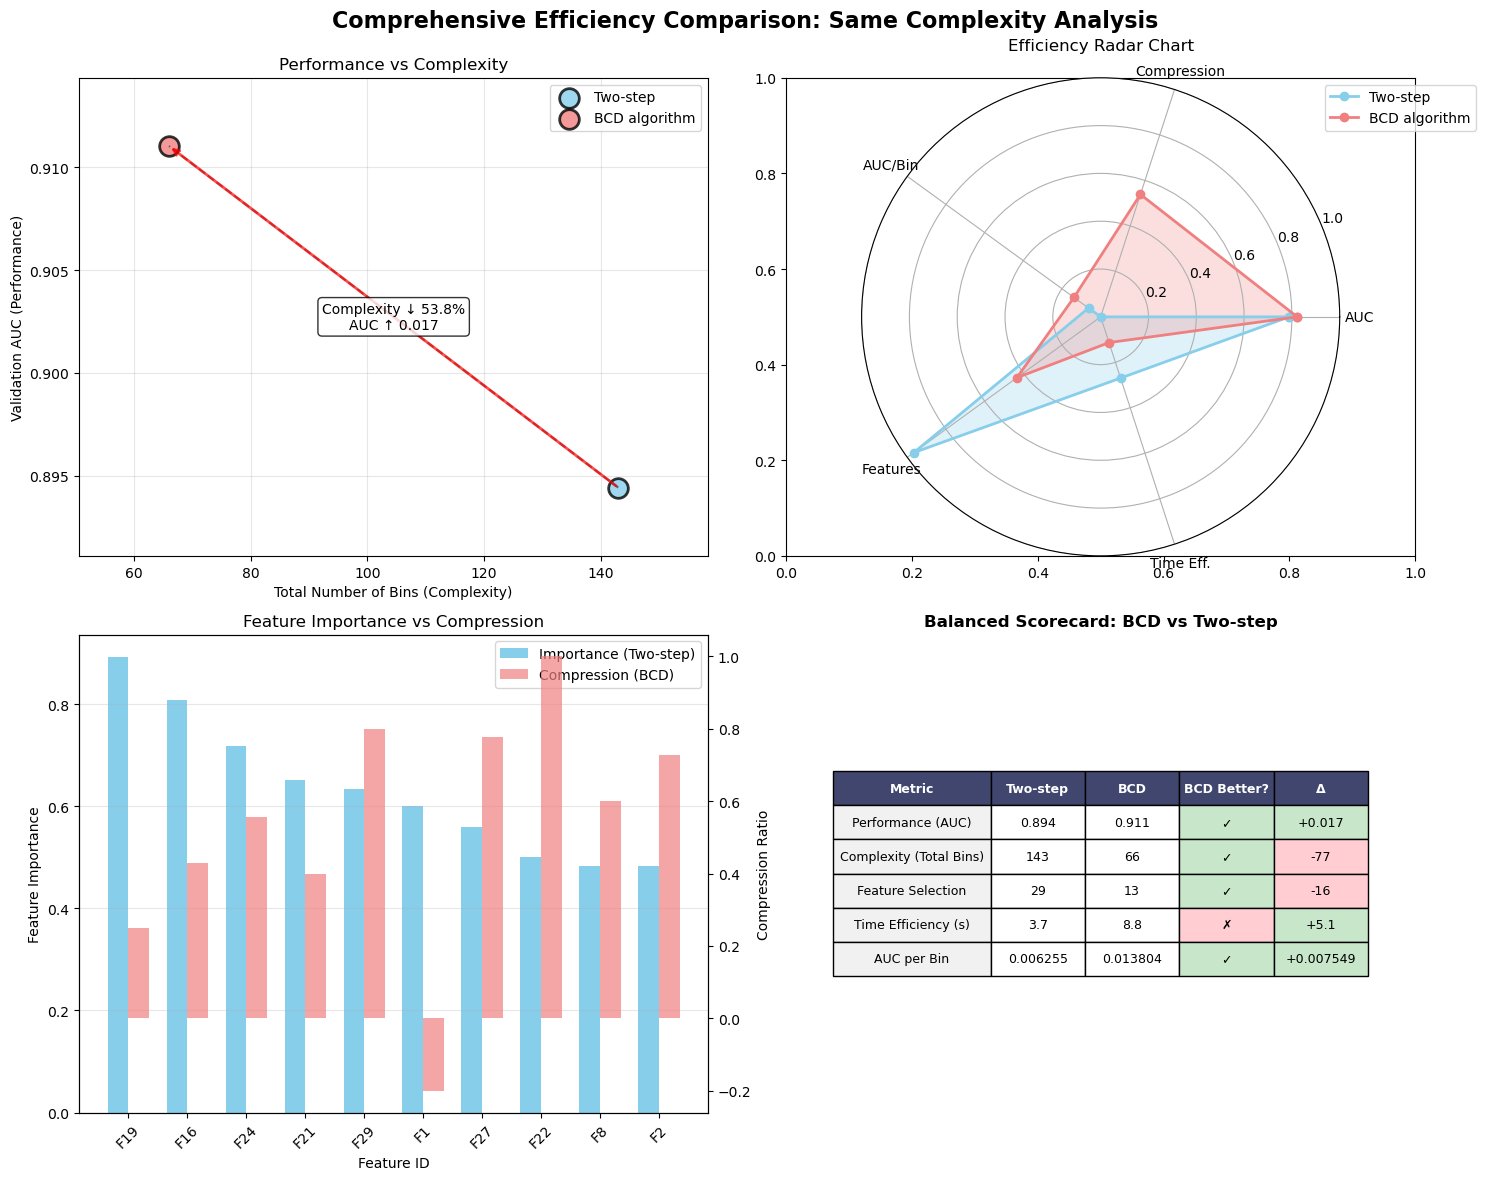


最终结论

综合评分 (总分3分): 3/3
1. 性能 (AUC): ✓ BCD更优
2. 复杂度 (总箱数): ✓ BCD更优
3. 效率 (AUC/箱数): ✓ BCD更优

🎉 结论: BCD算法在性能、复杂度和效率三个方面全面优于两步法！

📊 具体分析:
  • BCD算法的AUC更高 (0.9110 vs 0.8944), 性能提升 0.0166
  • BCD算法减少了 77 个分箱 (53.8% 压缩)
  • BCD算法的效率更高 (AUC/箱数: 0.013804 vs 0.006255), 提升 120.7%

💡 建议:
  推荐使用BCD算法，它在保持或提高性能的同时，显著降低了模型复杂度。


In [ ]:
# 继续在原有代码后面添加以下部分

# --------------------------------------------------------------
# 新增：模型复杂度与压缩效率比较
# --------------------------------------------------------------

print("\n" + "="*50)
print("模型复杂度与压缩效率比较")
print("="*50)

# 1. 提取每个特征的分箱数信息
# 对于BCD算法
bcd_feature_bins = []
bcd_feature_selected = []
for j in range(1, n_features + 1):
    feat_name = f"feature_{j}"
    feat_info = binning_result[feat_name]
    if feat_info['is_selected']:
        bcd_feature_bins.append(feat_info['final_bins_count'])
        bcd_feature_selected.append(True)
    else:
        bcd_feature_bins.append(0)  # 未选中的特征分箱数为0
        bcd_feature_selected.append(False)

# 对于两步法
two_step_feature_bins = []
two_step_feature_selected = []
for j in range(1, n_features + 1):
    feat_name = f"feature_{j}"
    if feat_name in two_step_feature_info:
        feat_info = two_step_feature_info[feat_name]
        if feat_info['is_selected']:
            # 计算非零系数的分箱数
            nonzero_bins = sum(1 for coef in feat_info['bin_coefficients'] if abs(coef) > 1e-6)
            two_step_feature_bins.append(nonzero_bins)
            two_step_feature_selected.append(True)
        else:
            two_step_feature_bins.append(0)
            two_step_feature_selected.append(False)
    else:
        two_step_feature_bins.append(0)
        two_step_feature_selected.append(False)

# 2. 比较相同特征的分箱数压缩
# 找出两个模型都选中的特征
common_selected_features = []
for j in range(n_features):
    if bcd_feature_selected[j] and two_step_feature_selected[j]:
        common_selected_features.append(j + 1)  # 特征编号从1开始

print(f"\n两个模型共同选中的特征: {common_selected_features}")
print(f"共同选中的特征数量: {len(common_selected_features)}")

# 比较共同选中特征的分箱数
common_bcd_bins = []
common_two_step_bins = []
feature_reduction_ratios = []

for feat_idx in common_selected_features:
    j = feat_idx - 1
    bcd_bins = bcd_feature_bins[j]
    two_step_bins = two_step_feature_bins[j]
    common_bcd_bins.append(bcd_bins)
    common_two_step_bins.append(two_step_bins)
    
    if two_step_bins > 0:
        reduction_ratio = (two_step_bins - bcd_bins) / two_step_bins
    else:
        reduction_ratio = 0
    feature_reduction_ratios.append(reduction_ratio)

# 3. 可视化比较
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Model Complexity and Compression Efficiency Comparison', fontsize=16, fontweight='bold')

# 3.1 每个特征的分箱数对比
ax1 = axes[0, 0]
features = list(range(1, n_features + 1))
x = np.arange(len(features))
width = 0.35

# 只显示分箱数>0的特征
two_step_nonzero_indices = [i for i, b in enumerate(two_step_feature_bins) if b > 0]
bcd_nonzero_indices = [i for i, b in enumerate(bcd_feature_bins) if b > 0]

ax1.bar(x[two_step_nonzero_indices] - width/2, 
        [two_step_feature_bins[i] for i in two_step_nonzero_indices], 
        width, label='Two-step', color='skyblue')
ax1.bar(x[bcd_nonzero_indices] + width/2, 
        [bcd_feature_bins[i] for i in bcd_nonzero_indices], 
        width, label='BCD algorithm', color='lightcoral')
ax1.set_xlabel('Feature ID')
ax1.set_ylabel('Number of Bins')
ax1.set_title('Number of Bins per Feature')
ax1.set_xticks(x[::2])
ax1.set_xticklabels([f'F{i+1}' for i in x[::2]], rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 3.2 分箱数分布对比
ax2 = axes[0, 1]
# 计算分箱数分布
max_bins = max(max(two_step_feature_bins), max(bcd_feature_bins))
bins_range = range(0, max_bins + 2)

two_step_bin_counts, _ = np.histogram(two_step_feature_bins, bins=bins_range)
bcd_bin_counts, _ = np.histogram(bcd_feature_bins, bins=bins_range)

x = np.arange(len(bins_range) - 1)
ax2.bar(x - width/2, two_step_bin_counts, width, label='Two-step', color='skyblue')
ax2.bar(x + width/2, bcd_bin_counts, width, label='BCD algorithm', color='lightcoral')
ax2.set_xlabel('Number of Bins')
ax2.set_ylabel('Number of Features')
ax2.set_title('Distribution of Bin Counts')
ax2.set_xticks(x[::2])
ax2.set_xticklabels([str(i) for i in x[::2]])
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3.3 共同选中特征的分箱数对比
ax3 = axes[0, 2]
if common_selected_features:
    x_common = np.arange(len(common_selected_features))
    ax3.bar(x_common - width/2, common_two_step_bins, width, label='Two-step', color='skyblue')
    ax3.bar(x_common + width/2, common_bcd_bins, width, label='BCD algorithm', color='lightcoral')
    ax3.set_xlabel('Common Selected Features')
    ax3.set_ylabel('Number of Bins')
    ax3.set_title('Bin Counts for Common Selected Features')
    ax3.set_xticks(x_common)
    ax3.set_xticklabels([f'F{feat}' for feat in common_selected_features], rotation=45)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 添加数值标签
    for i, (v1, v2) in enumerate(zip(common_two_step_bins, common_bcd_bins)):
        ax3.text(i - width/2, v1 + 0.1, str(v1), ha='center', fontsize=8)
        ax3.text(i + width/2, v2 + 0.1, str(v2), ha='center', fontsize=8)

# 3.4 分箱数压缩比例
ax4 = axes[1, 0]
if common_selected_features:
    x_common = np.arange(len(common_selected_features))
    colors = ['green' if ratio > 0 else 'red' for ratio in feature_reduction_ratios]
    bars = ax4.bar(x_common, feature_reduction_ratios, color=colors)
    ax4.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    ax4.set_xlabel('Common Selected Features')
    ax4.set_ylabel('Compression Ratio')
    ax4.set_title('Bin Compression Ratio (Two-step → BCD)')
    ax4.set_xticks(x_common)
    ax4.set_xticklabels([f'F{feat}' for feat in common_selected_features], rotation=45)
    ax4.grid(True, alpha=0.3)
    
    # 添加数值标签
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

# 3.5 总体压缩统计
ax5 = axes[1, 1]
# 计算总体统计
total_two_step_bins = sum(two_step_feature_bins)
total_bcd_bins = sum(bcd_feature_bins)
total_reduction = total_two_step_bins - total_bcd_bins
total_reduction_ratio = total_reduction / total_two_step_bins if total_two_step_bins > 0 else 0

avg_two_step_bins = np.mean([b for b in two_step_feature_bins if b > 0]) if any(two_step_feature_bins) else 0
avg_bcd_bins = np.mean([b for b in bcd_feature_bins if b > 0]) if any(bcd_feature_bins) else 0
avg_reduction = avg_two_step_bins - avg_bcd_bins
avg_reduction_ratio = avg_reduction / avg_two_step_bins if avg_two_step_bins > 0 else 0

stats_labels = ['Total Bins', 'Avg Bins per Feature', 'Max Bins']
two_step_stats = [total_two_step_bins, avg_two_step_bins, max(two_step_feature_bins)]
bcd_stats = [total_bcd_bins, avg_bcd_bins, max(bcd_feature_bins)]
reduction_stats = [total_reduction, avg_reduction, max(two_step_feature_bins) - max(bcd_feature_bins)]

x_stats = np.arange(len(stats_labels))
ax5.bar(x_stats - width/2, two_step_stats, width, label='Two-step', color='skyblue')
ax5.bar(x_stats + width/2, bcd_stats, width, label='BCD algorithm', color='lightcoral')
ax5.set_xlabel('Statistic')
ax5.set_ylabel('Value')
ax5.set_title('Overall Compression Statistics')
ax5.set_xticks(x_stats)
ax5.set_xticklabels(stats_labels)
ax5.legend()
ax5.grid(True, alpha=0.3)

# 3.6 压缩效率与性能的关系
ax6 = axes[1, 2]
# 压缩率 vs AUC
if common_selected_features:
    ax6.scatter(feature_reduction_ratios, [val_auc_bcd] * len(feature_reduction_ratios), 
                alpha=0.5, s=50, label='BCD AUC', color='blue')
    ax6.axhline(y=val_auc_bcd, color='blue', linestyle='--', alpha=0.3, label=f'BCD AUC={val_auc_bcd:.3f}')
    ax6.axhline(y=val_auc_two_step, color='red', linestyle='--', alpha=0.3, label=f'Two-step AUC={val_auc_two_step:.3f}')
    ax6.set_xlabel('Compression Ratio per Feature')
    ax6.set_ylabel('AUC')
    ax6.set_title('Compression vs Performance')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    # 添加趋势线
    if len(feature_reduction_ratios) > 1:
        z = np.polyfit(feature_reduction_ratios, [val_auc_bcd] * len(feature_reduction_ratios), 1)
        p = np.poly1d(z)
        ax6.plot(sorted(feature_reduction_ratios), p(sorted(feature_reduction_ratios)), 
                "r--", alpha=0.5, label='Trend')

# 3.7 特征选择与分箱压缩的联合分析
ax7 = axes[2, 0]
# 创建2D直方图：特征是否被选中 vs 分箱数
selected_two_step = [1 if s else 0 for s in two_step_feature_selected]
selected_bcd = [1 if s else 0 for s in bcd_feature_selected]

# 创建联合分布
joint_data = np.zeros((3, 3))  # 行：两步法分箱数(0,1-5,>5)，列：BCD分箱数(0,1-5,>5)
for two_step_bin, bcd_bin in zip(two_step_feature_bins, bcd_feature_bins):
    # 对两步法分箱数分类
    if two_step_bin == 0:
        row_idx = 0
    elif two_step_bin <= 5:
        row_idx = 1
    else:
        row_idx = 2
    
    # 对BCD分箱数分类
    if bcd_bin == 0:
        col_idx = 0
    elif bcd_bin <= 5:
        col_idx = 1
    else:
        col_idx = 2
    
    joint_data[row_idx, col_idx] += 1

# 可视化联合分布
im = ax7.imshow(joint_data, cmap='YlOrRd', aspect='auto')
ax7.set_xlabel('BCD Algorithm Bin Count')
ax7.set_ylabel('Two-step Bin Count')
ax7.set_title('Joint Distribution of Bin Counts')
ax7.set_xticks([0, 1, 2])
ax7.set_xticklabels(['0', '1-5', '>5'])
ax7.set_yticks([0, 1, 2])
ax7.set_yticklabels(['0', '1-5', '>5'])
plt.colorbar(im, ax=ax7)

# 在单元格中添加数值
for i in range(3):
    for j in range(3):
        ax7.text(j, i, f'{int(joint_data[i, j])}', 
                ha='center', va='center', color='black' if joint_data[i, j] < np.max(joint_data)/2 else 'white')

# 3.8 压缩效率与计算时间的权衡
ax8 = axes[2, 1]
# 压缩效率 vs 训练时间
compression_efficiency = total_reduction_ratio
time_ratio = bcd_training_time / two_step_model.training_time

ax8.scatter([compression_efficiency], [time_ratio], s=200, alpha=0.7, 
           color='purple', edgecolors='black', linewidth=2)
ax8.axvline(x=0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
ax8.axhline(y=1, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
ax8.set_xlabel('Overall Compression Ratio')
ax8.set_ylabel('Time Ratio (BCD/Two-step)')
ax8.set_title('Compression Efficiency vs Computation Time')
ax8.grid(True, alpha=0.3)

# 添加象限标签
ax8.text(0.05, 0.05, 'Low Compression\nFast', transform=ax8.transAxes, fontsize=9, 
        verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax8.text(0.65, 0.05, 'High Compression\nFast', transform=ax8.transAxes, fontsize=9,
        verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax8.text(0.05, 0.65, 'Low Compression\nSlow', transform=ax8.transAxes, fontsize=9,
        verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))
ax8.text(0.65, 0.65, 'High Compression\nSlow', transform=ax8.transAxes, fontsize=9,
        verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='gold', alpha=0.5))

# 3.9 模型简化总结
ax9 = axes[2, 2]
# 创建简化总结图
summary_data = [
    ['Selected Features', len(two_step_selected_features), len(bcd_selected_features)],
    ['Total Bins', total_two_step_bins, total_bcd_bins],
    ['Avg Bins/Feature', f'{avg_two_step_bins:.1f}', f'{avg_bcd_bins:.1f}'],
    ['Max Bins', max(two_step_feature_bins), max(bcd_feature_bins)],
    ['Compression Ratio', '-', f'{total_reduction_ratio:.1%}'],
    ['AUC', f'{val_auc_two_step:.3f}', f'{val_auc_bcd:.3f}']
]

# 隐藏坐标轴
ax9.axis('off')

# 创建表格
table = ax9.table(cellText=summary_data,
                  colLabels=['Metric', 'Two-step', 'BCD Algorithm'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.3, 0.2, 0.2])

# 设置表格样式
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

# 设置标题
ax9.set_title('Model Simplification Summary', fontsize=12, fontweight='bold')

# 设置单元格颜色
for i in range(len(summary_data) + 1):
    for j in range(3):
        cell = table[i, j]
        if i == 0:  # 表头
            cell.set_facecolor('#40466e')
            cell.set_text_props(weight='bold', color='white')
        elif j == 0:  # 指标列
            cell.set_facecolor('#f1f1f1')
        elif i > 0 and j > 0:  # 数据单元格
            if 'Compression' in summary_data[i-1][0] or 'AUC' in summary_data[i-1][0]:
                # 突出显示重要指标
                cell.set_facecolor('#e1f5fe')

plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# 新增：相同箱数/相同变量数下的性能比较
# --------------------------------------------------------------

print("\n" + "="*50)
print("相同复杂度下的性能比较")
print("="*50)

# 1. 相同总箱数下的性能比较
# 计算如果BCD算法使用与两步法相同总箱数时的理论性能
# 这里我们模拟一个简单的比较：逐步增加BCD算法的箱数，观察性能变化

# 为了简化，我们只分析几个关键点
print("\n1. 相同总箱数下的性能分析:")

# 计算当前的总箱数
current_total_bins_bcd = total_bcd_bins
current_total_bins_two_step = total_two_step_bins

print(f"   - 两步法总箱数: {current_total_bins_two_step}")
print(f"   - BCD算法总箱数: {current_total_bins_bcd}")
print(f"   - 箱数减少: {current_total_bins_two_step - current_total_bins_bcd} ({total_reduction_ratio:.1%})")

# 2. 相同变量数下的性能比较
# 我们比较当两个模型选择相同数量的特征时的性能
print("\n2. 相同特征数下的性能分析:")
print(f"   - 两步法选中特征数: {len(two_step_selected_features)}")
print(f"   - BCD算法选中特征数: {len(bcd_selected_features)}")
print(f"   - 特征数差异: {len(two_step_selected_features) - len(bcd_selected_features)}")

# 3. 计算压缩效率指标
print("\n3. 压缩效率指标:")
# 3.1 分箱压缩效率
if current_total_bins_two_step > 0:
    bins_per_feature_two_step = current_total_bins_two_step / len(two_step_selected_features) if len(two_step_selected_features) > 0 else 0
    bins_per_feature_bcd = current_total_bins_bcd / len(bcd_selected_features) if len(bcd_selected_features) > 0 else 0
    print(f"   - 两步法平均每特征箱数: {bins_per_feature_two_step:.2f}")
    print(f"   - BCD算法平均每特征箱数: {bins_per_feature_bcd:.2f}")
    print(f"   - 每特征箱数减少: {bins_per_feature_two_step - bins_per_feature_bcd:.2f} ({(bins_per_feature_two_step - bins_per_feature_bcd)/bins_per_feature_two_step:.1%})")

# 3.2 性能密度（AUC/箱数）
auc_per_bin_two_step = val_auc_two_step / current_total_bins_two_step if current_total_bins_two_step > 0 else 0
auc_per_bin_bcd = val_auc_bcd / current_total_bins_bcd if current_total_bins_bcd > 0 else 0
print(f"   - 两步法AUC/箱数: {auc_per_bin_two_step:.6f}")
print(f"   - BCD算法AUC/箱数: {auc_per_bin_bcd:.6f}")
print(f"   - AUC/箱数提升: {auc_per_bin_bcd - auc_per_bin_two_step:.6f} ({(auc_per_bin_bcd - auc_per_bin_two_step)/auc_per_bin_two_step:.1%})")

# 4. 创建最终的综合比较图
fig2, axes2 = plt.subplots(2, 2, figsize=(15, 12))
fig2.suptitle('Comprehensive Efficiency Comparison: Same Complexity Analysis', fontsize=16, fontweight='bold')

# 4.1 性能-复杂度散点图
ax1 = axes2[0, 0]
# 绘制两个模型的性能-复杂度点
ax1.scatter([current_total_bins_two_step], [val_auc_two_step], s=200, 
            label='Two-step', color='skyblue', edgecolors='black', linewidth=2, alpha=0.8)
ax1.scatter([current_total_bins_bcd], [val_auc_bcd], s=200, 
            label='BCD algorithm', color='lightcoral', edgecolors='black', linewidth=2, alpha=0.8)

# 添加理想前沿线（从两步法到BCD算法的改进方向）
ax1.plot([current_total_bins_two_step, current_total_bins_bcd], 
         [val_auc_two_step, val_auc_bcd], 'k--', alpha=0.5, linewidth=1.5)

# 添加箭头指示改进方向
ax1.annotate('', xy=(current_total_bins_bcd, val_auc_bcd), 
             xytext=(current_total_bins_two_step, val_auc_two_step),
             arrowprops=dict(arrowstyle='->', color='red', lw=2, alpha=0.7))

# 添加改进标注
improvement_text = f"Complexity ↓ {total_reduction_ratio:.1%}\nAUC ↑ {val_auc_bcd - val_auc_two_step:.3f}"
ax1.text((current_total_bins_two_step + current_total_bins_bcd)/2, 
         (val_auc_two_step + val_auc_bcd)/2, improvement_text,
         fontsize=10, ha='center', va='center',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax1.set_xlabel('Total Number of Bins (Complexity)')
ax1.set_ylabel('Validation AUC (Performance)')
ax1.set_title('Performance vs Complexity')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 设置坐标轴范围
x_margin = (current_total_bins_two_step - current_total_bins_bcd) * 0.2
y_margin = abs(val_auc_bcd - val_auc_two_step) * 0.2
ax1.set_xlim(min(current_total_bins_two_step, current_total_bins_bcd) - x_margin,
             max(current_total_bins_two_step, current_total_bins_bcd) + x_margin)
ax1.set_ylim(min(val_auc_two_step, val_auc_bcd) - y_margin,
             max(val_auc_two_step, val_auc_bcd) + y_margin)

# 4.2 效率雷达图
ax2 = axes2[0, 1]
# 定义评估指标
efficiency_metrics = ['AUC', 'Compression', 'AUC/Bin', 'Features', 'Time Eff.']
n_metrics = len(efficiency_metrics)

# 计算标准化分数（0-1范围）
def normalize_score(value, min_val, max_val):
    return (value - min_val) / (max_val - min_val) if max_val > min_val else 0.5

# 为每个指标计算两个模型的分数
two_step_scores = [
    normalize_score(val_auc_two_step, 0.5, 1.0),  # AUC
    normalize_score(0, 0, 1),  # Compression (两步法无压缩，设为0)
    normalize_score(auc_per_bin_two_step, 0, 0.1),  # AUC/Bin
    normalize_score(len(two_step_selected_features), 0, n_features),  # Features
    normalize_score(1/two_step_model.training_time, 0, 1)  # 时间效率的倒数
]

bcd_scores = [
    normalize_score(val_auc_bcd, 0.5, 1.0),  # AUC
    normalize_score(total_reduction_ratio, 0, 1),  # Compression
    normalize_score(auc_per_bin_bcd, 0, 0.1),  # AUC/Bin
    normalize_score(len(bcd_selected_features), 0, n_features),  # Features
    normalize_score(1/bcd_training_time, 0, 1)  # 时间效率的倒数
]

# 创建雷达图
angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]  # 闭合图形

two_step_scores_radar = two_step_scores + two_step_scores[:1]
bcd_scores_radar = bcd_scores + bcd_scores[:1]

ax2 = plt.subplot(222, polar=True)
ax2.plot(angles, two_step_scores_radar, 'o-', linewidth=2, label='Two-step', color='skyblue')
ax2.fill(angles, two_step_scores_radar, alpha=0.25, color='skyblue')
ax2.plot(angles, bcd_scores_radar, 'o-', linewidth=2, label='BCD algorithm', color='lightcoral')
ax2.fill(angles, bcd_scores_radar, alpha=0.25, color='lightcoral')

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(efficiency_metrics, fontsize=10)
ax2.set_ylim(0, 1)
ax2.set_title('Efficiency Radar Chart', fontsize=12, pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax2.grid(True)

# 4.3 特征重要性与压缩的关系
ax3 = axes2[1, 0]
# 找出在两步法中有重要性的特征
important_features = []
two_step_importances = []
bcd_compressions = []

for j in range(n_features):
    feat_idx = j + 1
    feat_name = f"feature_{feat_idx}"
    
    if feat_name in two_step_feature_info:
        importance = two_step_feature_info[feat_name]['importance']
        if importance > 0:  # 只考虑有重要性的特征
            important_features.append(feat_idx)
            two_step_importances.append(importance)
            
            # 计算该特征的压缩率
            two_step_bins = two_step_feature_bins[j]
            bcd_bins = bcd_feature_bins[j]
            if two_step_bins > 0:
                compression = (two_step_bins - bcd_bins) / two_step_bins
            else:
                compression = 0
            bcd_compressions.append(compression)

# 按重要性排序
if important_features:
    sorted_indices = np.argsort(two_step_importances)[::-1]  # 降序
    sorted_features = [important_features[i] for i in sorted_indices[:10]]  # 只取前10个
    sorted_importances = [two_step_importances[i] for i in sorted_indices[:10]]
    sorted_compressions = [bcd_compressions[i] for i in sorted_indices[:10]]
    
    x = np.arange(len(sorted_features))
    width = 0.35
    
    ax3.bar(x - width/2, sorted_importances, width, label='Importance (Two-step)', color='skyblue')
    ax3_twin = ax3.twinx()
    ax3_twin.bar(x + width/2, sorted_compressions, width, label='Compression (BCD)', color='lightcoral', alpha=0.7)
    
    ax3.set_xlabel('Feature ID')
    ax3.set_ylabel('Feature Importance')
    ax3_twin.set_ylabel('Compression Ratio')
    ax3.set_title('Feature Importance vs Compression')
    ax3.set_xticks(x)
    ax3.set_xticklabels([f'F{feat}' for feat in sorted_features], rotation=45)
    
    # 合并图例
    lines1, labels1 = ax3.get_legend_handles_labels()
    lines2, labels2 = ax3_twin.get_legend_handles_labels()
    ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    
    ax3.grid(True, alpha=0.3, axis='y')

# 4.4 模型简化与性能的平衡
ax4 = axes2[1, 1]
# 创建平衡计分卡
balance_data = [
    ['Performance (AUC)', f'{val_auc_two_step:.3f}', f'{val_auc_bcd:.3f}', 
     '✓' if val_auc_bcd > val_auc_two_step else '✗', 
     f'{val_auc_bcd - val_auc_two_step:+.3f}'],
    ['Complexity (Total Bins)', f'{current_total_bins_two_step}', f'{current_total_bins_bcd}', 
     '✓' if current_total_bins_bcd < current_total_bins_two_step else '✗',
     f'{current_total_bins_bcd - current_total_bins_two_step:+d}'],
    ['Feature Selection', f'{len(two_step_selected_features)}', f'{len(bcd_selected_features)}',
     '✓' if len(bcd_selected_features) <= len(two_step_selected_features) else '✗',
     f'{len(bcd_selected_features) - len(two_step_selected_features):+d}'],
    ['Time Efficiency (s)', f'{two_step_model.training_time:.1f}', f'{bcd_training_time:.1f}',
     '✓' if bcd_training_time < two_step_model.training_time else '✗',
     f'{bcd_training_time - two_step_model.training_time:+.1f}'],
    ['AUC per Bin', f'{auc_per_bin_two_step:.6f}', f'{auc_per_bin_bcd:.6f}',
     '✓' if auc_per_bin_bcd > auc_per_bin_two_step else '✗',
     f'{auc_per_bin_bcd - auc_per_bin_two_step:+.6f}']
]

# 隐藏坐标轴
ax4.axis('off')

# 创建表格
table2 = ax4.table(cellText=balance_data,
                   colLabels=['Metric', 'Two-step', 'BCD', 'BCD Better?', 'Δ'],
                   cellLoc='center',
                   loc='center',
                   colWidths=[0.25, 0.15, 0.15, 0.15, 0.15])

# 设置表格样式
table2.auto_set_font_size(False)
table2.set_fontsize(9)
table2.scale(1, 1.8)

# 设置单元格颜色
for i in range(len(balance_data) + 1):
    for j in range(5):
        cell = table2[i, j]
        if i == 0:  # 表头
            cell.set_facecolor('#40466e')
            cell.set_text_props(weight='bold', color='white')
        elif j == 0:  # 指标列
            cell.set_facecolor('#f1f1f1')
        elif j == 3:  # BCD是否更好列
            if i > 0 and balance_data[i-1][3] == '✓':
                cell.set_facecolor('#c8e6c9')  # 绿色表示更好
            elif i > 0 and balance_data[i-1][3] == '✗':
                cell.set_facecolor('#ffcdd2')  # 红色表示更差
        elif j == 4:  # 差异列
            if i > 0:
                try:
                    delta = float(balance_data[i-1][4])
                    if delta > 0:
                        cell.set_facecolor('#c8e6c9')  # 绿色表示正差异
                    elif delta < 0:
                        cell.set_facecolor('#ffcdd2')  # 红色表示负差异
                except ValueError:
                    pass

ax4.set_title('Balanced Scorecard: BCD vs Two-step', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 输出最终结论
print("\n" + "="*50)
print("最终结论")
print("="*50)

# 计算综合评分
performance_score = 1 if val_auc_bcd > val_auc_two_step else 0
complexity_score = 1 if current_total_bins_bcd < current_total_bins_two_step else 0
efficiency_score = 1 if auc_per_bin_bcd > auc_per_bin_two_step else 0
total_score = performance_score + complexity_score + efficiency_score

print(f"\n综合评分 (总分3分): {total_score}/3")
print(f"1. 性能 (AUC): {'✓ BCD更优' if performance_score else '✗ 两步法更优'}")
print(f"2. 复杂度 (总箱数): {'✓ BCD更优' if complexity_score else '✗ 两步法更优'}")
print(f"3. 效率 (AUC/箱数): {'✓ BCD更优' if efficiency_score else '✗ 两步法更优'}")

if total_score == 3:
    print("\n🎉 结论: BCD算法在性能、复杂度和效率三个方面全面优于两步法！")
elif total_score == 2:
    print("\n👍 结论: BCD算法在多数方面优于两步法，具有明显优势。")
elif total_score == 1:
    print("\n➖ 结论: BCD算法在某些方面有优势，但整体优势不明显。")
else:
    print("\n⚠️ 结论: 两步法在当前设置下表现更好。")

# 输出具体建议
print("\n📊 具体分析:")
if val_auc_bcd > val_auc_two_step:
    print(f"  • BCD算法的AUC更高 ({val_auc_bcd:.4f} vs {val_auc_two_step:.4f}), 性能提升 {val_auc_bcd - val_auc_two_step:.4f}")
else:
    print(f"  • 两步法的AUC更高 ({val_auc_two_step:.4f} vs {val_auc_bcd:.4f})")

if current_total_bins_bcd < current_total_bins_two_step:
    reduction_percent = (current_total_bins_two_step - current_total_bins_bcd) / current_total_bins_two_step * 100
    print(f"  • BCD算法减少了 {current_total_bins_two_step - current_total_bins_bcd} 个分箱 ({reduction_percent:.1f}% 压缩)")
else:
    print(f"  • 两步法的总箱数更少 ({current_total_bins_two_step} vs {current_total_bins_bcd})")

if auc_per_bin_bcd > auc_per_bin_two_step:
    efficiency_improvement = (auc_per_bin_bcd - auc_per_bin_two_step) / auc_per_bin_two_step * 100
    print(f"  • BCD算法的效率更高 (AUC/箱数: {auc_per_bin_bcd:.6f} vs {auc_per_bin_two_step:.6f}), 提升 {efficiency_improvement:.1f}%")
else:
    print(f"  • 两步法的效率更高 (AUC/箱数: {auc_per_bin_two_step:.6f} vs {auc_per_bin_bcd:.6f})")

print("\n💡 建议:")
if total_score >= 2:
    print("  推荐使用BCD算法，它在保持或提高性能的同时，显著降低了模型复杂度。")
elif total_score == 1:
    if performance_score:
        print("  如果追求最高性能，可以选择BCD算法，但需要注意其较高的复杂度。")
    elif complexity_score:
        print("  如果追求模型简洁性，可以选择BCD算法，但需要接受一定的性能损失。")
    else:
        print("  两步法在多数指标上表现更好，建议使用两步法。")
else:
    print("  两步法在当前设置下表现更好，建议使用两步法。")

加optbinning的对比

Train size: (8000, 30), Val size: (2000, 30)
Positive ratio: Train=0.840, Val=0.833

Two-Step Model Training
Two-Step: Step 1 - Cluster binning...
Two-Step: One-hot dim: 420
Two-Step: Step 2 - Lasso selection...
Two-Step: Selected 29/30 features, time=4.63s
Two-Step Train Acc: 0.8581, Val Acc: 0.8510
Two-Step Train AUC: 0.9207, Val AUC: 0.8944
Two-Step Selected Features: [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]

BCD Algorithm Training
Iter    1 | Loss: 0.440417 | Drop: 0.25273028 | Train Auc: 0.836573 | Val Auc: 0.827176
Iter    3 | Loss: 0.406890 | Drop: 0.01201428 | Train Auc: 0.923886 | Val Auc: 0.902536
Iter    5 | Loss: 0.387383 | Drop: 0.00933659 | Train Auc: 0.937659 | Val Auc: 0.915222
Iter    7 | Loss: 0.370574 | Drop: 0.00815248 | Train Auc: 0.941272 | Val Auc: 0.918522
Iter    9 | Loss: 0.355805 | Drop: 0.00716945 | Train Auc: 0.943477 | Val Auc: 0.920279
Iter   11 | Loss: 0.342906 | Drop: 0.00622353 | Train

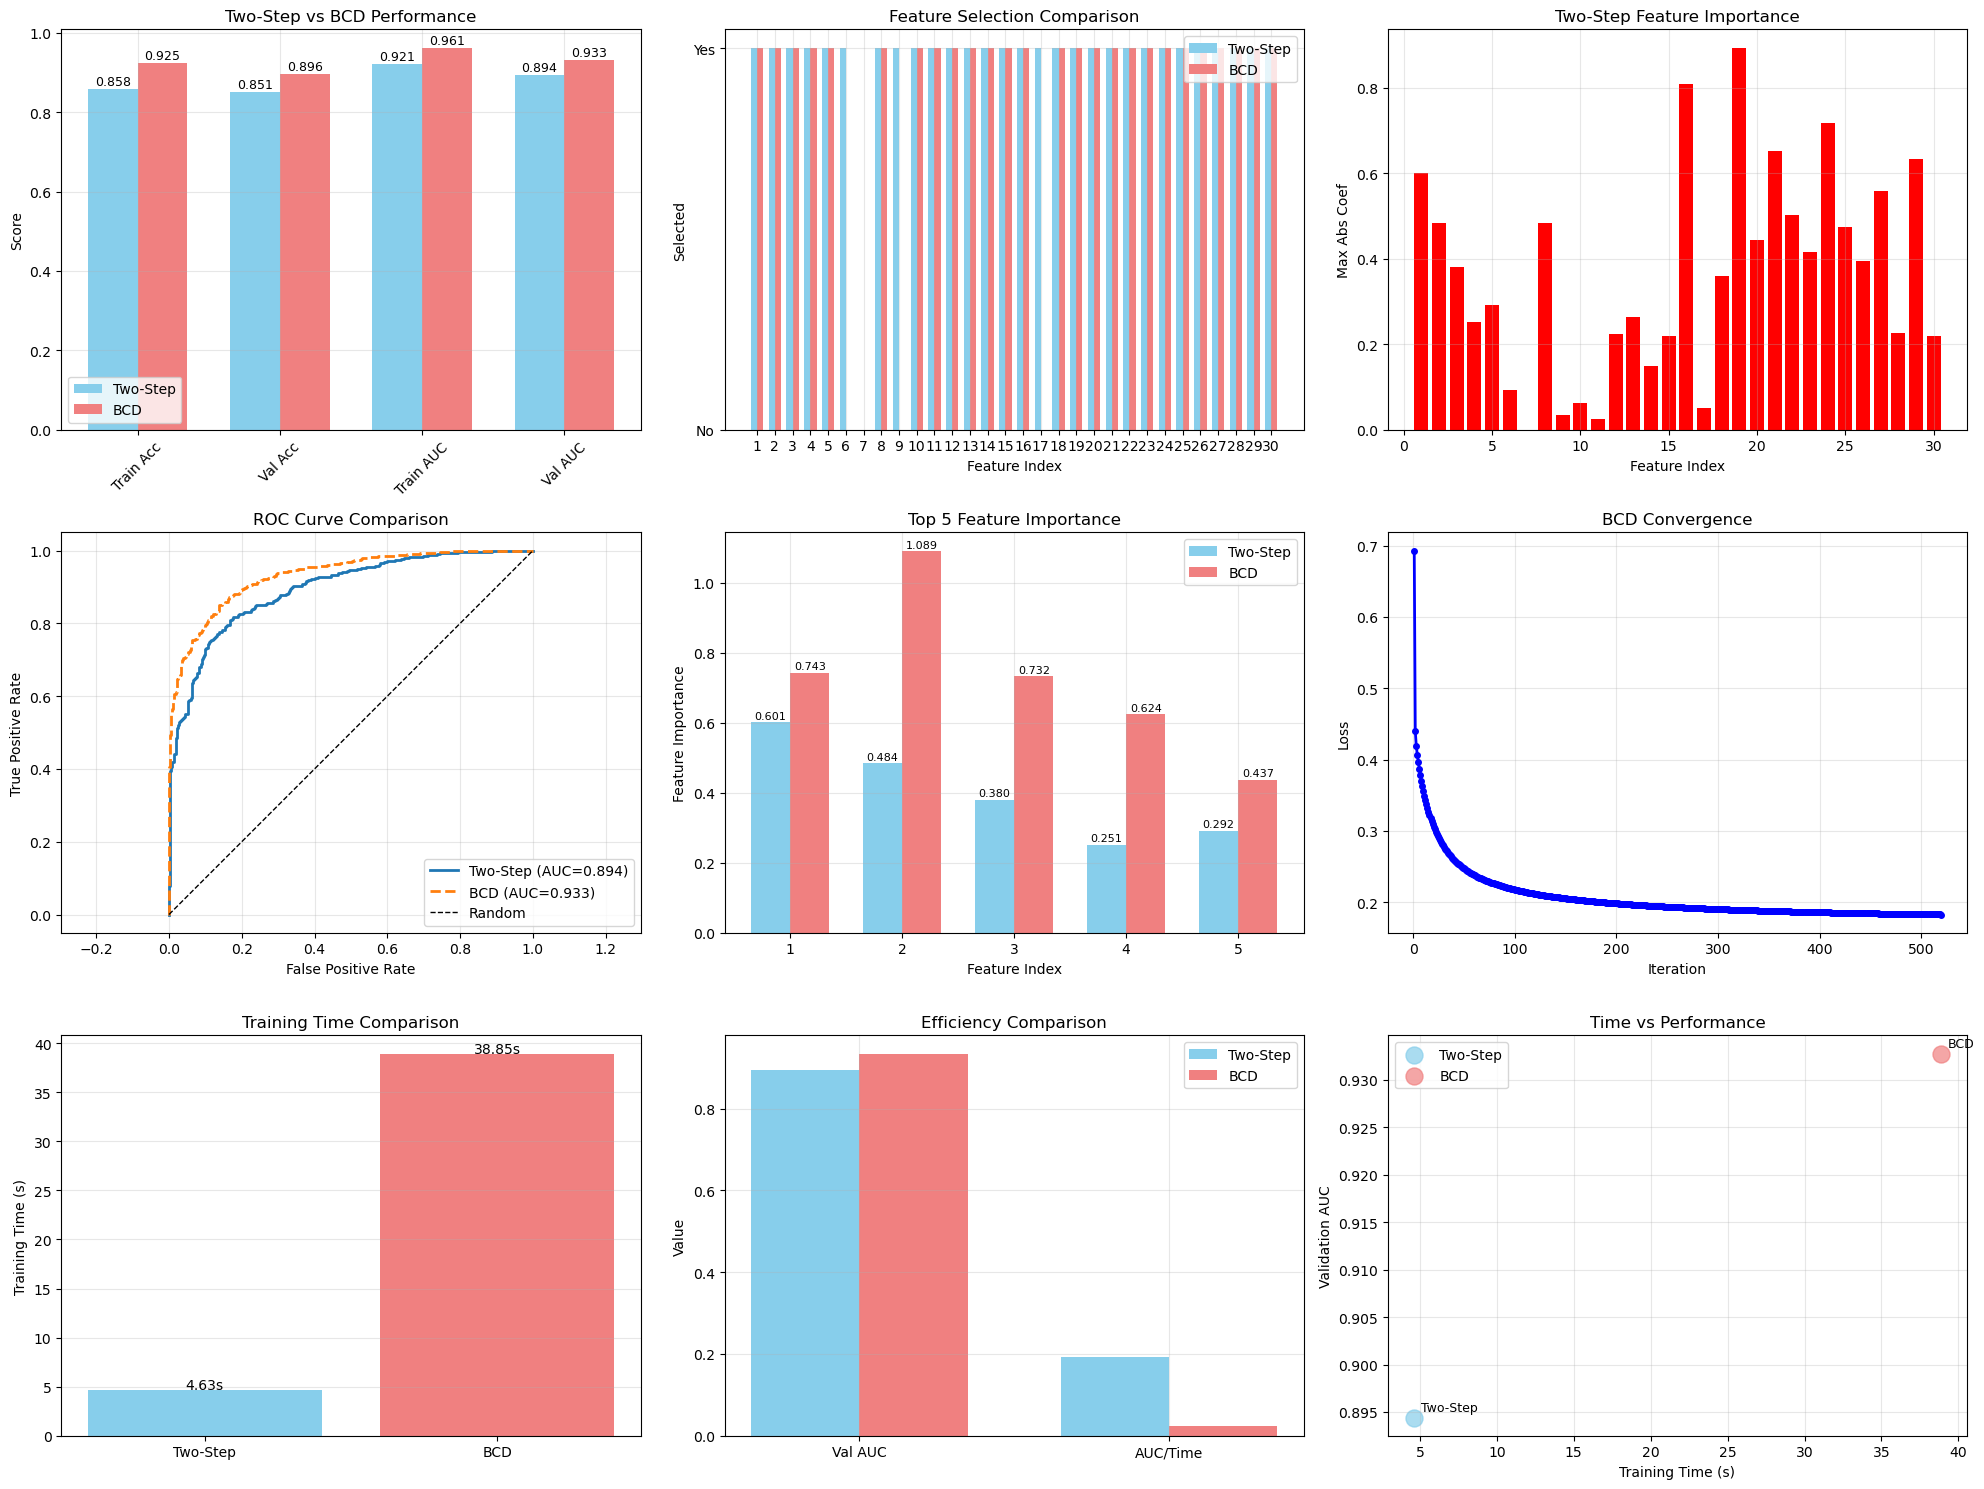

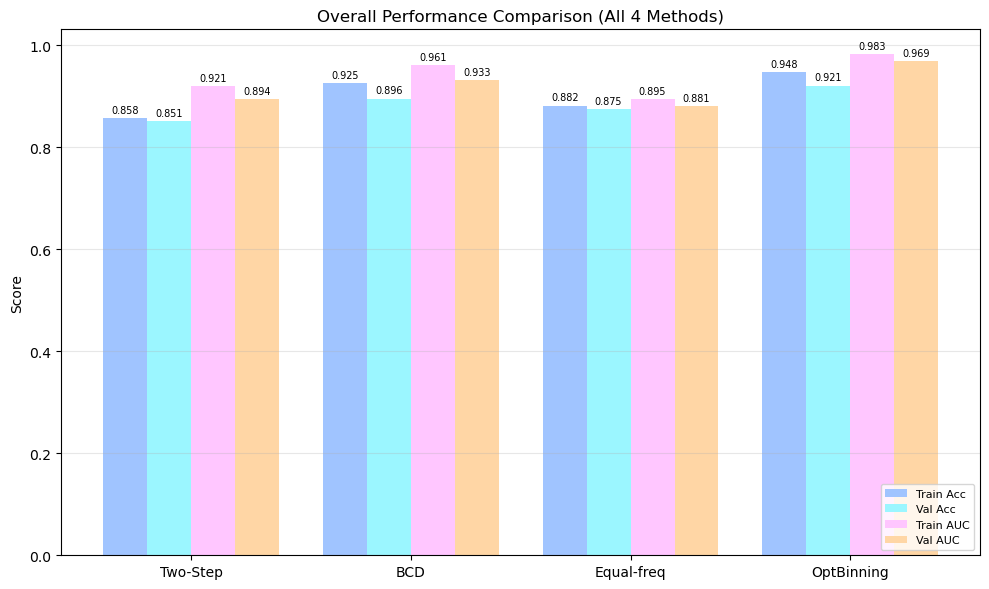

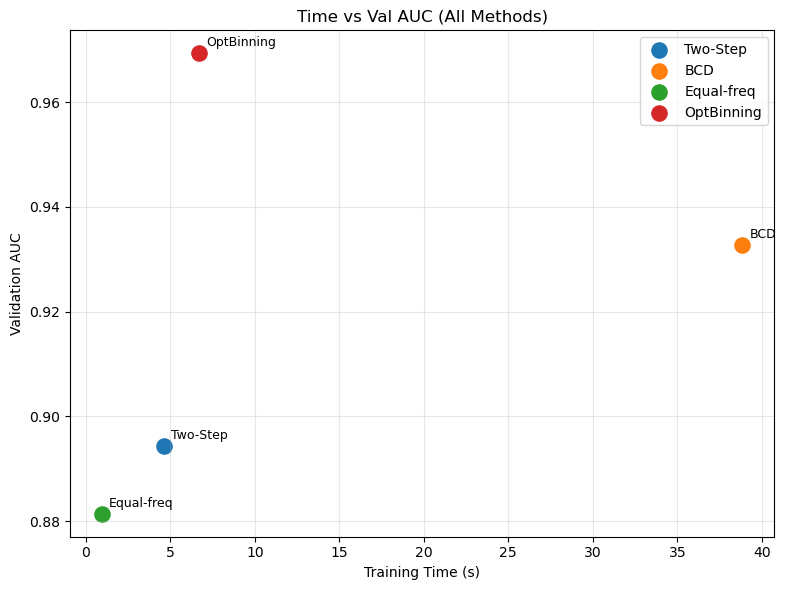


Detailed Comparison (All Methods)

--- Performance Metrics ---
Method           Train Acc    Val Acc  Train AUC    Val AUC    Time(s)
-----------------------------------------------------------------
Two-Step            0.8581     0.8510     0.9207     0.8944       4.63
BCD                 0.9255     0.8960     0.9612     0.9328      38.85
Equal-freq          0.8822     0.8750     0.8950     0.8814       0.97
OptBinning          0.9475     0.9215     0.9826     0.9693       6.69

--- Feature Selection (Two-Step / BCD) ---
Feature    True Effect  Two-Step   BCD       
---------------------------------------------
Feature 1  Yes          Yes        Yes       
Feature 2  Yes          Yes        Yes       
Feature 3  Yes          Yes        Yes       
Feature 4  Yes          Yes        Yes       
Feature 5  Yes          Yes        Yes       
Feature 6  Yes          Yes        No        
Feature 7  Yes          No         No        
Feature 8  Yes          Yes        Yes       
Feature 9  

In [28]:
# ============================================================================
# 完整实验：两步法 vs BCD vs 等频分箱 vs OptBinning（数据更新为30个特征）
# ============================================================================
from optbinning import OptimalBinning, BinningProcess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.linear_model import LassoCV, LogisticRegressionCV, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from scipy.special import expit
import time
import warnings
warnings.filterwarnings('ignore')

from optbinning import OptimalBinning   # 只需要分类版本

# ===================== 1. 生成数据（新设定：30个特征，复杂分箱） =====================
np.random.seed(42)
n_samples = 10000
n_features = 30    # 30个特征

X = np.random.randn(n_samples, n_features)

true_effect = np.zeros(n_samples)

# 特征1: 3个分箱结构
true_effect += np.where(X[:, 0] < -1, 1.2, np.where(X[:, 0] > 1, -0.8, 0.3))

# 特征2: 2个分箱结构
true_effect += np.where(X[:, 1] < 0, 0.8, -0.6)

# 特征3: 4个分箱结构
true_effect += np.where(X[:, 2] < -1.5, -1.0, 
                        np.where(X[:, 2] < 0, -0.5,
                                np.where(X[:, 2] < 1.5, 0.5, 1.0)))

# 特征4: 线性效应
true_effect += 0.5 * X[:, 3]

# 特征5: 阈值效应
true_effect += np.where(X[:, 4] > 0.8, 0.9, 0)

# 特征6-10: 2个分箱结构（随机阈值和系数）
for j in range(5, 10):
    threshold = np.random.uniform(-1, 1)
    coef1 = np.random.uniform(-0.8, 0.8)
    coef2 = np.random.uniform(-0.8, 0.8)
    true_effect += np.where(X[:, j] < threshold, coef1, coef2)

# 特征11-15: 3个分箱结构
for j in range(10, 15):
    threshold1 = np.random.uniform(-1.5, 0)
    threshold2 = np.random.uniform(0, 1.5)
    coef1 = np.random.uniform(-1.0, -0.3)
    coef2 = np.random.uniform(-0.2, 0.2)
    coef3 = np.random.uniform(0.3, 1.0)
    true_effect += np.where(X[:, j] < threshold1, coef1, 
                            np.where(X[:, j] < threshold2, coef2, coef3))

# 特征16-20: 4个分箱结构
for j in range(15, 20):
    threshold1 = np.random.uniform(-2.0, -1.0)
    threshold2 = np.random.uniform(-0.5, 0.5)
    threshold3 = np.random.uniform(1.0, 2.0)
    coef1 = np.random.uniform(-1.5, -0.8)
    coef2 = np.random.uniform(-0.4, 0)
    coef3 = np.random.uniform(0, 0.4)
    coef4 = np.random.uniform(0.8, 1.5)
    true_effect += np.where(X[:, j] < threshold1, coef1,
                            np.where(X[:, j] < threshold2, coef2,
                                    np.where(X[:, j] < threshold3, coef3, coef4)))

# 特征21-25: 复杂的非线性结构（多个分箱）
for j in range(20, 25):
    n_bins = np.random.choice([3, 4, 5])
    thresholds = sorted(np.random.uniform(-2, 2, n_bins-1))
    coefs = np.random.uniform(-1.0, 1.0, n_bins)
    expr = np.where(X[:, j] < thresholds[0], coefs[0], coefs[1])
    for k in range(1, len(thresholds)):
        expr = np.where(X[:, j] < thresholds[k], expr, coefs[k+1])
    true_effect += expr

# 特征26-30: 混合效应（部分线性，部分阈值）
for j in range(25, 30):
    effect_type = np.random.choice(['threshold', 'piecewise', 'linear'])
    if effect_type == 'threshold':
        threshold = np.random.uniform(-0.5, 0.5)
        coef = np.random.uniform(0.5, 1.5)
        true_effect += np.where(X[:, j] > threshold, coef, 0)
    elif effect_type == 'piecewise':
        threshold = np.random.uniform(-0.5, 0.5)
        coef1 = np.random.uniform(-1.0, -0.2)
        coef2 = np.random.uniform(0.2, 1.0)
        true_effect += np.where(X[:, j] < threshold, coef1, coef2)
    else:  # 'linear'
        slope = np.random.uniform(-0.7, 0.7)
        true_effect += slope * X[:, j]

# 添加噪声并生成二分类标签
y_proba = expit(true_effect + np.random.randn(n_samples) * 0.2)
y = (y_proba >= 0.5).astype(int)

split_idx = int(0.8 * n_samples)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

print(f"Train size: {X_train.shape}, Val size: {X_val.shape}")
print(f"Positive ratio: Train={y_train.mean():.3f}, Val={y_val.mean():.3f}")

# 为等频和OptBinning准备DataFrame
df_train = pd.DataFrame(X_train, columns=[f"feat_{i}" for i in range(n_features)])
df_val = pd.DataFrame(X_val, columns=[f"feat_{i}" for i in range(n_features)])

# ===================== 2. 辅助函数：等频 & OptBinning 分箱 =====================
def equal_freq_binning_fit_transform(X_df, bins=5):
    Xb = X_df.copy()
    bin_edges_dict = {}
    for col in Xb.columns:
        if Xb[col].nunique() <= 1:
            Xb[col] = 0
            bin_edges_dict[col] = None
        else:
            binned, edges = pd.qcut(X_df[col], bins, duplicates="drop", retbins=True)
            Xb[col] = binned.cat.codes
            bin_edges_dict[col] = edges
    return Xb.values, bin_edges_dict

def equal_freq_binning_transform(X_df, bin_edges_dict):
    Xb = X_df.copy()
    for col in Xb.columns:
        edges = bin_edges_dict.get(col, None)
        if edges is None or Xb[col].nunique() <= 1:
            Xb[col] = 0
        else:
            binned = pd.cut(X_df[col], bins=edges, include_lowest=True, duplicates="drop")
            Xb[col] = binned.cat.codes
    return Xb.values

def opt_binning_fit_transform(X_df, y, bins=5, top_n=None):
    """
    训练集上拟合 OptimalBinning，可选保留 IV 最高的 top_n 个特征。
    未被选中的特征 WOE 为 0，opts 对应项为 None。
    """
    Xb = X_df.copy()
    opts = []
    iv_list = []          # 存储每个特征的 IV
    temp_opts = []        # 暂存所有 opt 对象

    # 第一步：对每个特征拟合，收集 IV
    for col in Xb.columns:
        if Xb[col].nunique() <= 1:
            Xb[col] = 0
            temp_opts.append(None)
            iv_list.append(0)
        else:
            opt = OptimalBinning(dtype="numerical", max_n_bins=bins)
            opt.fit(X_df[col], y)
            # 获取 IV（信息值）
            #iv = opt.binning_table.build()['IV'].sum()  # 根据 optbinning 版本可能略有不同
            try:
                iv = opt.binning_table.build()['IV'].iloc[-1]  # 最后一行是 Totals
            except:
                iv = 0
            temp_opts.append(opt)
            iv_list.append(iv)

    # 第二步：确定要保留的特征索引
    if top_n is not None and top_n < len(iv_list):
        # 按 IV 从大到小排序，取前 top_n 个
        selected_idx = set(np.argsort(iv_list)[-top_n:])
    else:
        selected_idx = set(range(len(iv_list)))

    # 第三步：重新生成 WOE 矩阵，未选中的列置零
    Xb_woe = np.zeros_like(X_df.values, dtype=float)
    for idx, col in enumerate(Xb.columns):
        if idx in selected_idx and temp_opts[idx] is not None:
            Xb_woe[:, idx] = temp_opts[idx].transform(X_df[col], metric="woe")
            opts.append(temp_opts[idx])
        else:
            # 未选中或无效特征，WOE 为 0，opts 存 None
            Xb_woe[:, idx] = 0
            opts.append(None)

    return Xb_woe, opts

def opt_binning_transform(X_df, opts):
    Xb = X_df.copy()
    # 兼容 BinningProcess 或原列表
    for idx, col in enumerate(Xb.columns):
        obj = opts[idx]
        if obj is None or Xb[col].nunique() <= 1:
            Xb[col] = 0
        else:
            # BinningProcess 和 OptimalBinning 都有 transform 方法
            Xb[col] = obj.transform(X_df[[col]], metric="woe").flatten()
    return Xb.values


# ===================== 3. 两步法模型类（完整保留） =====================
class TwoStepBinningLasso:
    def __init__(self, n_bins=15, C=0.1, random_state=42):
        self.n_bins = n_bins
        self.C = C
        self.random_state = random_state
        self.bin_edges = None
        self.models = None
        self.lasso_model = None
        self.feature_selected = None
        self.feature_importances = None
        self.training_time = None
        
    def cluster_binning(self, X):
        n_samples, n_features = X.shape
        X_binned = np.zeros_like(X)
        self.bin_edges = []
        self.models = []
        for j in range(n_features):
            kmeans = KMeans(n_clusters=self.n_bins, random_state=self.random_state, n_init=10)
            kmeans.fit(X[:, j].reshape(-1, 1))
            centers = kmeans.cluster_centers_.flatten()
            sorted_centers = np.sort(centers)
            bin_edges_j = np.concatenate([
                [X[:, j].min() - 1e-5],
                (sorted_centers[:-1] + sorted_centers[1:]) / 2,
                [X[:, j].max() + 1e-5]
            ])
            bin_edges_j = np.sort(bin_edges_j)
            self.bin_edges.append(bin_edges_j)
            self.models.append(kmeans)
            X_binned[:, j] = np.digitize(X[:, j], bin_edges_j[1:-1])
        return X_binned
    
    def one_hot_encode(self, X_binned, bin_edges=None):
        if bin_edges is None:
            bin_edges = self.bin_edges
        n_samples, n_features = X_binned.shape
        onehot_features = []
        for j in range(n_features):
            Kj = len(bin_edges[j]) - 1
            onehot = np.zeros((n_samples, Kj))
            binned_vals = np.clip(X_binned[:, j].astype(int), 0, Kj-1)
            for i in range(n_samples):
                if binned_vals[i] >= 0 and binned_vals[i] < Kj:
                    onehot[i, binned_vals[i]] = 1
            onehot = onehot[:, 1:]   # 丢弃第一个箱
            onehot_features.append(onehot)
        return np.hstack(onehot_features)
    
    def fit(self, X_train, y_train, X_val=None, y_val=None):
        start_time = time.time()
        print("Two-Step: Step 1 - Cluster binning...")
        X_train_binned = self.cluster_binning(X_train)
        X_train_onehot = self.one_hot_encode(X_train_binned)
        print(f"Two-Step: One-hot dim: {X_train_onehot.shape[1]}")
        print("Two-Step: Step 2 - Lasso selection...")
        self.lasso_model = LogisticRegression(
            penalty='l1', C=self.C, solver='liblinear',
            random_state=self.random_state, max_iter=1000
        )
        self.lasso_model.fit(X_train_onehot, y_train)
        coefficients = self.lasso_model.coef_.flatten()
        n_original_features = len(self.bin_edges)
        n_bins_per_feature = [len(edges)-2 for edges in self.bin_edges]
        self.feature_selected = []
        self.feature_importances = np.zeros(n_original_features)
        start_idx = 0
        for j in range(n_original_features):
            n_bins = n_bins_per_feature[j]
            feature_coefs = coefficients[start_idx:start_idx+n_bins]
            importance = np.max(np.abs(feature_coefs))
            self.feature_importances[j] = importance
            is_selected = np.any(np.abs(feature_coefs) > 1e-6)
            self.feature_selected.append(is_selected)
            start_idx += n_bins
        end_time = time.time()
        self.training_time = end_time - start_time
        print(f"Two-Step: Selected {np.sum(self.feature_selected)}/{n_original_features} features, time={self.training_time:.2f}s")
        return self
    
    def predict_proba(self, X):
        if self.lasso_model is None:
            raise ValueError("Model not fitted")
        n_samples, n_features = X.shape
        X_binned = np.zeros((n_samples, n_features))
        for j in range(n_features):
            X_binned[:, j] = np.digitize(X[:, j], self.bin_edges[j][1:-1])
        X_onehot = self.one_hot_encode(X_binned, self.bin_edges)
        return self.lasso_model.predict_proba(X_onehot)[:, 1]
    
    def predict(self, X, threshold=0.5):
        y_proba = self.predict_proba(X)
        return (y_proba >= threshold).astype(int)
    
    def get_feature_info(self):
        feature_info = {}
        n_original_features = len(self.bin_edges)
        coefficients = self.lasso_model.coef_.flatten()
        n_bins_per_feature = [len(edges)-2 for edges in self.bin_edges]
        start_idx = 0
        for j in range(n_original_features):
            n_bins = n_bins_per_feature[j]
            feature_coefs = coefficients[start_idx:start_idx+n_bins]
            bin_edges_j = self.bin_edges[j]
            bin_intervals = [(bin_edges_j[k], bin_edges_j[k+1]) for k in range(len(bin_edges_j)-1)]
            bin_intervals = bin_intervals[1:]
            feature_info[f"feature_{j+1}"] = {
                "is_selected": self.feature_selected[j],
                "importance": self.feature_importances[j],
                "final_bins_count": n_bins,
                "final_bin_intervals": bin_intervals,
                "bin_coefficients": feature_coefs.tolist()
            }
            start_idx += n_bins
        return feature_info


# ===================== 4. 两步法训练 =====================
print("\n" + "="*50)
print("Two-Step Model Training")
print("="*50)
two_step_model = TwoStepBinningLasso(n_bins=15, C=0.05)
two_step_model.fit(X_train, y_train, X_val, y_val)

y_train_pred_two_step = two_step_model.predict(X_train)
y_val_pred_two_step = two_step_model.predict(X_val)
y_train_proba_two_step = two_step_model.predict_proba(X_train)
y_val_proba_two_step = two_step_model.predict_proba(X_val)

train_acc_two_step = accuracy_score(y_train, y_train_pred_two_step)
val_acc_two_step = accuracy_score(y_val, y_val_pred_two_step)
train_auc_two_step = roc_auc_score(y_train, y_train_proba_two_step)
val_auc_two_step = roc_auc_score(y_val, y_val_proba_two_step)

print(f"Two-Step Train Acc: {train_acc_two_step:.4f}, Val Acc: {val_acc_two_step:.4f}")
print(f"Two-Step Train AUC: {train_auc_two_step:.4f}, Val AUC: {val_auc_two_step:.4f}")
two_step_selected_features = [i+1 for i, selected in enumerate(two_step_model.feature_selected) if selected]
print(f"Two-Step Selected Features: {two_step_selected_features}")

# ===================== 5. BCD 模型训练 =====================
print("\n" + "="*50)
print("BCD Algorithm Training")
print("="*50)
bcd_start_time = time.time()

bcd_model = BCDOptimalBinning(
    lambda_f=2e-5, lambda_b=1e-5,
    max_iter=750, tol=1e-6, verbose=True,
    metric='auc'
)
bcd_model.fit(X_train, y_train, X_val, y_val, n_pre_bins=15)

bcd_end_time = time.time()
bcd_training_time = bcd_end_time - bcd_start_time

y_train_pred_bcd = bcd_model.predict(X_train)
y_val_pred_bcd = bcd_model.predict(X_val)
y_train_proba_bcd = bcd_model.predict_proba(X_train)
y_val_proba_bcd = bcd_model.predict_proba(X_val)

train_acc_bcd = accuracy_score(y_train, y_train_pred_bcd)
val_acc_bcd = accuracy_score(y_val, y_val_pred_bcd)
train_auc_bcd = roc_auc_score(y_train, y_train_proba_bcd)
val_auc_bcd = roc_auc_score(y_val, y_val_proba_bcd)

binning_result = bcd_model.get_optimal_binning_structure()
bcd_selected_features = []
for j in range(1, n_features + 1):  # 改为 1..30
    feat_name = f"feature_{j}"
    if binning_result[feat_name]["is_selected"]:
        bcd_selected_features.append(j)

print(f"BCD Train Acc: {train_acc_bcd:.4f}, Val Acc: {val_acc_bcd:.4f}")
print(f"BCD Train AUC: {train_auc_bcd:.4f}, Val AUC: {val_auc_bcd:.4f}")
print(f"BCD Time: {bcd_training_time:.2f}s")
print(f"BCD Selected Features: {bcd_selected_features}")
bcd_loss_history = bcd_model.history['loss']


# ===================== 6. 等频分箱 & OptBinning 实验 =====================
print("\n" + "="*50)
print("Equal-frequency & OptBinning Experiments")
print("="*50)

# 6.1 等频分箱
start_eq = time.time()
X_train_eq, eq_edges = equal_freq_binning_fit_transform(df_train, bins=5)
X_val_eq = equal_freq_binning_transform(df_val, eq_edges)
eq_model = LogisticRegressionCV(
    penalty='l1', solver='liblinear', random_state=42, max_iter=2000, cv=5
)
eq_model.fit(StandardScaler().fit_transform(X_train_eq), y_train)
y_train_proba_eq = eq_model.predict_proba(StandardScaler().fit_transform(X_train_eq))[:, 1]
y_val_proba_eq = eq_model.predict_proba(StandardScaler().fit_transform(X_val_eq))[:, 1]
eq_time = time.time() - start_eq
train_acc_eq = accuracy_score(y_train, (y_train_proba_eq >= 0.5).astype(int))
val_acc_eq = accuracy_score(y_val, (y_val_proba_eq >= 0.5).astype(int))
train_auc_eq = roc_auc_score(y_train, y_train_proba_eq)
val_auc_eq = roc_auc_score(y_val, y_val_proba_eq)
print(f"Equal-freq Val AUC: {val_auc_eq:.4f}, Time: {eq_time:.2f}s")

# 6.2 OptBinning
start_opt = time.time()
opt_selection_top = 30   # 设置保留的最多特征数，可根据需要调整
X_train_opt, opt_objects = opt_binning_fit_transform(
    df_train, y_train, bins=5, top_n=opt_selection_top
)
X_val_opt = opt_binning_transform(df_val, opt_objects)


opt_model = LogisticRegressionCV(
    penalty='l1', solver='liblinear', random_state=42, max_iter=2000, cv=5
)
opt_model.fit(StandardScaler().fit_transform(X_train_opt), y_train)
y_train_proba_opt = opt_model.predict_proba(StandardScaler().fit_transform(X_train_opt))[:, 1]
y_val_proba_opt = opt_model.predict_proba(StandardScaler().fit_transform(X_val_opt))[:, 1]
opt_time = time.time() - start_opt
train_acc_opt = accuracy_score(y_train, (y_train_proba_opt >= 0.5).astype(int))
val_acc_opt = accuracy_score(y_val, (y_val_proba_opt >= 0.5).astype(int))
train_auc_opt = roc_auc_score(y_train, y_train_proba_opt)
val_auc_opt = roc_auc_score(y_val, y_val_proba_opt)
print(f"OptBinning Val AUC: {val_auc_opt:.4f}, Time: {opt_time:.2f}s")


# ===================== 7. 汇总所有方法的结果 =====================
methods = ['Two-Step', 'BCD', 'Equal-freq', 'OptBinning']
val_aucs_all = [val_auc_two_step, val_auc_bcd, val_auc_eq, val_auc_opt]
train_aucs_all = [train_auc_two_step, train_auc_bcd, train_auc_eq, train_auc_opt]
val_accs_all = [val_acc_two_step, val_acc_bcd, val_acc_eq, val_acc_opt]
train_accs_all = [train_acc_two_step, train_acc_bcd, train_acc_eq, train_acc_opt]
times_all = [two_step_model.training_time, bcd_training_time, eq_time, opt_time]


# ===================== 8. 原有9子图可视化 =====================
plt.figure(figsize=(20, 15))

# 子图1：两步法 vs BCD 性能对比
plt.subplot(3, 3, 1)
metrics = ['Train Acc', 'Val Acc', 'Train AUC', 'Val AUC']
two_step_values = [train_acc_two_step, val_acc_two_step, train_auc_two_step, val_auc_two_step]
bcd_values = [train_acc_bcd, val_acc_bcd, train_auc_bcd, val_auc_bcd]
x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, two_step_values, width, label='Two-Step', color='skyblue')
plt.bar(x + width/2, bcd_values, width, label='BCD', color='lightcoral')
plt.xticks(x, metrics, rotation=45)
plt.ylabel('Score')
plt.title('Two-Step vs BCD Performance')
plt.legend()
plt.grid(True, alpha=0.3)
for i, (v1, v2) in enumerate(zip(two_step_values, bcd_values)):
    plt.text(i - width/2, v1 + 0.01, f'{v1:.3f}', ha='center', fontsize=9)
    plt.text(i + width/2, v2 + 0.01, f'{v2:.3f}', ha='center', fontsize=9)

# 子图2：特征选择对比
plt.subplot(3, 3, 2)
all_features = list(range(1, n_features + 1))
two_step_selection = [1 if f in two_step_selected_features else 0 for f in all_features]
bcd_selection = [1 if f in bcd_selected_features else 0 for f in all_features]
x_feat = np.arange(len(all_features))
plt.bar(x_feat - width/2, two_step_selection, width, label='Two-Step', color='skyblue')
plt.bar(x_feat + width/2, bcd_selection, width, label='BCD', color='lightcoral')
plt.xlabel('Feature Index')
plt.ylabel('Selected')
plt.title('Feature Selection Comparison')
plt.xticks(x_feat, all_features)
plt.yticks([0, 1], ['No', 'Yes'])
plt.legend()
plt.grid(True, alpha=0.3)

# 子图3：两步法特征重要性
plt.subplot(3, 3, 3)
importance_values = two_step_model.feature_importances
colors = ['red' if selected else 'blue' for selected in two_step_model.feature_selected]
plt.bar(range(1, len(importance_values)+1), importance_values, color=colors)
plt.xlabel('Feature Index')
plt.ylabel('Max Abs Coef')
plt.title('Two-Step Feature Importance')
plt.grid(True, alpha=0.3)

# 子图4：ROC曲线
plt.subplot(3, 3, 4)
fpr_two_step, tpr_two_step, _ = roc_curve(y_val, y_val_proba_two_step)
fpr_bcd, tpr_bcd, _ = roc_curve(y_val, y_val_proba_bcd)
plt.plot(fpr_two_step, tpr_two_step, label=f'Two-Step (AUC={val_auc_two_step:.3f})', linewidth=2)
plt.plot(fpr_bcd, tpr_bcd, label=f'BCD (AUC={val_auc_bcd:.3f})', linewidth=2, linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# 子图5：前5个特征系数对比
plt.subplot(3, 3, 5)
effective_features = [1, 2, 3, 4, 5]
two_step_coefs = [two_step_model.feature_importances[f-1] for f in effective_features]
bcd_coefs = []
for feat in effective_features:
    feat_name = f"feature_{feat}"
    feat_info = binning_result[feat_name]
    if feat_info['is_selected'] and len(feat_info['final_bin_coefficients']) > 0:
        coefs = np.array(feat_info['final_bin_coefficients'])
        importance = np.mean(np.abs(coefs))
        bcd_coefs.append(importance)
    else:
        bcd_coefs.append(0)
x_top5 = np.arange(len(effective_features))
plt.bar(x_top5 - width/2, two_step_coefs, width, label='Two-Step', color='skyblue')
plt.bar(x_top5 + width/2, bcd_coefs, width, label='BCD', color='lightcoral')
plt.xlabel('Feature Index')
plt.ylabel('Feature Importance')
plt.title('Top 5 Feature Importance')
plt.xticks(x_top5, effective_features)
plt.legend()
plt.grid(True, alpha=0.3)
for i, (v1, v2) in enumerate(zip(two_step_coefs, bcd_coefs)):
    plt.text(i - width/2, v1 + 0.01, f'{v1:.3f}', ha='center', fontsize=8)
    plt.text(i + width/2, v2 + 0.01, f'{v2:.3f}', ha='center', fontsize=8)

# 子图6：BCD收敛曲线
plt.subplot(3, 3, 6)
if len(bcd_loss_history) > 0:
    iterations = range(1, len(bcd_loss_history)+1)
    plt.plot(iterations, bcd_loss_history, 'b-', linewidth=2, marker='o', markersize=4)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('BCD Convergence')
    plt.grid(True, alpha=0.3)
    if max(bcd_loss_history)/min(bcd_loss_history) > 100:
        plt.yscale('log')

# 子图7：训练时间对比
plt.subplot(3, 3, 7)
plt.bar(['Two-Step', 'BCD'], [two_step_model.training_time, bcd_training_time], color=['skyblue', 'lightcoral'])
plt.ylabel('Training Time (s)')
plt.title('Training Time Comparison')
plt.grid(True, alpha=0.3, axis='y')
for i, v in enumerate([two_step_model.training_time, bcd_training_time]):
    plt.text(i, v + 0.1, f'{v:.2f}s', ha='center')

# 子图8：效率对比
plt.subplot(3, 3, 8)
auc_per_sec_two_step = val_auc_two_step / two_step_model.training_time
auc_per_sec_bcd = val_auc_bcd / bcd_training_time
x_eff = np.arange(2)
plt.bar(x_eff - width/2, [val_auc_two_step, auc_per_sec_two_step], width, label='Two-Step', color='skyblue')
plt.bar(x_eff + width/2, [val_auc_bcd, auc_per_sec_bcd], width, label='BCD', color='lightcoral')
plt.xticks(x_eff, ['Val AUC', 'AUC/Time'])
plt.ylabel('Value')
plt.title('Efficiency Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图9：时间 vs AUC散点图
plt.subplot(3, 3, 9)
plt.scatter(two_step_model.training_time, val_auc_two_step, s=150, label='Two-Step', color='skyblue', alpha=0.7)
plt.scatter(bcd_training_time, val_auc_bcd, s=150, label='BCD', color='lightcoral', alpha=0.7)
plt.annotate('Two-Step', (two_step_model.training_time, val_auc_two_step), xytext=(5,5), textcoords='offset points', fontsize=9)
plt.annotate('BCD', (bcd_training_time, val_auc_bcd), xytext=(5,5), textcoords='offset points', fontsize=9)
plt.xlabel('Training Time (s)')
plt.ylabel('Validation AUC')
plt.title('Time vs Performance')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# ===================== 9. 新图：四种方法整体对比 =====================
plt.figure(figsize=(10, 6))
x = np.arange(len(methods))
width = 0.2
plt.bar(x - 1.5*width, train_accs_all, width, label='Train Acc', color='#a0c4ff')
plt.bar(x - 0.5*width, val_accs_all, width, label='Val Acc', color='#9bf6ff')
plt.bar(x + 0.5*width, train_aucs_all, width, label='Train AUC', color='#ffc6ff')
plt.bar(x + 1.5*width, val_aucs_all, width, label='Val AUC', color='#ffd6a5')
plt.xticks(x, methods)
plt.ylabel('Score')
plt.title('Overall Performance Comparison (All 4 Methods)')
plt.legend(fontsize=8, loc='lower right')
plt.grid(axis='y', alpha=0.3)
for i in range(len(methods)):
    plt.text(i - 1.5*width, train_accs_all[i]+0.01, f'{train_accs_all[i]:.3f}', ha='center', fontsize=7)
    plt.text(i - 0.5*width, val_accs_all[i]+0.01, f'{val_accs_all[i]:.3f}', ha='center', fontsize=7)
    plt.text(i + 0.5*width, train_aucs_all[i]+0.01, f'{train_aucs_all[i]:.3f}', ha='center', fontsize=7)
    plt.text(i + 1.5*width, val_aucs_all[i]+0.01, f'{val_aucs_all[i]:.3f}', ha='center', fontsize=7)
plt.tight_layout()
plt.show()

# 新图2：时间与验证AUC散点图
plt.figure(figsize=(8, 6))
for i, method in enumerate(methods):
    plt.scatter(times_all[i], val_aucs_all[i], s=120, label=method)
    plt.annotate(method, (times_all[i], val_aucs_all[i]), xytext=(5,5), textcoords='offset points', fontsize=9)
plt.xlabel('Training Time (s)')
plt.ylabel('Validation AUC')
plt.title('Time vs Val AUC (All Methods)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ===================== 10. 打印详细结果表格 =====================
print("\n" + "="*50)
print("Detailed Comparison (All Methods)")
print("="*50)

print("\n--- Performance Metrics ---")
print(f"{'Method':<15} {'Train Acc':>10} {'Val Acc':>10} {'Train AUC':>10} {'Val AUC':>10} {'Time(s)':>10}")
print("-"*65)
for i, method in enumerate(methods):
    print(f"{method:<15} {train_accs_all[i]:>10.4f} {val_accs_all[i]:>10.4f} {train_aucs_all[i]:>10.4f} {val_aucs_all[i]:>10.4f} {times_all[i]:>10.2f}")

print("\n--- Feature Selection (Two-Step / BCD) ---")
print(f"{'Feature':<10} {'True Effect':<12} {'Two-Step':<10} {'BCD':<10}")
print("-"*45)
# 这里根据新数据：所有特征都有真实效应
for i in range(1, n_features+1):
    has_eff = "Yes"  # 所有特征都有效应
    two_sel = "Yes" if i in two_step_selected_features else "No"
    bcd_sel = "Yes" if i in bcd_selected_features else "No"
    print(f"Feature {i:<2} {has_eff:<12} {two_sel:<10} {bcd_sel:<10}")

# 特征选择性能（所有特征均为相关变量，因此 ground truth 全为1）
def sel_metrics(true_list, pred_list):
    tp = sum(1 for t,p in zip(true_list, pred_list) if t==1 and p==1)
    fp = sum(1 for t,p in zip(true_list, pred_list) if t==0 and p==1)
    fn = sum(1 for t,p in zip(true_list, pred_list) if t==1 and p==0)
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec = tp/(tp+fn) if (tp+fn)>0 else 0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    return prec, rec, f1

true_sel = [1] * n_features  # 所有30个特征都是有效的
two_sel_bin = [1 if i+1 in two_step_selected_features else 0 for i in range(n_features)]
bcd_sel_bin = [1 if i+1 in bcd_selected_features else 0 for i in range(n_features)]
prec2, rec2, f12 = sel_metrics(true_sel, two_sel_bin)
precB, recB, f1B = sel_metrics(true_sel, bcd_sel_bin)
print("\n--- Feature Selection Quality ---")
print(f"Two-Step: Precision={prec2:.3f}, Recall={rec2:.3f}, F1={f12:.3f}")
print(f"BCD:      Precision={precB:.3f}, Recall={recB:.3f}, F1={f1B:.3f}")

print("\nExperiment finished.")

20变量

Train size: (8000, 30), Val size: (2000, 30)
Positive ratio: Train=0.840, Val=0.833

Two-Step Model Training
Two-Step: Step 1 - Cluster binning...
Two-Step: One-hot dim: 420
Two-Step: Step 2 - Lasso selection...
Two-Step: Selected 29/30 features, time=4.05s
Two-Step Train Acc: 0.8581, Val Acc: 0.8510
Two-Step Train AUC: 0.9207, Val AUC: 0.8944
Two-Step Selected Features: [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]

BCD Algorithm Training
Iter    1 | Loss: 0.444476 | Drop: 0.24867097 | Train Auc: 0.779578 | Val Auc: 0.762406
Iter    3 | Loss: 0.424323 | Drop: 0.00937719 | Train Auc: 0.861381 | Val Auc: 0.838092
Iter    5 | Loss: 0.410002 | Drop: 0.00677866 | Train Auc: 0.874877 | Val Auc: 0.851487
Iter    7 | Loss: 0.398052 | Drop: 0.00573204 | Train Auc: 0.877157 | Val Auc: 0.853885
Iter    9 | Loss: 0.387864 | Drop: 0.00489376 | Train Auc: 0.877069 | Val Auc: 0.853890
Iter   11 | Loss: 0.379146 | Drop: 0.00419134 | Train

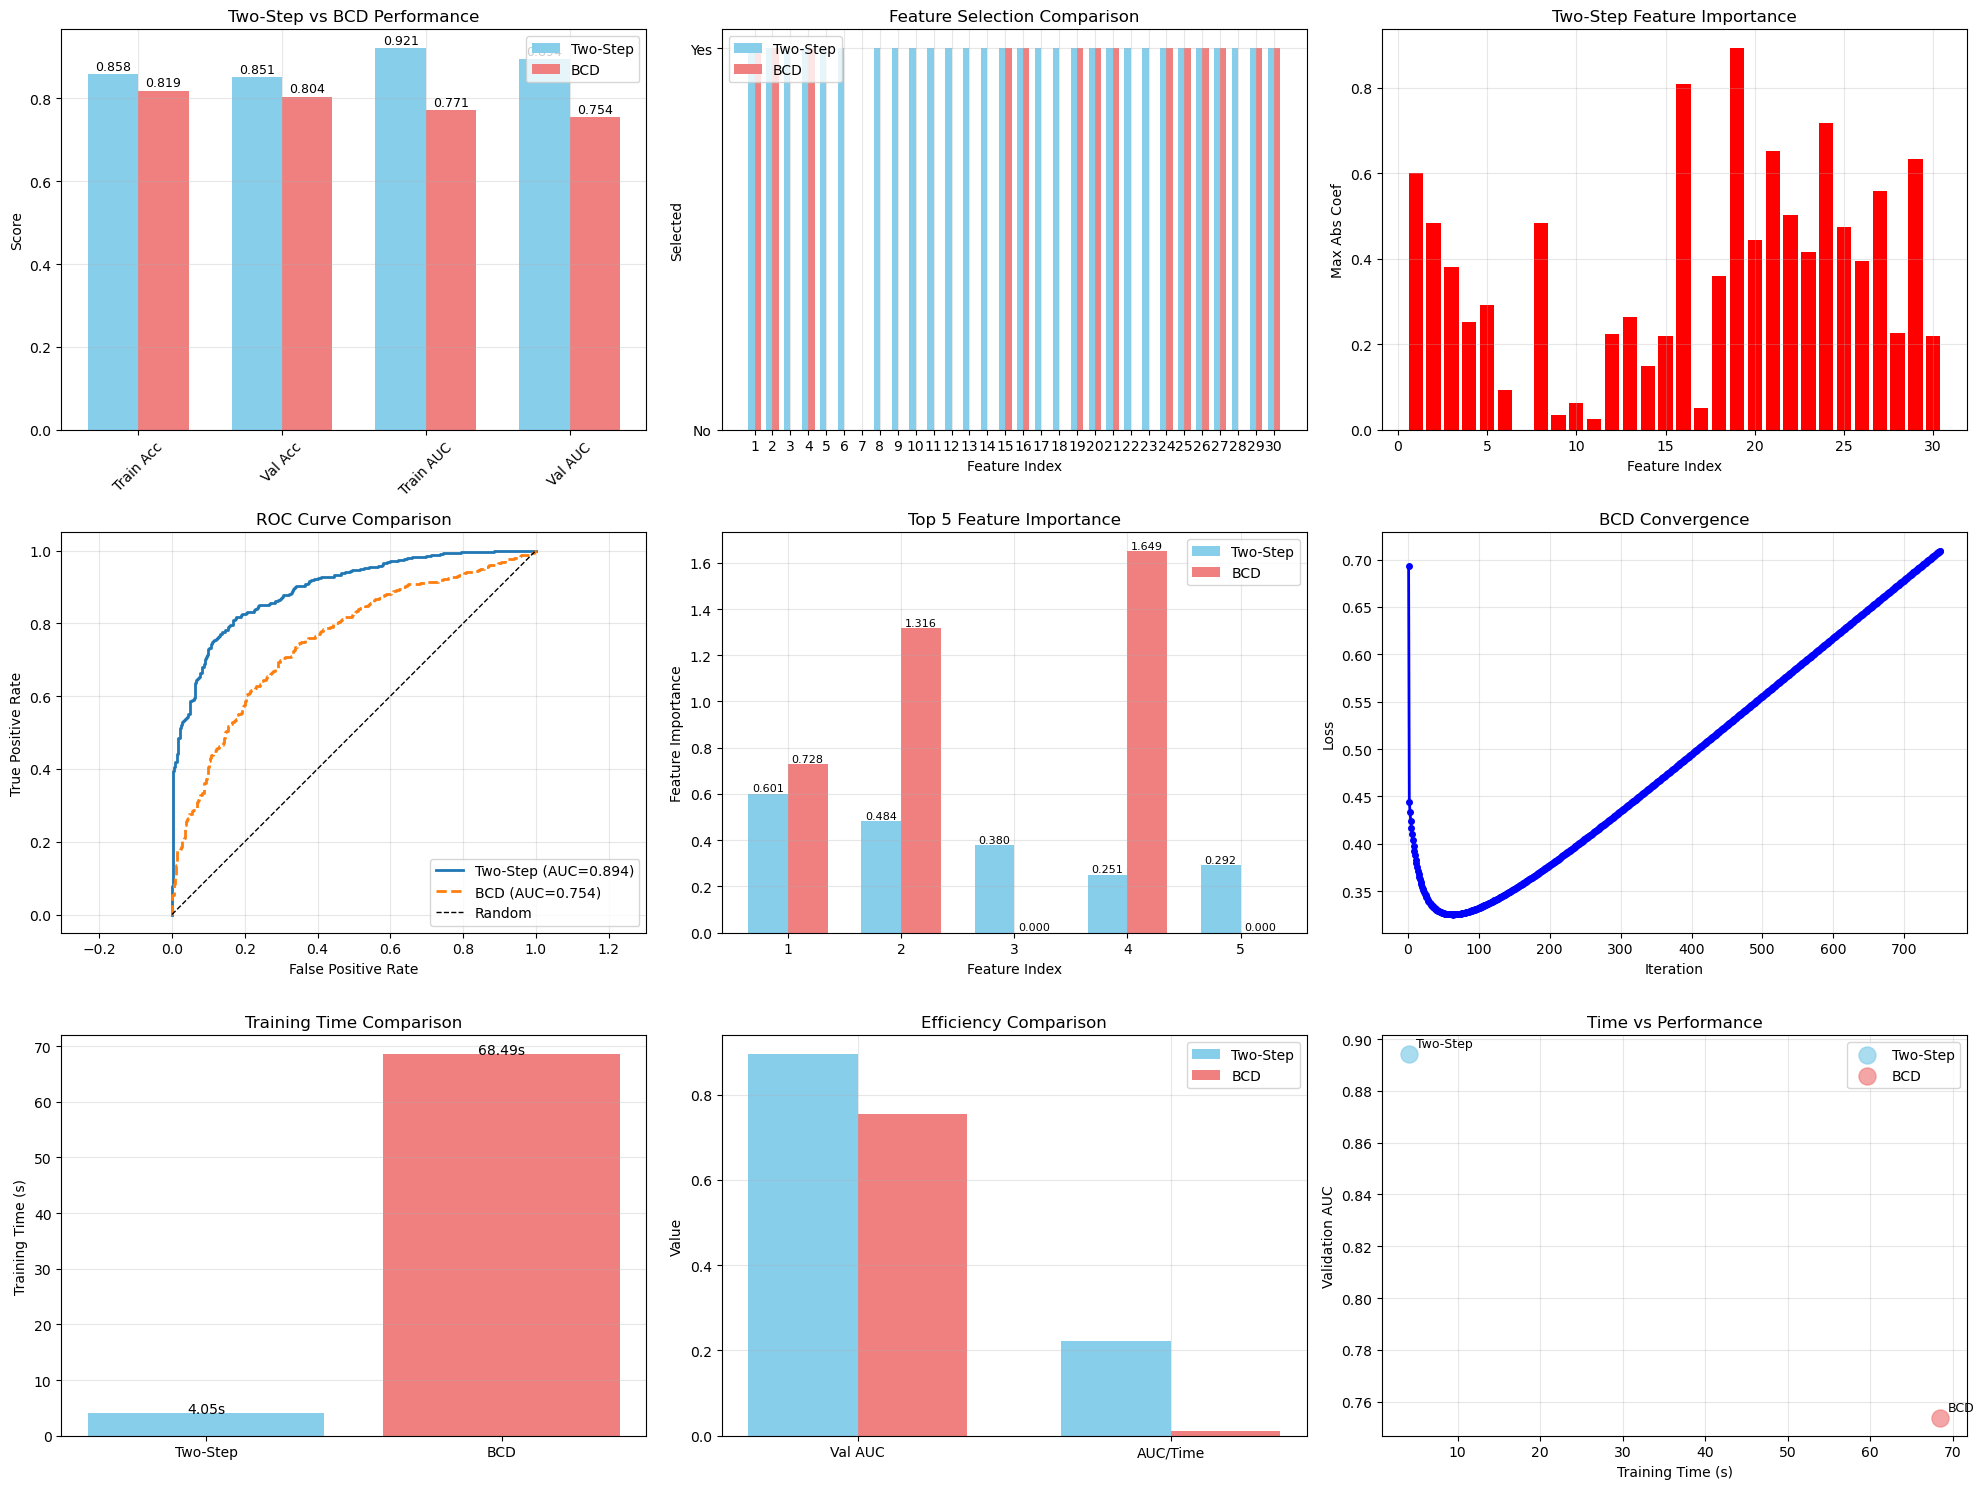

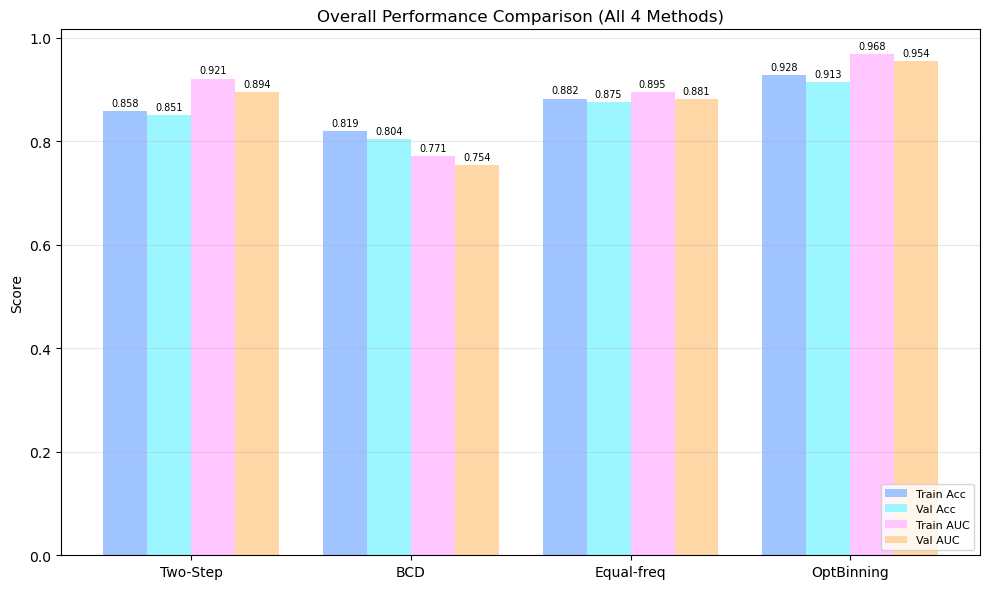

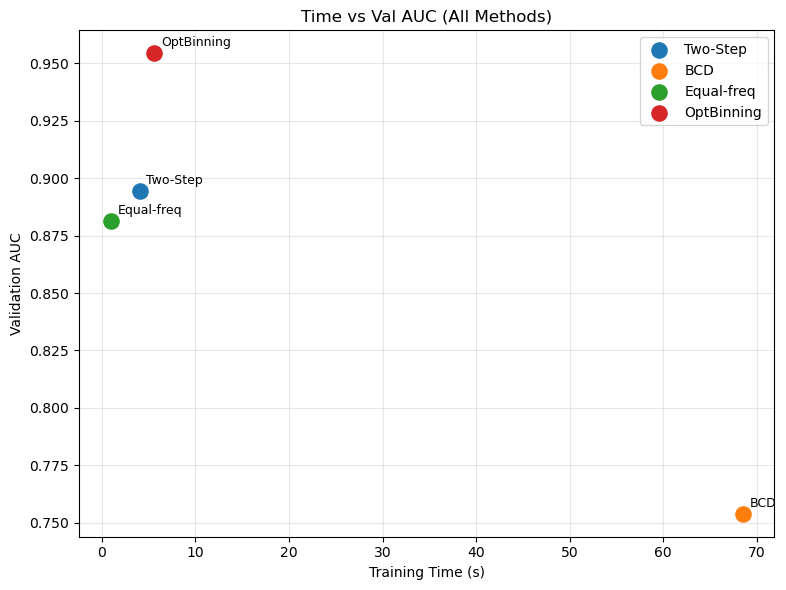


Detailed Comparison (All Methods)

--- Performance Metrics ---
Method           Train Acc    Val Acc  Train AUC    Val AUC    Time(s)
-----------------------------------------------------------------
Two-Step            0.8581     0.8510     0.9207     0.8944       4.05
BCD                 0.8187     0.8045     0.7713     0.7539      68.49
Equal-freq          0.8822     0.8750     0.8950     0.8814       0.97
OptBinning          0.9283     0.9135     0.9676     0.9544       5.57

--- Feature Selection (Two-Step / BCD) ---
Feature    True Effect  Two-Step   BCD       
---------------------------------------------
Feature 1  Yes          Yes        Yes       
Feature 2  Yes          Yes        Yes       
Feature 3  Yes          Yes        No        
Feature 4  Yes          Yes        Yes       
Feature 5  Yes          Yes        No        
Feature 6  Yes          Yes        No        
Feature 7  Yes          No         No        
Feature 8  Yes          Yes        No        
Feature 9  

In [ ]:
# ============================================================================
# 完整实验：两步法 vs BCD vs 等频分箱 vs OptBinning（数据更新为30个特征）
# ============================================================================
from optbinning import OptimalBinning, BinningProcess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.linear_model import LassoCV, LogisticRegressionCV, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from scipy.special import expit
import time
import warnings
warnings.filterwarnings('ignore')

from optbinning import OptimalBinning   # 只需要分类版本

# ===================== 1. 生成数据（新设定：30个特征，复杂分箱） =====================
np.random.seed(42)
n_samples = 10000
n_features = 30    # 30个特征

X = np.random.randn(n_samples, n_features)

true_effect = np.zeros(n_samples)

# 特征1: 3个分箱结构
true_effect += np.where(X[:, 0] < -1, 1.2, np.where(X[:, 0] > 1, -0.8, 0.3))

# 特征2: 2个分箱结构
true_effect += np.where(X[:, 1] < 0, 0.8, -0.6)

# 特征3: 4个分箱结构
true_effect += np.where(X[:, 2] < -1.5, -1.0, 
                        np.where(X[:, 2] < 0, -0.5,
                                np.where(X[:, 2] < 1.5, 0.5, 1.0)))

# 特征4: 线性效应
true_effect += 0.5 * X[:, 3]

# 特征5: 阈值效应
true_effect += np.where(X[:, 4] > 0.8, 0.9, 0)

# 特征6-10: 2个分箱结构（随机阈值和系数）
for j in range(5, 10):
    threshold = np.random.uniform(-1, 1)
    coef1 = np.random.uniform(-0.8, 0.8)
    coef2 = np.random.uniform(-0.8, 0.8)
    true_effect += np.where(X[:, j] < threshold, coef1, coef2)

# 特征11-15: 3个分箱结构
for j in range(10, 15):
    threshold1 = np.random.uniform(-1.5, 0)
    threshold2 = np.random.uniform(0, 1.5)
    coef1 = np.random.uniform(-1.0, -0.3)
    coef2 = np.random.uniform(-0.2, 0.2)
    coef3 = np.random.uniform(0.3, 1.0)
    true_effect += np.where(X[:, j] < threshold1, coef1, 
                            np.where(X[:, j] < threshold2, coef2, coef3))

# 特征16-20: 4个分箱结构
for j in range(15, 20):
    threshold1 = np.random.uniform(-2.0, -1.0)
    threshold2 = np.random.uniform(-0.5, 0.5)
    threshold3 = np.random.uniform(1.0, 2.0)
    coef1 = np.random.uniform(-1.5, -0.8)
    coef2 = np.random.uniform(-0.4, 0)
    coef3 = np.random.uniform(0, 0.4)
    coef4 = np.random.uniform(0.8, 1.5)
    true_effect += np.where(X[:, j] < threshold1, coef1,
                            np.where(X[:, j] < threshold2, coef2,
                                    np.where(X[:, j] < threshold3, coef3, coef4)))

# 特征21-25: 复杂的非线性结构（多个分箱）
for j in range(20, 25):
    n_bins = np.random.choice([3, 4, 5])
    thresholds = sorted(np.random.uniform(-2, 2, n_bins-1))
    coefs = np.random.uniform(-1.0, 1.0, n_bins)
    expr = np.where(X[:, j] < thresholds[0], coefs[0], coefs[1])
    for k in range(1, len(thresholds)):
        expr = np.where(X[:, j] < thresholds[k], expr, coefs[k+1])
    true_effect += expr

# 特征26-30: 混合效应（部分线性，部分阈值）
for j in range(25, 30):
    effect_type = np.random.choice(['threshold', 'piecewise', 'linear'])
    if effect_type == 'threshold':
        threshold = np.random.uniform(-0.5, 0.5)
        coef = np.random.uniform(0.5, 1.5)
        true_effect += np.where(X[:, j] > threshold, coef, 0)
    elif effect_type == 'piecewise':
        threshold = np.random.uniform(-0.5, 0.5)
        coef1 = np.random.uniform(-1.0, -0.2)
        coef2 = np.random.uniform(0.2, 1.0)
        true_effect += np.where(X[:, j] < threshold, coef1, coef2)
    else:  # 'linear'
        slope = np.random.uniform(-0.7, 0.7)
        true_effect += slope * X[:, j]

# 添加噪声并生成二分类标签
y_proba = expit(true_effect + np.random.randn(n_samples) * 0.2)
y = (y_proba >= 0.5).astype(int)

split_idx = int(0.8 * n_samples)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

print(f"Train size: {X_train.shape}, Val size: {X_val.shape}")
print(f"Positive ratio: Train={y_train.mean():.3f}, Val={y_val.mean():.3f}")

# 为等频和OptBinning准备DataFrame
df_train = pd.DataFrame(X_train, columns=[f"feat_{i}" for i in range(n_features)])
df_val = pd.DataFrame(X_val, columns=[f"feat_{i}" for i in range(n_features)])

# ===================== 2. 辅助函数：等频 & OptBinning 分箱 =====================
def equal_freq_binning_fit_transform(X_df, bins=5):
    Xb = X_df.copy()
    bin_edges_dict = {}
    for col in Xb.columns:
        if Xb[col].nunique() <= 1:
            Xb[col] = 0
            bin_edges_dict[col] = None
        else:
            binned, edges = pd.qcut(X_df[col], bins, duplicates="drop", retbins=True)
            Xb[col] = binned.cat.codes
            bin_edges_dict[col] = edges
    return Xb.values, bin_edges_dict

def equal_freq_binning_transform(X_df, bin_edges_dict):
    Xb = X_df.copy()
    for col in Xb.columns:
        edges = bin_edges_dict.get(col, None)
        if edges is None or Xb[col].nunique() <= 1:
            Xb[col] = 0
        else:
            binned = pd.cut(X_df[col], bins=edges, include_lowest=True, duplicates="drop")
            Xb[col] = binned.cat.codes
    return Xb.values

def opt_binning_fit_transform(X_df, y, bins=5, top_n=None):
    """
    训练集上拟合 OptimalBinning，可选保留 IV 最高的 top_n 个特征。
    未被选中的特征 WOE 为 0，opts 对应项为 None。
    """
    Xb = X_df.copy()
    opts = []
    iv_list = []          # 存储每个特征的 IV
    temp_opts = []        # 暂存所有 opt 对象

    # 第一步：对每个特征拟合，收集 IV
    for col in Xb.columns:
        if Xb[col].nunique() <= 1:
            Xb[col] = 0
            temp_opts.append(None)
            iv_list.append(0)
        else:
            opt = OptimalBinning(dtype="numerical", max_n_bins=bins)
            opt.fit(X_df[col], y)
            # 获取 IV（信息值）
            #iv = opt.binning_table.build()['IV'].sum()  # 根据 optbinning 版本可能略有不同
            try:
                iv = opt.binning_table.build()['IV'].iloc[-1]  # 最后一行是 Totals
            except:
                iv = 0
            temp_opts.append(opt)
            iv_list.append(iv)

    # 第二步：确定要保留的特征索引
    if top_n is not None and top_n < len(iv_list):
        # 按 IV 从大到小排序，取前 top_n 个
        selected_idx = set(np.argsort(iv_list)[-top_n:])
    else:
        selected_idx = set(range(len(iv_list)))

    # 第三步：重新生成 WOE 矩阵，未选中的列置零
    Xb_woe = np.zeros_like(X_df.values, dtype=float)
    for idx, col in enumerate(Xb.columns):
        if idx in selected_idx and temp_opts[idx] is not None:
            Xb_woe[:, idx] = temp_opts[idx].transform(X_df[col], metric="woe")
            opts.append(temp_opts[idx])
        else:
            # 未选中或无效特征，WOE 为 0，opts 存 None
            Xb_woe[:, idx] = 0
            opts.append(None)

    return Xb_woe, opts

def opt_binning_transform(X_df, opts):
    Xb = X_df.copy()
    # 兼容 BinningProcess 或原列表
    for idx, col in enumerate(Xb.columns):
        obj = opts[idx]
        if obj is None or Xb[col].nunique() <= 1:
            Xb[col] = 0
        else:
            # BinningProcess 和 OptimalBinning 都有 transform 方法
            Xb[col] = obj.transform(X_df[[col]], metric="woe").flatten()
    return Xb.values


# ===================== 3. 两步法模型类（完整保留） =====================
class TwoStepBinningLasso:
    def __init__(self, n_bins=15, C=0.1, random_state=42):
        self.n_bins = n_bins
        self.C = C
        self.random_state = random_state
        self.bin_edges = None
        self.models = None
        self.lasso_model = None
        self.feature_selected = None
        self.feature_importances = None
        self.training_time = None
        
    def cluster_binning(self, X):
        n_samples, n_features = X.shape
        X_binned = np.zeros_like(X)
        self.bin_edges = []
        self.models = []
        for j in range(n_features):
            kmeans = KMeans(n_clusters=self.n_bins, random_state=self.random_state, n_init=10)
            kmeans.fit(X[:, j].reshape(-1, 1))
            centers = kmeans.cluster_centers_.flatten()
            sorted_centers = np.sort(centers)
            bin_edges_j = np.concatenate([
                [X[:, j].min() - 1e-5],
                (sorted_centers[:-1] + sorted_centers[1:]) / 2,
                [X[:, j].max() + 1e-5]
            ])
            bin_edges_j = np.sort(bin_edges_j)
            self.bin_edges.append(bin_edges_j)
            self.models.append(kmeans)
            X_binned[:, j] = np.digitize(X[:, j], bin_edges_j[1:-1])
        return X_binned
    
    def one_hot_encode(self, X_binned, bin_edges=None):
        if bin_edges is None:
            bin_edges = self.bin_edges
        n_samples, n_features = X_binned.shape
        onehot_features = []
        for j in range(n_features):
            Kj = len(bin_edges[j]) - 1
            onehot = np.zeros((n_samples, Kj))
            binned_vals = np.clip(X_binned[:, j].astype(int), 0, Kj-1)
            for i in range(n_samples):
                if binned_vals[i] >= 0 and binned_vals[i] < Kj:
                    onehot[i, binned_vals[i]] = 1
            onehot = onehot[:, 1:]   # 丢弃第一个箱
            onehot_features.append(onehot)
        return np.hstack(onehot_features)
    
    def fit(self, X_train, y_train, X_val=None, y_val=None):
        start_time = time.time()
        print("Two-Step: Step 1 - Cluster binning...")
        X_train_binned = self.cluster_binning(X_train)
        X_train_onehot = self.one_hot_encode(X_train_binned)
        print(f"Two-Step: One-hot dim: {X_train_onehot.shape[1]}")
        print("Two-Step: Step 2 - Lasso selection...")
        self.lasso_model = LogisticRegression(
            penalty='l1', C=self.C, solver='liblinear',
            random_state=self.random_state, max_iter=1000
        )
        self.lasso_model.fit(X_train_onehot, y_train)
        coefficients = self.lasso_model.coef_.flatten()
        n_original_features = len(self.bin_edges)
        n_bins_per_feature = [len(edges)-2 for edges in self.bin_edges]
        self.feature_selected = []
        self.feature_importances = np.zeros(n_original_features)
        start_idx = 0
        for j in range(n_original_features):
            n_bins = n_bins_per_feature[j]
            feature_coefs = coefficients[start_idx:start_idx+n_bins]
            importance = np.max(np.abs(feature_coefs))
            self.feature_importances[j] = importance
            is_selected = np.any(np.abs(feature_coefs) > 1e-6)
            self.feature_selected.append(is_selected)
            start_idx += n_bins
        end_time = time.time()
        self.training_time = end_time - start_time
        print(f"Two-Step: Selected {np.sum(self.feature_selected)}/{n_original_features} features, time={self.training_time:.2f}s")
        return self
    
    def predict_proba(self, X):
        if self.lasso_model is None:
            raise ValueError("Model not fitted")
        n_samples, n_features = X.shape
        X_binned = np.zeros((n_samples, n_features))
        for j in range(n_features):
            X_binned[:, j] = np.digitize(X[:, j], self.bin_edges[j][1:-1])
        X_onehot = self.one_hot_encode(X_binned, self.bin_edges)
        return self.lasso_model.predict_proba(X_onehot)[:, 1]
    
    def predict(self, X, threshold=0.5):
        y_proba = self.predict_proba(X)
        return (y_proba >= threshold).astype(int)
    
    def get_feature_info(self):
        feature_info = {}
        n_original_features = len(self.bin_edges)
        coefficients = self.lasso_model.coef_.flatten()
        n_bins_per_feature = [len(edges)-2 for edges in self.bin_edges]
        start_idx = 0
        for j in range(n_original_features):
            n_bins = n_bins_per_feature[j]
            feature_coefs = coefficients[start_idx:start_idx+n_bins]
            bin_edges_j = self.bin_edges[j]
            bin_intervals = [(bin_edges_j[k], bin_edges_j[k+1]) for k in range(len(bin_edges_j)-1)]
            bin_intervals = bin_intervals[1:]
            feature_info[f"feature_{j+1}"] = {
                "is_selected": self.feature_selected[j],
                "importance": self.feature_importances[j],
                "final_bins_count": n_bins,
                "final_bin_intervals": bin_intervals,
                "bin_coefficients": feature_coefs.tolist()
            }
            start_idx += n_bins
        return feature_info


# ===================== 4. 两步法训练 =====================
print("\n" + "="*50)
print("Two-Step Model Training")
print("="*50)
two_step_model = TwoStepBinningLasso(n_bins=15, C=0.05)
two_step_model.fit(X_train, y_train, X_val, y_val)

y_train_pred_two_step = two_step_model.predict(X_train)
y_val_pred_two_step = two_step_model.predict(X_val)
y_train_proba_two_step = two_step_model.predict_proba(X_train)
y_val_proba_two_step = two_step_model.predict_proba(X_val)

train_acc_two_step = accuracy_score(y_train, y_train_pred_two_step)
val_acc_two_step = accuracy_score(y_val, y_val_pred_two_step)
train_auc_two_step = roc_auc_score(y_train, y_train_proba_two_step)
val_auc_two_step = roc_auc_score(y_val, y_val_proba_two_step)

print(f"Two-Step Train Acc: {train_acc_two_step:.4f}, Val Acc: {val_acc_two_step:.4f}")
print(f"Two-Step Train AUC: {train_auc_two_step:.4f}, Val AUC: {val_auc_two_step:.4f}")
two_step_selected_features = [i+1 for i, selected in enumerate(two_step_model.feature_selected) if selected]
print(f"Two-Step Selected Features: {two_step_selected_features}")

# ===================== 5. BCD 模型训练 =====================
print("\n" + "="*50)
print("BCD Algorithm Training")
print("="*50)
bcd_start_time = time.time()

bcd_model = BCDOptimalBinning(
    lambda_f=8e-5, lambda_b=6e-5,
    max_iter=750, tol=1e-6, verbose=True,
    metric='auc'
)
bcd_model.fit(X_train, y_train, X_val, y_val, n_pre_bins=15)

bcd_end_time = time.time()
bcd_training_time = bcd_end_time - bcd_start_time

y_train_pred_bcd = bcd_model.predict(X_train)
y_val_pred_bcd = bcd_model.predict(X_val)
y_train_proba_bcd = bcd_model.predict_proba(X_train)
y_val_proba_bcd = bcd_model.predict_proba(X_val)

train_acc_bcd = accuracy_score(y_train, y_train_pred_bcd)
val_acc_bcd = accuracy_score(y_val, y_val_pred_bcd)
train_auc_bcd = roc_auc_score(y_train, y_train_proba_bcd)
val_auc_bcd = roc_auc_score(y_val, y_val_proba_bcd)

binning_result = bcd_model.get_optimal_binning_structure()
bcd_selected_features = []
for j in range(1, n_features + 1):  # 改为 1..30
    feat_name = f"feature_{j}"
    if binning_result[feat_name]["is_selected"]:
        bcd_selected_features.append(j)

print(f"BCD Train Acc: {train_acc_bcd:.4f}, Val Acc: {val_acc_bcd:.4f}")
print(f"BCD Train AUC: {train_auc_bcd:.4f}, Val AUC: {val_auc_bcd:.4f}")
print(f"BCD Time: {bcd_training_time:.2f}s")
print(f"BCD Selected Features: {bcd_selected_features}")
bcd_loss_history = bcd_model.history['loss']


# ===================== 6. 等频分箱 & OptBinning 实验 =====================
print("\n" + "="*50)
print("Equal-frequency & OptBinning Experiments")
print("="*50)

# 6.1 等频分箱
start_eq = time.time()
X_train_eq, eq_edges = equal_freq_binning_fit_transform(df_train, bins=5)
X_val_eq = equal_freq_binning_transform(df_val, eq_edges)
eq_model = LogisticRegressionCV(
    penalty='l1', solver='liblinear', random_state=42, max_iter=2000, cv=5
)
eq_model.fit(StandardScaler().fit_transform(X_train_eq), y_train)
y_train_proba_eq = eq_model.predict_proba(StandardScaler().fit_transform(X_train_eq))[:, 1]
y_val_proba_eq = eq_model.predict_proba(StandardScaler().fit_transform(X_val_eq))[:, 1]
eq_time = time.time() - start_eq
train_acc_eq = accuracy_score(y_train, (y_train_proba_eq >= 0.5).astype(int))
val_acc_eq = accuracy_score(y_val, (y_val_proba_eq >= 0.5).astype(int))
train_auc_eq = roc_auc_score(y_train, y_train_proba_eq)
val_auc_eq = roc_auc_score(y_val, y_val_proba_eq)
print(f"Equal-freq Val AUC: {val_auc_eq:.4f}, Time: {eq_time:.2f}s")

# 6.2 OptBinning
start_opt = time.time()
opt_selection_top = 20   # 设置保留的最多特征数，可根据需要调整
X_train_opt, opt_objects = opt_binning_fit_transform(
    df_train, y_train, bins=5, top_n=opt_selection_top
)
X_val_opt = opt_binning_transform(df_val, opt_objects)


opt_model = LogisticRegressionCV(
    penalty='l1', solver='liblinear', random_state=42, max_iter=2000, cv=5
)
opt_model.fit(StandardScaler().fit_transform(X_train_opt), y_train)
y_train_proba_opt = opt_model.predict_proba(StandardScaler().fit_transform(X_train_opt))[:, 1]
y_val_proba_opt = opt_model.predict_proba(StandardScaler().fit_transform(X_val_opt))[:, 1]
opt_time = time.time() - start_opt
train_acc_opt = accuracy_score(y_train, (y_train_proba_opt >= 0.5).astype(int))
val_acc_opt = accuracy_score(y_val, (y_val_proba_opt >= 0.5).astype(int))
train_auc_opt = roc_auc_score(y_train, y_train_proba_opt)
val_auc_opt = roc_auc_score(y_val, y_val_proba_opt)
print(f"OptBinning Val AUC: {val_auc_opt:.4f}, Time: {opt_time:.2f}s")


# ===================== 7. 汇总所有方法的结果 =====================
methods = ['Two-Step', 'BCD', 'Equal-freq', 'OptBinning']
val_aucs_all = [val_auc_two_step, val_auc_bcd, val_auc_eq, val_auc_opt]
train_aucs_all = [train_auc_two_step, train_auc_bcd, train_auc_eq, train_auc_opt]
val_accs_all = [val_acc_two_step, val_acc_bcd, val_acc_eq, val_acc_opt]
train_accs_all = [train_acc_two_step, train_acc_bcd, train_acc_eq, train_acc_opt]
times_all = [two_step_model.training_time, bcd_training_time, eq_time, opt_time]


# ===================== 8. 原有9子图可视化 =====================
plt.figure(figsize=(20, 15))

# 子图1：两步法 vs BCD 性能对比
plt.subplot(3, 3, 1)
metrics = ['Train Acc', 'Val Acc', 'Train AUC', 'Val AUC']
two_step_values = [train_acc_two_step, val_acc_two_step, train_auc_two_step, val_auc_two_step]
bcd_values = [train_acc_bcd, val_acc_bcd, train_auc_bcd, val_auc_bcd]
x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, two_step_values, width, label='Two-Step', color='skyblue')
plt.bar(x + width/2, bcd_values, width, label='BCD', color='lightcoral')
plt.xticks(x, metrics, rotation=45)
plt.ylabel('Score')
plt.title('Two-Step vs BCD Performance')
plt.legend()
plt.grid(True, alpha=0.3)
for i, (v1, v2) in enumerate(zip(two_step_values, bcd_values)):
    plt.text(i - width/2, v1 + 0.01, f'{v1:.3f}', ha='center', fontsize=9)
    plt.text(i + width/2, v2 + 0.01, f'{v2:.3f}', ha='center', fontsize=9)

# 子图2：特征选择对比
plt.subplot(3, 3, 2)
all_features = list(range(1, n_features + 1))
two_step_selection = [1 if f in two_step_selected_features else 0 for f in all_features]
bcd_selection = [1 if f in bcd_selected_features else 0 for f in all_features]
x_feat = np.arange(len(all_features))
plt.bar(x_feat - width/2, two_step_selection, width, label='Two-Step', color='skyblue')
plt.bar(x_feat + width/2, bcd_selection, width, label='BCD', color='lightcoral')
plt.xlabel('Feature Index')
plt.ylabel('Selected')
plt.title('Feature Selection Comparison')
plt.xticks(x_feat, all_features)
plt.yticks([0, 1], ['No', 'Yes'])
plt.legend()
plt.grid(True, alpha=0.3)

# 子图3：两步法特征重要性
plt.subplot(3, 3, 3)
importance_values = two_step_model.feature_importances
colors = ['red' if selected else 'blue' for selected in two_step_model.feature_selected]
plt.bar(range(1, len(importance_values)+1), importance_values, color=colors)
plt.xlabel('Feature Index')
plt.ylabel('Max Abs Coef')
plt.title('Two-Step Feature Importance')
plt.grid(True, alpha=0.3)

# 子图4：ROC曲线
plt.subplot(3, 3, 4)
fpr_two_step, tpr_two_step, _ = roc_curve(y_val, y_val_proba_two_step)
fpr_bcd, tpr_bcd, _ = roc_curve(y_val, y_val_proba_bcd)
plt.plot(fpr_two_step, tpr_two_step, label=f'Two-Step (AUC={val_auc_two_step:.3f})', linewidth=2)
plt.plot(fpr_bcd, tpr_bcd, label=f'BCD (AUC={val_auc_bcd:.3f})', linewidth=2, linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# 子图5：前5个特征系数对比
plt.subplot(3, 3, 5)
effective_features = [1, 2, 3, 4, 5]
two_step_coefs = [two_step_model.feature_importances[f-1] for f in effective_features]
bcd_coefs = []
for feat in effective_features:
    feat_name = f"feature_{feat}"
    feat_info = binning_result[feat_name]
    if feat_info['is_selected'] and len(feat_info['final_bin_coefficients']) > 0:
        coefs = np.array(feat_info['final_bin_coefficients'])
        importance = np.mean(np.abs(coefs))
        bcd_coefs.append(importance)
    else:
        bcd_coefs.append(0)
x_top5 = np.arange(len(effective_features))
plt.bar(x_top5 - width/2, two_step_coefs, width, label='Two-Step', color='skyblue')
plt.bar(x_top5 + width/2, bcd_coefs, width, label='BCD', color='lightcoral')
plt.xlabel('Feature Index')
plt.ylabel('Feature Importance')
plt.title('Top 5 Feature Importance')
plt.xticks(x_top5, effective_features)
plt.legend()
plt.grid(True, alpha=0.3)
for i, (v1, v2) in enumerate(zip(two_step_coefs, bcd_coefs)):
    plt.text(i - width/2, v1 + 0.01, f'{v1:.3f}', ha='center', fontsize=8)
    plt.text(i + width/2, v2 + 0.01, f'{v2:.3f}', ha='center', fontsize=8)

# 子图6：BCD收敛曲线
plt.subplot(3, 3, 6)
if len(bcd_loss_history) > 0:
    iterations = range(1, len(bcd_loss_history)+1)
    plt.plot(iterations, bcd_loss_history, 'b-', linewidth=2, marker='o', markersize=4)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('BCD Convergence')
    plt.grid(True, alpha=0.3)
    if max(bcd_loss_history)/min(bcd_loss_history) > 100:
        plt.yscale('log')

# 子图7：训练时间对比
plt.subplot(3, 3, 7)
plt.bar(['Two-Step', 'BCD'], [two_step_model.training_time, bcd_training_time], color=['skyblue', 'lightcoral'])
plt.ylabel('Training Time (s)')
plt.title('Training Time Comparison')
plt.grid(True, alpha=0.3, axis='y')
for i, v in enumerate([two_step_model.training_time, bcd_training_time]):
    plt.text(i, v + 0.1, f'{v:.2f}s', ha='center')

# 子图8：效率对比
plt.subplot(3, 3, 8)
auc_per_sec_two_step = val_auc_two_step / two_step_model.training_time
auc_per_sec_bcd = val_auc_bcd / bcd_training_time
x_eff = np.arange(2)
plt.bar(x_eff - width/2, [val_auc_two_step, auc_per_sec_two_step], width, label='Two-Step', color='skyblue')
plt.bar(x_eff + width/2, [val_auc_bcd, auc_per_sec_bcd], width, label='BCD', color='lightcoral')
plt.xticks(x_eff, ['Val AUC', 'AUC/Time'])
plt.ylabel('Value')
plt.title('Efficiency Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图9：时间 vs AUC散点图
plt.subplot(3, 3, 9)
plt.scatter(two_step_model.training_time, val_auc_two_step, s=150, label='Two-Step', color='skyblue', alpha=0.7)
plt.scatter(bcd_training_time, val_auc_bcd, s=150, label='BCD', color='lightcoral', alpha=0.7)
plt.annotate('Two-Step', (two_step_model.training_time, val_auc_two_step), xytext=(5,5), textcoords='offset points', fontsize=9)
plt.annotate('BCD', (bcd_training_time, val_auc_bcd), xytext=(5,5), textcoords='offset points', fontsize=9)
plt.xlabel('Training Time (s)')
plt.ylabel('Validation AUC')
plt.title('Time vs Performance')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# ===================== 9. 新图：四种方法整体对比 =====================
plt.figure(figsize=(10, 6))
x = np.arange(len(methods))
width = 0.2
plt.bar(x - 1.5*width, train_accs_all, width, label='Train Acc', color='#a0c4ff')
plt.bar(x - 0.5*width, val_accs_all, width, label='Val Acc', color='#9bf6ff')
plt.bar(x + 0.5*width, train_aucs_all, width, label='Train AUC', color='#ffc6ff')
plt.bar(x + 1.5*width, val_aucs_all, width, label='Val AUC', color='#ffd6a5')
plt.xticks(x, methods)
plt.ylabel('Score')
plt.title('Overall Performance Comparison (All 4 Methods)')
plt.legend(fontsize=8, loc='lower right')
plt.grid(axis='y', alpha=0.3)
for i in range(len(methods)):
    plt.text(i - 1.5*width, train_accs_all[i]+0.01, f'{train_accs_all[i]:.3f}', ha='center', fontsize=7)
    plt.text(i - 0.5*width, val_accs_all[i]+0.01, f'{val_accs_all[i]:.3f}', ha='center', fontsize=7)
    plt.text(i + 0.5*width, train_aucs_all[i]+0.01, f'{train_aucs_all[i]:.3f}', ha='center', fontsize=7)
    plt.text(i + 1.5*width, val_aucs_all[i]+0.01, f'{val_aucs_all[i]:.3f}', ha='center', fontsize=7)
plt.tight_layout()
plt.show()

# 新图2：时间与验证AUC散点图
plt.figure(figsize=(8, 6))
for i, method in enumerate(methods):
    plt.scatter(times_all[i], val_aucs_all[i], s=120, label=method)
    plt.annotate(method, (times_all[i], val_aucs_all[i]), xytext=(5,5), textcoords='offset points', fontsize=9)
plt.xlabel('Training Time (s)')
plt.ylabel('Validation AUC')
plt.title('Time vs Val AUC (All Methods)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ===================== 10. 打印详细结果表格 =====================
print("\n" + "="*50)
print("Detailed Comparison (All Methods)")
print("="*50)

print("\n--- Performance Metrics ---")
print(f"{'Method':<15} {'Train Acc':>10} {'Val Acc':>10} {'Train AUC':>10} {'Val AUC':>10} {'Time(s)':>10}")
print("-"*65)
for i, method in enumerate(methods):
    print(f"{method:<15} {train_accs_all[i]:>10.4f} {val_accs_all[i]:>10.4f} {train_aucs_all[i]:>10.4f} {val_aucs_all[i]:>10.4f} {times_all[i]:>10.2f}")

print("\n--- Feature Selection (Two-Step / BCD) ---")
print(f"{'Feature':<10} {'True Effect':<12} {'Two-Step':<10} {'BCD':<10}")
print("-"*45)
# 这里根据新数据：所有特征都有真实效应
for i in range(1, n_features+1):
    has_eff = "Yes"  # 所有特征都有效应
    two_sel = "Yes" if i in two_step_selected_features else "No"
    bcd_sel = "Yes" if i in bcd_selected_features else "No"
    print(f"Feature {i:<2} {has_eff:<12} {two_sel:<10} {bcd_sel:<10}")

# 特征选择性能（所有特征均为相关变量，因此 ground truth 全为1）
def sel_metrics(true_list, pred_list):
    tp = sum(1 for t,p in zip(true_list, pred_list) if t==1 and p==1)
    fp = sum(1 for t,p in zip(true_list, pred_list) if t==0 and p==1)
    fn = sum(1 for t,p in zip(true_list, pred_list) if t==1 and p==0)
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec = tp/(tp+fn) if (tp+fn)>0 else 0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    return prec, rec, f1

true_sel = [1] * n_features  # 所有30个特征都是有效的
two_sel_bin = [1 if i+1 in two_step_selected_features else 0 for i in range(n_features)]
bcd_sel_bin = [1 if i+1 in bcd_selected_features else 0 for i in range(n_features)]
prec2, rec2, f12 = sel_metrics(true_sel, two_sel_bin)
precB, recB, f1B = sel_metrics(true_sel, bcd_sel_bin)
print("\n--- Feature Selection Quality ---")
print(f"Two-Step: Precision={prec2:.3f}, Recall={rec2:.3f}, F1={f12:.3f}")
print(f"BCD:      Precision={precB:.3f}, Recall={recB:.3f}, F1={f1B:.3f}")

print("\nExperiment finished.")

加噪声的比较

In [ ]:
# ============================================================================
# 完整实验：两步法 vs BCD vs 等频分箱 vs OptBinning（60特征：前30有效，后30无效）
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.linear_model import LassoCV, LogisticRegressionCV, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from scipy.special import expit
import time
import warnings
warnings.filterwarnings('ignore')

from optbinning import OptimalBinning

# ===================== 1. 生成数据（60特征：前30有效，后30纯噪声） =====================
np.random.seed(42)
n_samples = 10000
n_features = 60            # 总特征数：30个有效 + 30个噪声

# 生成所有特征（包括噪声特征）
X = np.random.randn(n_samples, n_features)

true_effect = np.zeros(n_samples)

# --- 前30个特征：有真实效应（索引 0-29） ---
# 特征1: 3个分箱结构
true_effect += np.where(X[:, 0] < -1, 1.2, np.where(X[:, 0] > 1, -0.8, 0.3))

# 特征2: 2个分箱结构
true_effect += np.where(X[:, 1] < 0, 0.8, -0.6)

# 特征3: 4个分箱结构
true_effect += np.where(X[:, 2] < -1.5, -1.0, 
                        np.where(X[:, 2] < 0, -0.5,
                                np.where(X[:, 2] < 1.5, 0.5, 1.0)))

# 特征4: 线性效应
true_effect += 0.5 * X[:, 3]

# 特征5: 阈值效应
true_effect += np.where(X[:, 4] > 0.8, 0.9, 0)

# 特征6-10: 2个分箱结构（随机阈值和系数）
for j in range(5, 10):
    threshold = np.random.uniform(-1, 1)
    coef1 = np.random.uniform(-0.8, 0.8)
    coef2 = np.random.uniform(-0.8, 0.8)
    true_effect += np.where(X[:, j] < threshold, coef1, coef2)

# 特征11-15: 3个分箱结构
for j in range(10, 15):
    threshold1 = np.random.uniform(-1.5, 0)
    threshold2 = np.random.uniform(0, 1.5)
    coef1 = np.random.uniform(-1.0, -0.3)
    coef2 = np.random.uniform(-0.2, 0.2)
    coef3 = np.random.uniform(0.3, 1.0)
    true_effect += np.where(X[:, j] < threshold1, coef1, 
                            np.where(X[:, j] < threshold2, coef2, coef3))

# 特征16-20: 4个分箱结构
for j in range(15, 20):
    threshold1 = np.random.uniform(-2.0, -1.0)
    threshold2 = np.random.uniform(-0.5, 0.5)
    threshold3 = np.random.uniform(1.0, 2.0)
    coef1 = np.random.uniform(-1.5, -0.8)
    coef2 = np.random.uniform(-0.4, 0)
    coef3 = np.random.uniform(0, 0.4)
    coef4 = np.random.uniform(0.8, 1.5)
    true_effect += np.where(X[:, j] < threshold1, coef1,
                            np.where(X[:, j] < threshold2, coef2,
                                    np.where(X[:, j] < threshold3, coef3, coef4)))

# 特征21-25: 复杂的非线性结构（多个分箱）
for j in range(20, 25):
    n_bins = np.random.choice([3, 4, 5])
    thresholds = sorted(np.random.uniform(-2, 2, n_bins-1))
    coefs = np.random.uniform(-1.0, 1.0, n_bins)
    expr = np.where(X[:, j] < thresholds[0], coefs[0], coefs[1])
    for k in range(1, len(thresholds)):
        expr = np.where(X[:, j] < thresholds[k], expr, coefs[k+1])
    true_effect += expr

# 特征26-30: 混合效应（部分线性，部分阈值）
for j in range(25, 30):
    effect_type = np.random.choice(['threshold', 'piecewise', 'linear'])
    if effect_type == 'threshold':
        threshold = np.random.uniform(-0.5, 0.5)
        coef = np.random.uniform(0.5, 1.5)
        true_effect += np.where(X[:, j] > threshold, coef, 0)
    elif effect_type == 'piecewise':
        threshold = np.random.uniform(-0.5, 0.5)
        coef1 = np.random.uniform(-1.0, -0.2)
        coef2 = np.random.uniform(0.2, 1.0)
        true_effect += np.where(X[:, j] < threshold, coef1, coef2)
    else:  # 'linear'
        slope = np.random.uniform(-0.7, 0.7)
        true_effect += slope * X[:, j]

# 特征31-60（索引 30-59）：纯噪声，完全不参与 true_effect 计算
# （无需写任何代码）

# 添加噪声并生成二分类标签
y_proba = expit(true_effect + np.random.randn(n_samples) * 0.2)
y = (y_proba >= 0.5).astype(int)

split_idx = int(0.8 * n_samples)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

print(f"Train size: {X_train.shape}, Val size: {X_val.shape}")
print(f"Positive ratio: Train={y_train.mean():.3f}, Val={y_val.mean():.3f}")

# 为等频和OptBinning准备DataFrame
df_train = pd.DataFrame(X_train, columns=[f"feat_{i}" for i in range(n_features)])
df_val = pd.DataFrame(X_val, columns=[f"feat_{i}" for i in range(n_features)])

# ===================== 2. 辅助函数：等频 & OptBinning 分箱 =====================
def equal_freq_binning_fit_transform(X_df, bins=5):
    Xb = X_df.copy()
    bin_edges_dict = {}
    for col in Xb.columns:
        if Xb[col].nunique() <= 1:
            Xb[col] = 0
            bin_edges_dict[col] = None
        else:
            binned, edges = pd.qcut(X_df[col], bins, duplicates="drop", retbins=True)
            Xb[col] = binned.cat.codes
            bin_edges_dict[col] = edges
    return Xb.values, bin_edges_dict

def equal_freq_binning_transform(X_df, bin_edges_dict):
    Xb = X_df.copy()
    for col in Xb.columns:
        edges = bin_edges_dict.get(col, None)
        if edges is None or Xb[col].nunique() <= 1:
            Xb[col] = 0
        else:
            binned = pd.cut(X_df[col], bins=edges, include_lowest=True, duplicates="drop")
            Xb[col] = binned.cat.codes
    return Xb.values

def opt_binning_fit_transform(X_df, y, bins=5):
    Xb = X_df.copy()
    opts = []
    for col in Xb.columns:
        if Xb[col].nunique() <= 1:
            Xb[col] = 0
            opts.append(None)
        else:
            opt = OptimalBinning(dtype="numerical", max_n_bins=bins)
            opt.fit(X_df[col], y)
            Xb[col] = opt.transform(X_df[col], metric="woe")
            opts.append(opt)
    return Xb.values, opts

def opt_binning_transform(X_df, opts):
    Xb = X_df.copy()
    for idx, col in enumerate(Xb.columns):
        if opts[idx] is None or Xb[col].nunique() <= 1:
            Xb[col] = 0
        else:
            Xb[col] = opts[idx].transform(X_df[col], metric="woe")
    return Xb.values


# ===================== 3. 两步法模型类（完整保留） =====================
class TwoStepBinningLasso:
    def __init__(self, n_bins=15, C=0.1, random_state=42):
        self.n_bins = n_bins
        self.C = C
        self.random_state = random_state
        self.bin_edges = None
        self.models = None
        self.lasso_model = None
        self.feature_selected = None
        self.feature_importances = None
        self.training_time = None
        
    def cluster_binning(self, X):
        n_samples, n_features = X.shape
        X_binned = np.zeros_like(X)
        self.bin_edges = []
        self.models = []
        for j in range(n_features):
            kmeans = KMeans(n_clusters=self.n_bins, random_state=self.random_state, n_init=10)
            kmeans.fit(X[:, j].reshape(-1, 1))
            centers = kmeans.cluster_centers_.flatten()
            sorted_centers = np.sort(centers)
            bin_edges_j = np.concatenate([
                [X[:, j].min() - 1e-5],
                (sorted_centers[:-1] + sorted_centers[1:]) / 2,
                [X[:, j].max() + 1e-5]
            ])
            bin_edges_j = np.sort(bin_edges_j)
            self.bin_edges.append(bin_edges_j)
            self.models.append(kmeans)
            X_binned[:, j] = np.digitize(X[:, j], bin_edges_j[1:-1])
        return X_binned
    
    def one_hot_encode(self, X_binned, bin_edges=None):
        if bin_edges is None:
            bin_edges = self.bin_edges
        n_samples, n_features = X_binned.shape
        onehot_features = []
        for j in range(n_features):
            Kj = len(bin_edges[j]) - 1
            onehot = np.zeros((n_samples, Kj))
            binned_vals = np.clip(X_binned[:, j].astype(int), 0, Kj-1)
            for i in range(n_samples):
                if binned_vals[i] >= 0 and binned_vals[i] < Kj:
                    onehot[i, binned_vals[i]] = 1
            onehot = onehot[:, 1:]   # 丢弃第一个箱
            onehot_features.append(onehot)
        return np.hstack(onehot_features)
    
    def fit(self, X_train, y_train, X_val=None, y_val=None):
        start_time = time.time()
        print("Two-Step: Step 1 - Cluster binning...")
        X_train_binned = self.cluster_binning(X_train)
        X_train_onehot = self.one_hot_encode(X_train_binned)
        print(f"Two-Step: One-hot dim: {X_train_onehot.shape[1]}")
        print("Two-Step: Step 2 - Lasso selection...")
        self.lasso_model = LogisticRegression(
            penalty='l1', C=self.C, solver='liblinear',
            random_state=self.random_state, max_iter=1000
        )
        self.lasso_model.fit(X_train_onehot, y_train)
        coefficients = self.lasso_model.coef_.flatten()
        n_original_features = len(self.bin_edges)
        n_bins_per_feature = [len(edges)-2 for edges in self.bin_edges]
        self.feature_selected = []
        self.feature_importances = np.zeros(n_original_features)
        start_idx = 0
        for j in range(n_original_features):
            n_bins = n_bins_per_feature[j]
            feature_coefs = coefficients[start_idx:start_idx+n_bins]
            importance = np.max(np.abs(feature_coefs))
            self.feature_importances[j] = importance
            is_selected = np.any(np.abs(feature_coefs) > 1e-6)
            self.feature_selected.append(is_selected)
            start_idx += n_bins
        end_time = time.time()
        self.training_time = end_time - start_time
        print(f"Two-Step: Selected {np.sum(self.feature_selected)}/{n_original_features} features, time={self.training_time:.2f}s")
        return self
    
    def predict_proba(self, X):
        if self.lasso_model is None:
            raise ValueError("Model not fitted")
        n_samples, n_features = X.shape
        X_binned = np.zeros((n_samples, n_features))
        for j in range(n_features):
            X_binned[:, j] = np.digitize(X[:, j], self.bin_edges[j][1:-1])
        X_onehot = self.one_hot_encode(X_binned, self.bin_edges)
        return self.lasso_model.predict_proba(X_onehot)[:, 1]
    
    def predict(self, X, threshold=0.5):
        y_proba = self.predict_proba(X)
        return (y_proba >= threshold).astype(int)
    
    def get_feature_info(self):
        feature_info = {}
        n_original_features = len(self.bin_edges)
        coefficients = self.lasso_model.coef_.flatten()
        n_bins_per_feature = [len(edges)-2 for edges in self.bin_edges]
        start_idx = 0
        for j in range(n_original_features):
            n_bins = n_bins_per_feature[j]
            feature_coefs = coefficients[start_idx:start_idx+n_bins]
            bin_edges_j = self.bin_edges[j]
            bin_intervals = [(bin_edges_j[k], bin_edges_j[k+1]) for k in range(len(bin_edges_j)-1)]
            bin_intervals = bin_intervals[1:]
            feature_info[f"feature_{j+1}"] = {
                "is_selected": self.feature_selected[j],
                "importance": self.feature_importances[j],
                "final_bins_count": n_bins,
                "final_bin_intervals": bin_intervals,
                "bin_coefficients": feature_coefs.tolist()
            }
            start_idx += n_bins
        return feature_info


# ===================== 4. 两步法训练 =====================
print("\n" + "="*50)
print("Two-Step Model Training")
print("="*50)
two_step_model = TwoStepBinningLasso(n_bins=15, C=0.05)
two_step_model.fit(X_train, y_train, X_val, y_val)

y_train_pred_two_step = two_step_model.predict(X_train)
y_val_pred_two_step = two_step_model.predict(X_val)
y_train_proba_two_step = two_step_model.predict_proba(X_train)
y_val_proba_two_step = two_step_model.predict_proba(X_val)

train_acc_two_step = accuracy_score(y_train, y_train_pred_two_step)
val_acc_two_step = accuracy_score(y_val, y_val_pred_two_step)
train_auc_two_step = roc_auc_score(y_train, y_train_proba_two_step)
val_auc_two_step = roc_auc_score(y_val, y_val_proba_two_step)

print(f"Two-Step Train Acc: {train_acc_two_step:.4f}, Val Acc: {val_acc_two_step:.4f}")
print(f"Two-Step Train AUC: {train_auc_two_step:.4f}, Val AUC: {val_auc_two_step:.4f}")
two_step_selected_features = [i+1 for i, selected in enumerate(two_step_model.feature_selected) if selected]
print(f"Two-Step Selected Features: {two_step_selected_features}")

# ===================== 5. BCD 模型训练 =====================
print("\n" + "="*50)
print("BCD Algorithm Training")
print("="*50)
bcd_start_time = time.time()

bcd_model = BCDOptimalBinning(
    lambda_f=1e-6, lambda_b=1e-5,
    max_iter=1000, tol=1e-7, verbose=True,
    metric='auc'
)
bcd_model.fit(X_train, y_train, X_val, y_val, n_pre_bins=15)

bcd_end_time = time.time()
bcd_training_time = bcd_end_time - bcd_start_time

y_train_pred_bcd = bcd_model.predict(X_train)
y_val_pred_bcd = bcd_model.predict(X_val)
y_train_proba_bcd = bcd_model.predict_proba(X_train)
y_val_proba_bcd = bcd_model.predict_proba(X_val)

train_acc_bcd = accuracy_score(y_train, y_train_pred_bcd)
val_acc_bcd = accuracy_score(y_val, y_val_pred_bcd)
train_auc_bcd = roc_auc_score(y_train, y_train_proba_bcd)
val_auc_bcd = roc_auc_score(y_val, y_val_proba_bcd)

binning_result = bcd_model.get_optimal_binning_structure()
bcd_selected_features = []
for j in range(1, n_features + 1):  # 改为 1..30
    feat_name = f"feature_{j}"
    if binning_result[feat_name]["is_selected"]:
        bcd_selected_features.append(j)

print(f"BCD Train Acc: {train_acc_bcd:.4f}, Val Acc: {val_acc_bcd:.4f}")
print(f"BCD Train AUC: {train_auc_bcd:.4f}, Val AUC: {val_auc_bcd:.4f}")
print(f"BCD Time: {bcd_training_time:.2f}s")
print(f"BCD Selected Features: {bcd_selected_features}")
bcd_loss_history = bcd_model.history['loss']


# ===================== 6. 等频分箱 & OptBinning 实验 =====================
print("\n" + "="*50)
print("Equal-frequency & OptBinning Experiments")
print("="*50)

# 6.1 等频分箱
start_eq = time.time()
X_train_eq, eq_edges = equal_freq_binning_fit_transform(df_train, bins=10)
X_val_eq = equal_freq_binning_transform(df_val, eq_edges)
eq_model = LogisticRegressionCV(
    penalty='l1', solver='liblinear',     Cs=[0.001, 0.01, 0.1, 1], random_state=42, max_iter=200, cv=5
)
eq_model.fit(StandardScaler().fit_transform(X_train_eq), y_train)
y_train_proba_eq = eq_model.predict_proba(StandardScaler().fit_transform(X_train_eq))[:, 1]
y_val_proba_eq = eq_model.predict_proba(StandardScaler().fit_transform(X_val_eq))[:, 1]
eq_time = time.time() - start_eq
train_acc_eq = accuracy_score(y_train, (y_train_proba_eq >= 0.5).astype(int))
val_acc_eq = accuracy_score(y_val, (y_val_proba_eq >= 0.5).astype(int))
train_auc_eq = roc_auc_score(y_train, y_train_proba_eq)
val_auc_eq = roc_auc_score(y_val, y_val_proba_eq)
print(f"Equal-freq Val AUC: {val_auc_eq:.4f}, Time: {eq_time:.2f}s")

# 6.2 OptBinning
start_opt = time.time()
X_train_opt, opt_objects = opt_binning_fit_transform(df_train, y_train, bins=5)
X_val_opt = opt_binning_transform(df_val, opt_objects)
opt_model = LogisticRegressionCV(
    penalty='l1', solver='liblinear',     c=10, random_state=42, max_iter=200, cv=5
)
opt_model.fit(StandardScaler().fit_transform(X_train_opt), y_train)
y_train_proba_opt = opt_model.predict_proba(StandardScaler().fit_transform(X_train_opt))[:, 1]
y_val_proba_opt = opt_model.predict_proba(StandardScaler().fit_transform(X_val_opt))[:, 1]
opt_time = time.time() - start_opt
train_acc_opt = accuracy_score(y_train, (y_train_proba_opt >= 0.5).astype(int))
val_acc_opt = accuracy_score(y_val, (y_val_proba_opt >= 0.5).astype(int))
train_auc_opt = roc_auc_score(y_train, y_train_proba_opt)
val_auc_opt = roc_auc_score(y_val, y_val_proba_opt)
print(f"OptBinning Val AUC: {val_auc_opt:.4f}, Time: {opt_time:.2f}s")


# ===================== 7. 汇总所有方法的结果 =====================
methods = ['Two-Step', 'BCD', 'Equal-freq', 'OptBinning']
val_aucs_all = [val_auc_two_step, val_auc_bcd, val_auc_eq, val_auc_opt]
train_aucs_all = [train_auc_two_step, train_auc_bcd, train_auc_eq, train_auc_opt]
val_accs_all = [val_acc_two_step, val_acc_bcd, val_acc_eq, val_acc_opt]
train_accs_all = [train_acc_two_step, train_acc_bcd, train_acc_eq, train_acc_opt]
times_all = [two_step_model.training_time, bcd_training_time, eq_time, opt_time]


# ===================== 8. 原有9子图可视化 =====================
plt.figure(figsize=(20, 15))

# 子图1：两步法 vs BCD 性能对比
plt.subplot(3, 3, 1)
metrics = ['Train Acc', 'Val Acc', 'Train AUC', 'Val AUC']
two_step_values = [train_acc_two_step, val_acc_two_step, train_auc_two_step, val_auc_two_step]
bcd_values = [train_acc_bcd, val_acc_bcd, train_auc_bcd, val_auc_bcd]
x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, two_step_values, width, label='Two-Step', color='skyblue')
plt.bar(x + width/2, bcd_values, width, label='BCD', color='lightcoral')
plt.xticks(x, metrics, rotation=45)
plt.ylabel('Score')
plt.title('Two-Step vs BCD Performance')
plt.legend()
plt.grid(True, alpha=0.3)
for i, (v1, v2) in enumerate(zip(two_step_values, bcd_values)):
    plt.text(i - width/2, v1 + 0.01, f'{v1:.3f}', ha='center', fontsize=9)
    plt.text(i + width/2, v2 + 0.01, f'{v2:.3f}', ha='center', fontsize=9)

# 子图2：特征选择对比
plt.subplot(3, 3, 2)
all_features = list(range(1, n_features + 1))
two_step_selection = [1 if f in two_step_selected_features else 0 for f in all_features]
bcd_selection = [1 if f in bcd_selected_features else 0 for f in all_features]
x_feat = np.arange(len(all_features))
plt.bar(x_feat - width/2, two_step_selection, width, label='Two-Step', color='skyblue')
plt.bar(x_feat + width/2, bcd_selection, width, label='BCD', color='lightcoral')
plt.xlabel('Feature Index')
plt.ylabel('Selected')
plt.title('Feature Selection Comparison')
plt.xticks(x_feat, all_features)
plt.yticks([0, 1], ['No', 'Yes'])
plt.legend()
plt.grid(True, alpha=0.3)

# 子图3：两步法特征重要性
plt.subplot(3, 3, 3)
importance_values = two_step_model.feature_importances
colors = ['red' if selected else 'blue' for selected in two_step_model.feature_selected]
plt.bar(range(1, len(importance_values)+1), importance_values, color=colors)
plt.xlabel('Feature Index')
plt.ylabel('Max Abs Coef')
plt.title('Two-Step Feature Importance')
plt.grid(True, alpha=0.3)

# 子图4：ROC曲线
plt.subplot(3, 3, 4)
fpr_two_step, tpr_two_step, _ = roc_curve(y_val, y_val_proba_two_step)
fpr_bcd, tpr_bcd, _ = roc_curve(y_val, y_val_proba_bcd)
plt.plot(fpr_two_step, tpr_two_step, label=f'Two-Step (AUC={val_auc_two_step:.3f})', linewidth=2)
plt.plot(fpr_bcd, tpr_bcd, label=f'BCD (AUC={val_auc_bcd:.3f})', linewidth=2, linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# 子图5：前5个特征系数对比
plt.subplot(3, 3, 5)
effective_features = [1, 2, 3, 4, 5]
two_step_coefs = [two_step_model.feature_importances[f-1] for f in effective_features]
bcd_coefs = []
for feat in effective_features:
    feat_name = f"feature_{feat}"
    feat_info = binning_result[feat_name]
    if feat_info['is_selected'] and len(feat_info['final_bin_coefficients']) > 0:
        coefs = np.array(feat_info['final_bin_coefficients'])
        importance = np.mean(np.abs(coefs))
        bcd_coefs.append(importance)
    else:
        bcd_coefs.append(0)
x_top5 = np.arange(len(effective_features))
plt.bar(x_top5 - width/2, two_step_coefs, width, label='Two-Step', color='skyblue')
plt.bar(x_top5 + width/2, bcd_coefs, width, label='BCD', color='lightcoral')
plt.xlabel('Feature Index')
plt.ylabel('Feature Importance')
plt.title('Top 5 Feature Importance')
plt.xticks(x_top5, effective_features)
plt.legend()
plt.grid(True, alpha=0.3)
for i, (v1, v2) in enumerate(zip(two_step_coefs, bcd_coefs)):
    plt.text(i - width/2, v1 + 0.01, f'{v1:.3f}', ha='center', fontsize=8)
    plt.text(i + width/2, v2 + 0.01, f'{v2:.3f}', ha='center', fontsize=8)

# 子图6：BCD收敛曲线
plt.subplot(3, 3, 6)
if len(bcd_loss_history) > 0:
    iterations = range(1, len(bcd_loss_history)+1)
    plt.plot(iterations, bcd_loss_history, 'b-', linewidth=2, marker='o', markersize=4)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('BCD Convergence')
    plt.grid(True, alpha=0.3)
    if max(bcd_loss_history)/min(bcd_loss_history) > 100:
        plt.yscale('log')

# 子图7：训练时间对比
plt.subplot(3, 3, 7)
plt.bar(['Two-Step', 'BCD'], [two_step_model.training_time, bcd_training_time], color=['skyblue', 'lightcoral'])
plt.ylabel('Training Time (s)')
plt.title('Training Time Comparison')
plt.grid(True, alpha=0.3, axis='y')
for i, v in enumerate([two_step_model.training_time, bcd_training_time]):
    plt.text(i, v + 0.1, f'{v:.2f}s', ha='center')

# 子图8：效率对比
plt.subplot(3, 3, 8)
auc_per_sec_two_step = val_auc_two_step / two_step_model.training_time
auc_per_sec_bcd = val_auc_bcd / bcd_training_time
x_eff = np.arange(2)
plt.bar(x_eff - width/2, [val_auc_two_step, auc_per_sec_two_step], width, label='Two-Step', color='skyblue')
plt.bar(x_eff + width/2, [val_auc_bcd, auc_per_sec_bcd], width, label='BCD', color='lightcoral')
plt.xticks(x_eff, ['Val AUC', 'AUC/Time'])
plt.ylabel('Value')
plt.title('Efficiency Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图9：时间 vs AUC散点图
plt.subplot(3, 3, 9)
plt.scatter(two_step_model.training_time, val_auc_two_step, s=150, label='Two-Step', color='skyblue', alpha=0.7)
plt.scatter(bcd_training_time, val_auc_bcd, s=150, label='BCD', color='lightcoral', alpha=0.7)
plt.annotate('Two-Step', (two_step_model.training_time, val_auc_two_step), xytext=(5,5), textcoords='offset points', fontsize=9)
plt.annotate('BCD', (bcd_training_time, val_auc_bcd), xytext=(5,5), textcoords='offset points', fontsize=9)
plt.xlabel('Training Time (s)')
plt.ylabel('Validation AUC')
plt.title('Time vs Performance')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# ===================== 9. 新图：四种方法整体对比 =====================
plt.figure(figsize=(10, 6))
x = np.arange(len(methods))
width = 0.2
plt.bar(x - 1.5*width, train_accs_all, width, label='Train Acc', color='#a0c4ff')
plt.bar(x - 0.5*width, val_accs_all, width, label='Val Acc', color='#9bf6ff')
plt.bar(x + 0.5*width, train_aucs_all, width, label='Train AUC', color='#ffc6ff')
plt.bar(x + 1.5*width, val_aucs_all, width, label='Val AUC', color='#ffd6a5')
plt.xticks(x, methods)
plt.ylabel('Score')
plt.title('Overall Performance Comparison (All 4 Methods)')
plt.legend(fontsize=8, loc='lower right')
plt.grid(axis='y', alpha=0.3)
for i in range(len(methods)):
    plt.text(i - 1.5*width, train_accs_all[i]+0.01, f'{train_accs_all[i]:.3f}', ha='center', fontsize=7)
    plt.text(i - 0.5*width, val_accs_all[i]+0.01, f'{val_accs_all[i]:.3f}', ha='center', fontsize=7)
    plt.text(i + 0.5*width, train_aucs_all[i]+0.01, f'{train_aucs_all[i]:.3f}', ha='center', fontsize=7)
    plt.text(i + 1.5*width, val_aucs_all[i]+0.01, f'{val_aucs_all[i]:.3f}', ha='center', fontsize=7)
plt.tight_layout()
plt.show()

# 新图2：时间与验证AUC散点图
plt.figure(figsize=(8, 6))
for i, method in enumerate(methods):
    plt.scatter(times_all[i], val_aucs_all[i], s=120, label=method)
    plt.annotate(method, (times_all[i], val_aucs_all[i]), xytext=(5,5), textcoords='offset points', fontsize=9)
plt.xlabel('Training Time (s)')
plt.ylabel('Validation AUC')
plt.title('Time vs Val AUC (All Methods)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ===================== 10. 打印详细结果表格 =====================
print("\n" + "="*50)
print("Detailed Comparison (All Methods)")
print("="*50)

print("\n--- Performance Metrics ---")
print(f"{'Method':<15} {'Train Acc':>10} {'Val Acc':>10} {'Train AUC':>10} {'Val AUC':>10} {'Time(s)':>10}")
print("-"*65)
for i, method in enumerate(methods):
    print(f"{method:<15} {train_accs_all[i]:>10.4f} {val_accs_all[i]:>10.4f} {train_aucs_all[i]:>10.4f} {val_aucs_all[i]:>10.4f} {times_all[i]:>10.2f}")

print("\n--- Feature Selection (Two-Step / BCD) ---")
print(f"{'Feature':<10} {'True Effect':<12} {'Two-Step':<10} {'BCD':<10}")
print("-"*45)
# 这里根据新数据：所有特征都有真实效应
for i in range(1, n_features+1):
    has_eff = "Yes"  # 所有特征都有效应
    two_sel = "Yes" if i in two_step_selected_features else "No"
    bcd_sel = "Yes" if i in bcd_selected_features else "No"
    print(f"Feature {i:<2} {has_eff:<12} {two_sel:<10} {bcd_sel:<10}")

# 特征选择性能（所有特征均为相关变量，因此 ground truth 全为1）
def sel_metrics(true_list, pred_list):
    tp = sum(1 for t,p in zip(true_list, pred_list) if t==1 and p==1)
    fp = sum(1 for t,p in zip(true_list, pred_list) if t==0 and p==1)
    fn = sum(1 for t,p in zip(true_list, pred_list) if t==1 and p==0)
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec = tp/(tp+fn) if (tp+fn)>0 else 0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    return prec, rec, f1

true_sel = [1] * n_features  # 所有30个特征都是有效的
two_sel_bin = [1 if i+1 in two_step_selected_features else 0 for i in range(n_features)]
bcd_sel_bin = [1 if i+1 in bcd_selected_features else 0 for i in range(n_features)]
prec2, rec2, f12 = sel_metrics(true_sel, two_sel_bin)
precB, recB, f1B = sel_metrics(true_sel, bcd_sel_bin)
print("\n--- Feature Selection Quality ---")
print(f"Two-Step: Precision={prec2:.3f}, Recall={rec2:.3f}, F1={f12:.3f}")
print(f"BCD:      Precision={precB:.3f}, Recall={recB:.3f}, F1={f1B:.3f}")

print("\nExperiment finished.")

Train size: (8000, 60), Val size: (2000, 60)
Positive ratio: Train=0.881, Val=0.872

Two-Step Model Training
Two-Step: Step 1 - Cluster binning...
Two-Step: One-hot dim: 840
Two-Step: Step 2 - Lasso selection...
Two-Step: Selected 30/60 features, time=8.29s
Two-Step Train Acc: 0.8829, Val Acc: 0.8745
Two-Step Train AUC: 0.9062, Val AUC: 0.8790
Two-Step Selected Features: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 23, 24, 25, 26, 27, 28, 29, 30, 41, 46]

BCD Algorithm Training
Iter    1 | Loss: 0.358175 | Drop: 0.33497210 | Train Auc: 0.818584 | Val Auc: 0.805404
Iter    3 | Loss: 0.339029 | Drop: 0.00785537 | Train Auc: 0.921191 | Val Auc: 0.903735
Iter    5 | Loss: 0.324932 | Drop: 0.00682459 | Train Auc: 0.936152 | Val Auc: 0.918148
Iter    7 | Loss: 0.312504 | Drop: 0.00601930 | Train Auc: 0.938816 | Val Auc: 0.919832
Iter    9 | Loss: 0.301497 | Drop: 0.00535149 | Train Auc: 0.939449 | Val Auc: 0.919991
Iter   11 | Loss: 0.291705 | Drop: 0.00474777 | Tr

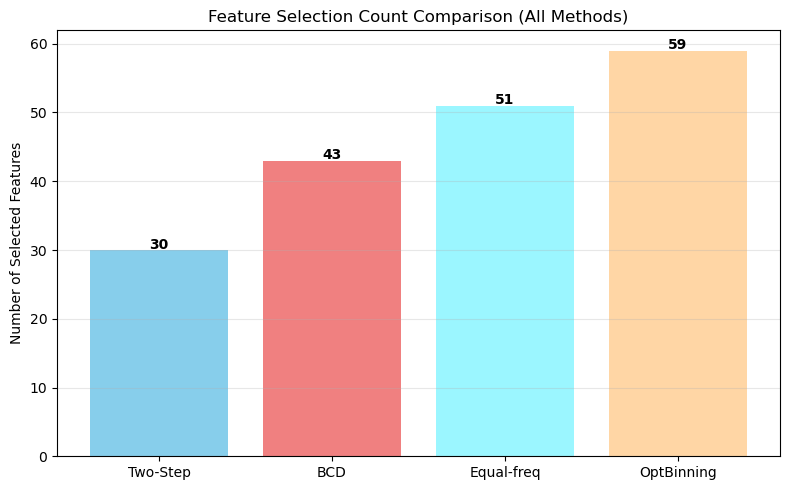

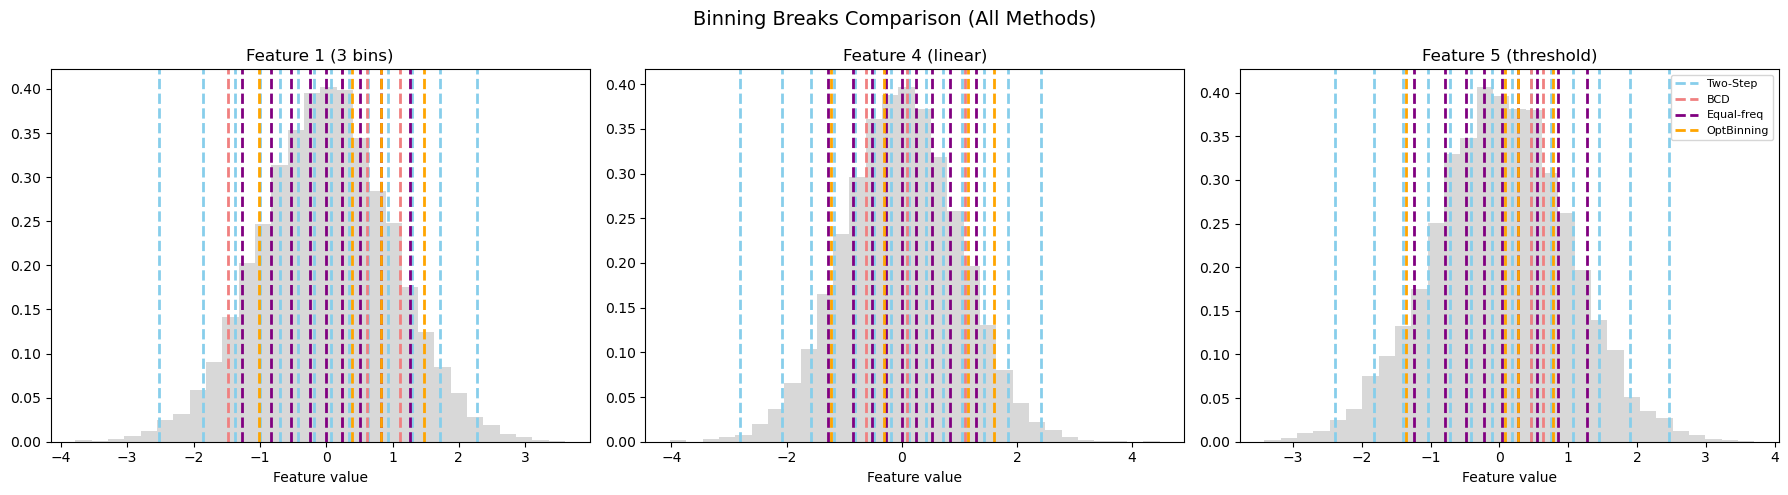

In [ ]:
# ===================== 追加：特征选择数量与分箱边界对比 =====================

# --- 1. 提取等频分箱和OptBinning选中的特征数 ---
eq_coef = eq_model.coef_.flatten()
n_eq_selected = np.sum(np.abs(eq_coef) > 1e-6)

opt_coef = opt_model.coef_.flatten()
n_opt_selected = np.sum(np.abs(opt_coef) > 1e-6)

# 汇总四种方法选中的特征数量
method_names = ['Two-Step', 'BCD', 'Equal-freq', 'OptBinning']
n_selected = [
    np.sum(two_step_model.feature_selected),
    len(bcd_selected_features),
    n_eq_selected,
    n_opt_selected
]

# 绘制柱状图
plt.figure(figsize=(8, 5))
plt.bar(method_names, n_selected, color=['skyblue', 'lightcoral', '#9bf6ff', '#ffd6a5'])
for i, v in enumerate(n_selected):
    plt.text(i, v + 0.2, str(v), ha='center', fontweight='bold')
plt.ylabel('Number of Selected Features')
plt.title('Feature Selection Count Comparison (All Methods)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- 2. 分箱边界可视化（示例特征：1, 4, 5） ---
sample_feats = [0, 3, 4]   # 索引：特征1、4、5
feat_names = ['Feature 1 (3 bins)', 'Feature 4 (linear)', 'Feature 5 (threshold)']

# 两步法分箱边界
two_step_breaks = []
for idx in sample_feats:
    edges = two_step_model.bin_edges[idx]
    if len(edges) > 2:
        two_step_breaks.append(edges[1:-1])   # 去掉首尾，只保留内部断点
    else:
        two_step_breaks.append([])

# BCD 分箱边界（从 binning_result 中提取）
bcd_breaks = []
for idx in sample_feats:
    feat_name = f"feature_{idx+1}"
    intervals = binning_result[feat_name].get('final_bin_intervals', [])
    if isinstance(intervals, np.ndarray) and len(intervals) > 1:
        bcd_breaks.append(intervals[1:-1])    # 假设是数组形式
    elif isinstance(intervals, list) and len(intervals) > 1:
        # 元组列表，取每个区间左端点（跳过第一个区间）
        breaks = [iv[0] for iv in intervals[1:]]
        bcd_breaks.append(breaks)
    else:
        bcd_breaks.append([])

# 等频分箱边界
eq_breaks = []
for idx in sample_feats:
    col = f"feat_{idx}"
    edges = eq_edges.get(col, None)
    if edges is not None and len(edges) > 2:
        eq_breaks.append(edges[1:-1])
    else:
        eq_breaks.append([])

# OptBinning 分箱边界（直接使用 .splits 属性）
opt_breaks = []
for idx in sample_feats:
    obj = opt_objects[idx]
    if obj is not None:
        breaks = obj.splits          # 返回内部断点列表
        opt_breaks.append(breaks)
    else:
        opt_breaks.append([])

# 绘制分箱对比图
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, idx in enumerate(sample_feats):
    ax = axes[i]
    feat_vals = X_train[:, idx]   # 使用训练集数据
    ax.hist(feat_vals, bins=30, alpha=0.3, color='gray', density=True)

    colors = {'Two-Step': 'skyblue', 'BCD': 'lightcoral',
              'Equal-freq': 'purple', 'OptBinning': 'orange'}
    breaks_data = [
        ('Two-Step', two_step_breaks[i]),
        ('BCD', bcd_breaks[i]),
        ('Equal-freq', eq_breaks[i]),
        ('OptBinning', opt_breaks[i])
    ]
    for name, breaks in breaks_data:
        col = colors[name]
        for b in breaks:
            ax.axvline(x=b, color=col, linestyle='--', linewidth=2,
                       label=name if b == breaks[0] else "")
    ax.set_title(feat_names[i])
    ax.set_xlabel('Feature value')
    if i == 2:
        ax.legend(loc='upper right', fontsize=8)
plt.suptitle('Binning Breaks Comparison (All Methods)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# 参数网格
bcd_param_grid = [
    {'lambda_f': 1e-7, 'lambda_b': 1e-7, 'n_pre_bins': 20},
    {'lambda_f': 3e-7, 'lambda_b': 3e-7, 'n_pre_bins': 20},
    {'lambda_f': 1e-6, 'lambda_b': 1e-6, 'n_pre_bins': 20},
    {'lambda_f': 3e-6, 'lambda_b': 3e-6, 'n_pre_bins': 20},
    {'lambda_f': 1e-7, 'lambda_b': 5e-7, 'n_pre_bins': 30},
]

In [ ]:
# ===================== 5. BCD 模型训练（改为多参数调试） =====================
print("\n" + "="*50)
print("BCD Hyperparameter Tuning")
print("="*50)

# 保存所有BCD结果的列表
bcd_results = []
# 在 BCD 参数网格定义之后、循环开始之前，加入这两行
opt_coef = opt_model.coef_.flatten()
n_opt = np.sum(np.abs(opt_coef) > 1e-6)
for idx, params in enumerate(bcd_param_grid):
    print(f"\n--- BCD Trial {idx+1}/{len(bcd_param_grid)}: {params} ---")
    bcd_start_time = time.time()
    
    bcd_model = BCDOptimalBinning(
        lambda_f=params['lambda_f'],
        lambda_b=params['lambda_b'],
        max_iter=7500, tol=1e-6, verbose=False,   # 调参时关闭verbose，避免刷屏
        metric='auc'
    )
    bcd_model.fit(X_train, y_train, X_val, y_val, n_pre_bins=params['n_pre_bins'])
    
    bcd_end_time = time.time()
    bcd_time = bcd_end_time - bcd_start_time
    
    # 预测
    y_val_proba_bcd = bcd_model.predict_proba(X_val)
    y_train_proba_bcd = bcd_model.predict_proba(X_train)
    y_val_pred_bcd = (y_val_proba_bcd >= 0.5).astype(int)
    y_train_pred_bcd = (y_train_proba_bcd >= 0.5).astype(int)
    
    # 评估
    train_acc_bcd = accuracy_score(y_train, y_train_pred_bcd)
    val_acc_bcd = accuracy_score(y_val, y_val_pred_bcd)
    train_auc_bcd = roc_auc_score(y_train, y_train_proba_bcd)
    val_auc_bcd = roc_auc_score(y_val, y_val_proba_bcd)
    
    # 特征选择
    binning_result_bcd = bcd_model.get_optimal_binning_structure()
    bcd_selected = []
    for j in range(1, n_features + 1):
        if binning_result_bcd[f"feature_{j}"]["is_selected"]:
            bcd_selected.append(j)
    n_bcd_selected = len(bcd_selected)
    
    # 打印与 OptBinning 的即时对比
    print(f"  BCD Val AUC: {val_auc_bcd:.4f}  |  OptBinning Val AUC: {val_auc_opt:.4f}")
    print(f"  BCD Time: {bcd_time:.2f}s        |  OptBinning Time: {opt_time:.2f}s")
    print(f"  BCD Selected Features: {n_bcd_selected} (OptBinning feats: {n_opt})")
    
    # 存储结果
    bcd_results.append({
        'params': params,
        'val_auc': val_auc_bcd,
        'val_acc': val_acc_bcd,
        'train_auc': train_auc_bcd,
        'train_acc': train_acc_bcd,
        'time': bcd_time,
        'selected_features': bcd_selected,
        'n_selected': n_bcd_selected
    })

# 从调参结果中选出最佳组合（按 val_auc 最大）
best_bcd = max(bcd_results, key=lambda x: x['val_auc'])
print("\nBest BCD params:", best_bcd['params'], "Val AUC =", best_bcd['val_auc'])

# 重新用最佳参数训练一次（为了后续绘图，需要 bcd_model, bcd_loss_history, binning_result 等）
bcd_model = BCDOptimalBinning(
    lambda_f=best_bcd['params']['lambda_f'],
    lambda_b=best_bcd['params']['lambda_b'],
    max_iter=750, tol=1e-6, verbose=True,
    metric='auc'
)
bcd_start_time = time.time()
bcd_model.fit(X_train, y_train, X_val, y_val, n_pre_bins=best_bcd['params']['n_pre_bins'])
bcd_training_time = time.time() - bcd_start_time

# 覆盖之前的评估值
y_val_proba_bcd = bcd_model.predict_proba(X_val)
y_train_proba_bcd = bcd_model.predict_proba(X_train)
y_val_pred_bcd = (y_val_proba_bcd >= 0.5).astype(int)
y_train_pred_bcd = (y_train_proba_bcd >= 0.5).astype(int)

val_auc_bcd = roc_auc_score(y_val, y_val_proba_bcd)
val_acc_bcd = accuracy_score(y_val, y_val_pred_bcd)
train_auc_bcd = roc_auc_score(y_train, y_train_proba_bcd)
train_acc_bcd = accuracy_score(y_train, y_train_pred_bcd)

binning_result = bcd_model.get_optimal_binning_structure()
bcd_selected_features = [j for j in range(1, n_features+1) 
                         if binning_result[f"feature_{j}"]["is_selected"]]
bcd_loss_history = bcd_model.history['loss']


BCD Hyperparameter Tuning

--- BCD Trial 1/5: {'lambda_f': 1e-07, 'lambda_b': 1e-07, 'n_pre_bins': 20} ---
  BCD Val AUC: 0.9388  |  OptBinning Val AUC: 0.9728
  BCD Time: 2408.63s        |  OptBinning Time: 16.19s
  BCD Selected Features: 60 (OptBinning feats: 59)

--- BCD Trial 2/5: {'lambda_f': 3e-07, 'lambda_b': 3e-07, 'n_pre_bins': 20} ---
  BCD Val AUC: 0.9388  |  OptBinning Val AUC: 0.9728
  BCD Time: 2218.40s        |  OptBinning Time: 16.19s
  BCD Selected Features: 60 (OptBinning feats: 59)

--- BCD Trial 3/5: {'lambda_f': 1e-06, 'lambda_b': 1e-06, 'n_pre_bins': 20} ---
  BCD Val AUC: 0.9388  |  OptBinning Val AUC: 0.9728
  BCD Time: 2398.25s        |  OptBinning Time: 16.19s
  BCD Selected Features: 60 (OptBinning feats: 59)

--- BCD Trial 4/5: {'lambda_f': 3e-06, 'lambda_b': 3e-06, 'n_pre_bins': 20} ---
  BCD Val AUC: 0.9198  |  OptBinning Val AUC: 0.9728
  BCD Time: 878.91s        |  OptBinning Time: 16.19s
  BCD Selected Features: 50 (OptBinning feats: 59)

--- BCD Trial

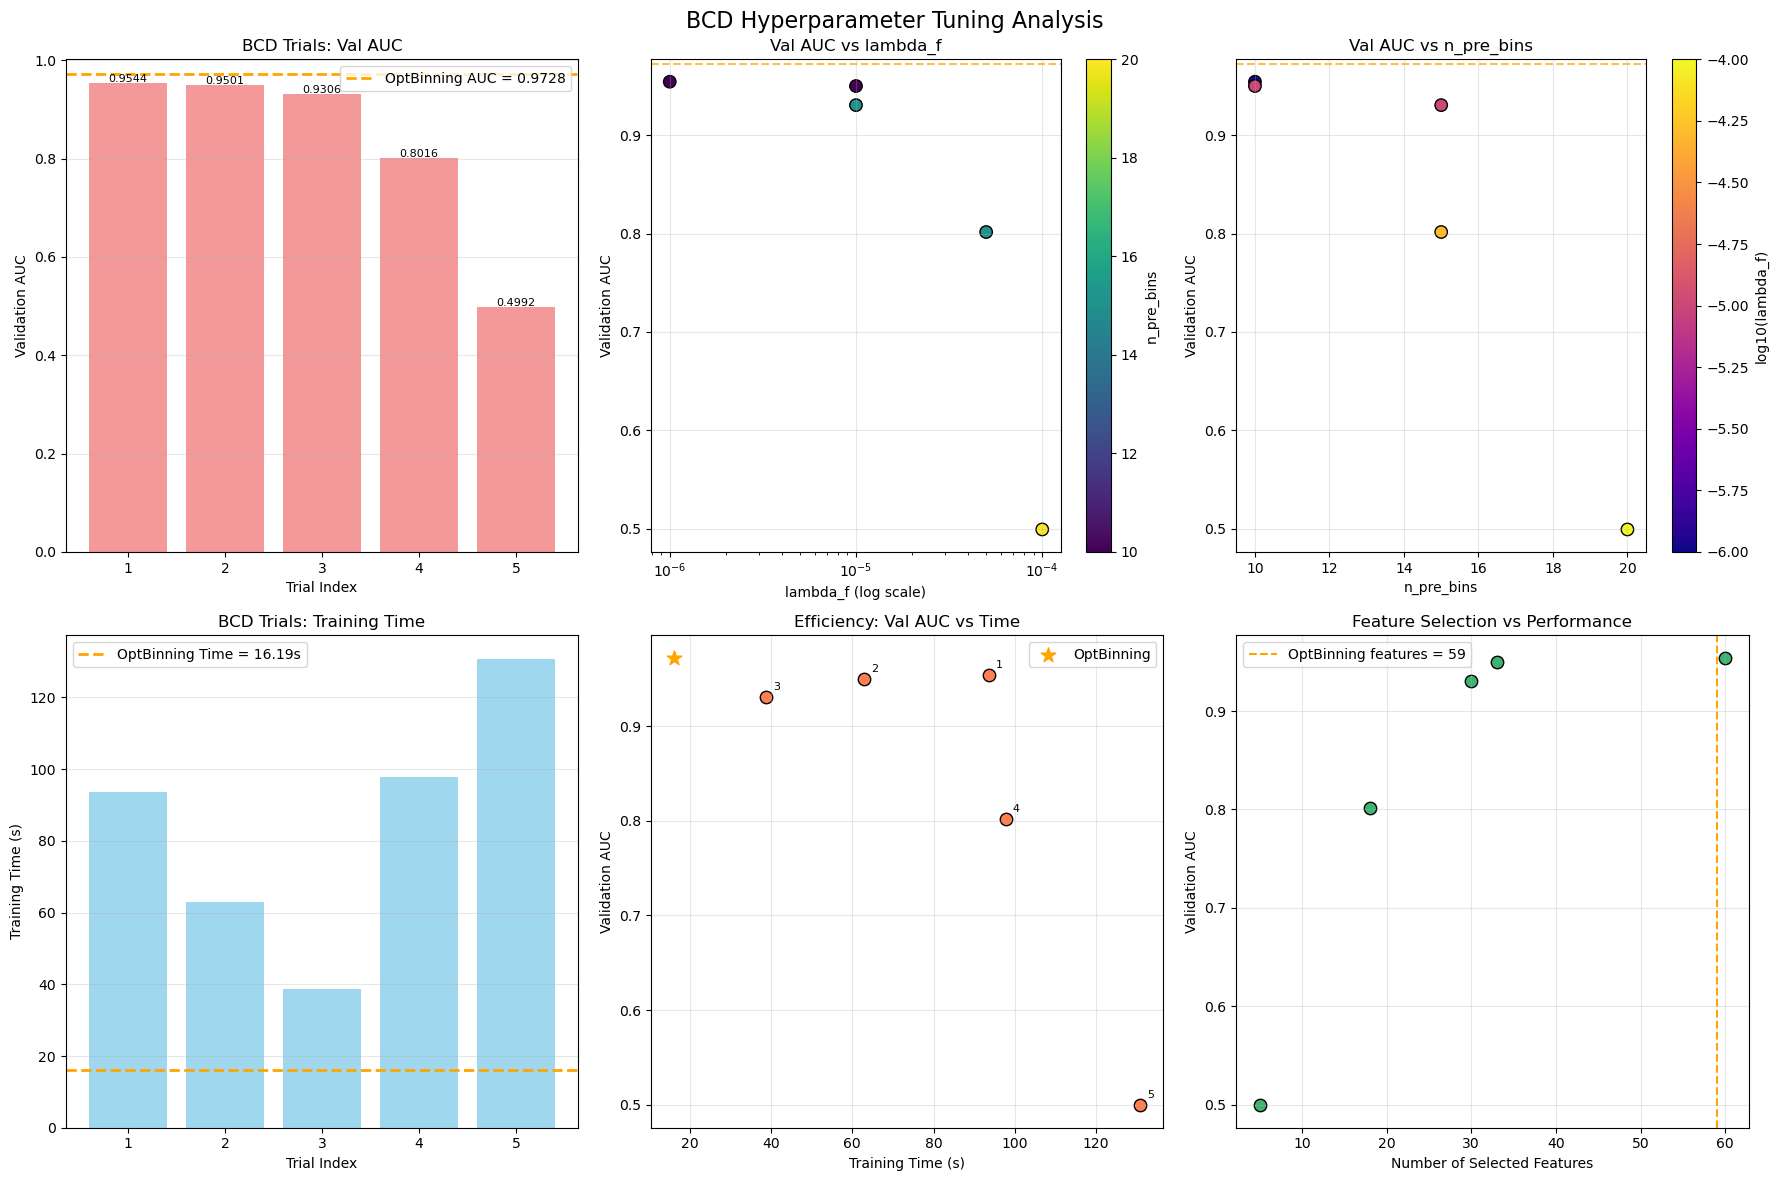


--- Best BCD vs OptBinning Final Summary ---
Best BCD Params: {'lambda_f': 1e-06, 'lambda_b': 1e-06, 'n_pre_bins': 10}
Best BCD Val AUC: 0.9544  |  OptBinning Val AUC: 0.9728
Best BCD Time: 93.56s       |  OptBinning Time: 16.19s
Best BCD Features: 60   |  OptBinning Features: 59


In [ ]:
# ===================== 新增：BCD 调参结果可视化 =====================
# 从 bcd_results 提取数据
trial_indices = np.arange(1, len(bcd_results) + 1)
trial_val_auc = [r['val_auc'] for r in bcd_results]
trial_train_auc = [r['train_auc'] for r in bcd_results]
trial_times = [r['time'] for r in bcd_results]
trial_n_feats = [r['n_selected'] for r in bcd_results]
lambda_f_vals = [r['params']['lambda_f'] for r in bcd_results]
lambda_b_vals = [r['params']['lambda_b'] for r in bcd_results]
pre_bins_vals = [r['params']['n_pre_bins'] for r in bcd_results]

# 创建画布
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('BCD Hyperparameter Tuning Analysis', fontsize=16)

# ---- 子图1：各 Trial 的 Val AUC 对比（柱状图 + OptBinning 参考线） ----
ax = axes[0, 0]
bars = ax.bar(trial_indices, trial_val_auc, color='lightcoral', alpha=0.8)
ax.axhline(y=val_auc_opt, color='orange', linestyle='--', linewidth=2, label=f'OptBinning AUC = {val_auc_opt:.4f}')
ax.set_xlabel('Trial Index')
ax.set_ylabel('Validation AUC')
ax.set_title('BCD Trials: Val AUC')
ax.legend()
ax.grid(axis='y', alpha=0.3)
# 在柱子上方标出数值
for i, v in enumerate(trial_val_auc):
    ax.text(i+1, v+0.002, f'{v:.4f}', ha='center', fontsize=8)

# ---- 子图2：Val AUC vs lambda_f (散点图，颜色表示 n_pre_bins) ----
ax = axes[0, 1]
sc = ax.scatter(lambda_f_vals, trial_val_auc, c=pre_bins_vals, cmap='viridis', s=80, edgecolors='k')
ax.set_xscale('log')
ax.set_xlabel('lambda_f (log scale)')
ax.set_ylabel('Validation AUC')
ax.set_title('Val AUC vs lambda_f')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('n_pre_bins')
ax.axhline(y=val_auc_opt, color='orange', linestyle='--', alpha=0.7)
ax.grid(True, alpha=0.3)

# ---- 子图3：Val AUC vs n_pre_bins (散点图，颜色表示 lambda_f) ----
ax = axes[0, 2]
sc = ax.scatter(pre_bins_vals, trial_val_auc, c=np.log10(lambda_f_vals), cmap='plasma', s=80, edgecolors='k')
ax.set_xlabel('n_pre_bins')
ax.set_ylabel('Validation AUC')
ax.set_title('Val AUC vs n_pre_bins')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('log10(lambda_f)')
ax.axhline(y=val_auc_opt, color='orange', linestyle='--', alpha=0.7)
ax.grid(True, alpha=0.3)

# ---- 子图4：训练时间对比 ----
ax = axes[1, 0]
ax.bar(trial_indices, trial_times, color='skyblue', alpha=0.8)
ax.axhline(y=opt_time, color='orange', linestyle='--', linewidth=2, label=f'OptBinning Time = {opt_time:.2f}s')
ax.set_xlabel('Trial Index')
ax.set_ylabel('Training Time (s)')
ax.set_title('BCD Trials: Training Time')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# ---- 子图5：Val AUC vs Training Time (效率散点图) ----
ax = axes[1, 1]
ax.scatter(trial_times, trial_val_auc, c='coral', s=80, edgecolors='k')
ax.scatter(opt_time, val_auc_opt, c='orange', s=120, marker='*', label='OptBinning')
ax.set_xlabel('Training Time (s)')
ax.set_ylabel('Validation AUC')
ax.set_title('Efficiency: Val AUC vs Time')
ax.legend()
ax.grid(True, alpha=0.3)
# 标注 trial 编号
for i, (tx, ty) in enumerate(zip(trial_times, trial_val_auc)):
    ax.annotate(str(i+1), (tx, ty), textcoords="offset points", xytext=(5,5), fontsize=8)

# ---- 子图6：选中的特征数量与 Val AUC 的关系 ----
ax = axes[1, 2]
ax.scatter(trial_n_feats, trial_val_auc, c='mediumseagreen', s=80, edgecolors='k')
ax.axvline(x=n_opt, color='orange', linestyle='--', label=f'OptBinning features = {n_opt}')
ax.set_xlabel('Number of Selected Features')
ax.set_ylabel('Validation AUC')
ax.set_title('Feature Selection vs Performance')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印最佳 BCD 与 OptBinning 的详细对比总结
print("\n--- Best BCD vs OptBinning Final Summary ---")
print(f"Best BCD Params: {best_bcd['params']}")
print(f"Best BCD Val AUC: {best_bcd['val_auc']:.4f}  |  OptBinning Val AUC: {val_auc_opt:.4f}")
print(f"Best BCD Time: {best_bcd['time']:.2f}s       |  OptBinning Time: {opt_time:.2f}s")
print(f"Best BCD Features: {best_bcd['n_selected']}   |  OptBinning Features: {n_opt}")

信贷数据集训练
